In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
import utils
from sklearn.preprocessing import StandardScaler
import matplotlib.patches as mpatches
from scipy.stats import mannwhitneyu, wilcoxon
import mne
import numpy as np
import matplotlib.pyplot as plt

subjects = ['485', '486', '487', '488', '497', '498', '499', '505', '5107', '515', '520', '545']
controls = ['394', '396', '398', '402', '404', '405', '406', '415', '416', '417'] # noisy- '423', '426', '429'
stim_side = {'485': 'R', '486': 'L', '487': 'R', '488': 'L', '489': 'R', '496': 'R', '497': 'R', '498': 'L', '499': 'L', '505': 'L', '5101': 'R', '5107': 'R', '515': 'R', '520': 'R', '538': 'R', '541': 'L', '544':'R', '545': 'R'}
frontal_chans = [f"{side}{string}{number}" for string in ['OF', 'AC', 'AF', 'FA', 'IF-dAC', 'OPR'] for number in range(1, 9) for side in ['R', 'L']]
temporal_chans = [f"{string}{number}" for string in ['RA', 'LA', 'RAH', 'LAH', 'RMH', 'LMH', 'REC', 'LEC', 'RPHG', 'LPHG'] for number in range(1, 9)]
temporal_soz = ['485', '487', '488', '489', '496', '497', '498', '515', '520', '538', '541', '544']
frontal_soz = ['486', '499', '505', '5101', '5107', '545']
soz_side = {'485': 'R', '486': 'R', '487': 'L', '488': 'R', '489': 'L', '496': 'R', '497': 'B', '498': 'B', '499': 'R', '505': 'L', '5101': 'L', '5107': 'L', '515': 'R', '520': 'B', '538': 'L', '541': 'B', '544':'L', '545': 'L'}
temporal_stim = ['489', '496', '538']

1	485
2	486
3	487
4	488
5	497
6	498
7	499
8	505
9	510
10	515
11	520
12	545

## Figure 1

Processing p485 for electrode RPSMA4...
Found 68 electrodes for p485. Looking for RPSMA4...
Processing p486 for electrode LOF4...
Found 89 electrodes for p486. Looking for LOF4...
Processing p487 for electrode ROF5...
Found 71 electrodes for p487. Looking for ROF5...
Processing p488 for electrode LOF4...
Found 87 electrodes for p488. Looking for LOF4...
Processing p497 for electrode ROF7...
Found 77 electrodes for p497. Looking for ROF7...
Processing p498 for electrode LOF6...
Found 76 electrodes for p498. Looking for LOF6...
Processing p499 for electrode LOF6...
Found 66 electrodes for p499. Looking for LOF6...
Processing p505 for electrode LOF-AC7...
Found 75 electrodes for p505. Looking for LOF-AC7...
Processing p510 for electrode ROF6...
Found 96 electrodes for p510. Looking for ROF6...
Processing p515 for electrode ROF2...
Found 65 electrodes for p515. Looking for ROF2...
Processing p520 for electrode ROF5...
Found 64 electrodes for p520. Looking for ROF5...
Processing p545 for el

AttributeError: 'GlassBrainAxes' object has no attribute 'cmap'

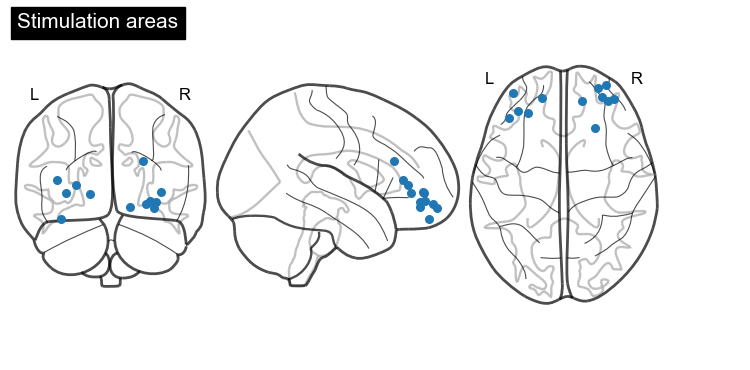

In [2]:
import numpy as np
from nilearn import plotting

# --- שלב 1: הגדרת הפונקציות לקריאת וחישוב קואורדינטות ---

def read_coordinates_files(electrodes_name_file_path: str, electrodes_location_file_path: str):
    name_data = pd.read_csv(
        filepath_or_buffer=electrodes_name_file_path,
        delimiter=' ',
        usecols=[0],
        skiprows=2,
        header=None,
        dtype={0: str}
    )
    location_data = pd.read_csv(
        filepath_or_buffer=electrodes_location_file_path,
        delimiter=' ',
        skiprows=2,
        header=None,
        dtype={0: float, 1: float, 2: float}
    )

    name_to_coordinates = {}
    for names_row, location_row in zip(name_data.iterrows(), location_data.iterrows()):
        electrode_name = f'{names_row[1][0]}'
        name_to_coordinates[electrode_name] = (
            location_row[1][0],
            location_row[1][1],
            location_row[1][2]
        )
    return name_to_coordinates

def calculate_coordinates(avarage=True):
    # כאן הגדרתי גרסה פשוטה של הפונקציה שסורקת את התיקייה הכללית
    # הנתיב נלקח מהלוגיקה של הקוד הקודם שלך
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    
    _sum = {}
    count = {}
    
    # חיפוש קבצי שמות אלקטרודות
    files = [f for f in os.listdir(coordinates_dir) if f.endswith('.electrodeNames')]
    
    for file in files:
        loc_file_path = os.path.join(coordinates_dir, file)
        pial_file_path = os.path.join(coordinates_dir, file.replace('.electrodeNames', '.Pial'))
        
        if not os.path.exists(loc_file_path) or not os.path.exists(pial_file_path):
            continue
            
        electrode_name_to_location = read_coordinates_files(loc_file_path, pial_file_path)
        for electrode_name, location in electrode_name_to_location.items():
            if electrode_name not in _sum:
                _sum[electrode_name] = [0, 0, 0]
                count[electrode_name] = 0
            count[electrode_name] += 1
            _sum[electrode_name][0] += location[0]
            _sum[electrode_name][1] += location[1]
            _sum[electrode_name][2] += location[2]

    for electrode in _sum:
        _sum[electrode][0] /= count[electrode]
        _sum[electrode][1] /= count[electrode]
        _sum[electrode][2] /= count[electrode]

    return _sum

# --- שלב 2: הרצת התהליך על הנבדקים שלך ---
all_coords = calculate_coordinates(avarage=True)

# 1. הגדרת המילון - התאימי את שמות האלקטרודות לפי מה שמופיע אצלך בנתונים
subject_to_electrode = {
    'p485': 'RPSMA4',
    'p486': 'LOF4',
    'p487': 'ROF5',
    'p488': 'LOF4',
    # 'p489': 'RPHG5',
    # 'p496': 'RTOP6',
    'p497': 'ROF7',
    'p498': 'LOF6',
    'p499': 'LOF6',
    'p505': 'LOF-AC7',
    'p510': 'ROF6',
    'p515': 'ROF2',
    'p520': 'ROF5',
    # 'p538': 'RHSG4',
    'p545': 'ROF4'
}

# 2. פונקציה לשליפת המיקומים הספציפיים בלבד
def get_selected_electrodes_data(subject_map):
    coordinates_dir = r'C:\repos\NirsLabProject\NirsLabProject\data\cordinates'
    selected_data = []
    
    for subj, target_electrode in subject_map.items():
        loc_file = os.path.join(coordinates_dir, f'{subj[1:]}.electrodeNames')
        print(f"Processing {subj} for electrode {target_electrode}...")
        pial_file = os.path.join(coordinates_dir, f'{subj[1:]}.PIAL')
        
        if os.path.exists(loc_file):
            # טעינת כל האלקטרודות של הנבדק
            subj_coords = read_coordinates_files(loc_file, pial_file)
            print(f"Found {len(subj_coords)} electrodes for {subj}. Looking for {target_electrode}...")
            
            # בדיקה אם האלקטרודה המבוקשת קיימת עבורו
            if target_electrode in subj_coords:
                x, y, z = subj_coords[target_electrode]
                selected_data.append({
                    'subject': subj,
                    'electrode': target_electrode,
                    'x': x,
                    'y': y,
                    'z': z
                })
            else:
                print(f"Warning: Electrode {target_electrode} not found for subject {subj}")
    
    return pd.DataFrame(selected_data)

# 3. הרצה וויזואליזציה
df_selected = get_selected_electrodes_data(subject_to_electrode)

# חילוץ קואורדינטות
coords = df_selected[['x', 'y', 'z']].values

# ציור ב-Nilearn (תצוגה אורתוגונלית שמראה את המיקום המדויק בתוך המוח)
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color='tab:blue', 
    node_size=30,
    display_mode='ortho',
    title="Stimulation areas"
)


In [3]:
from matplotlib import colors
from nilearn import plotting

# 1. הגדרת צבע כחול עם שקיפות (Alpha = 0.5)
# אפשר לשנות את ה-0.5 לערך נמוך יותר לשקיפות גבוהה יותר
node_color_transparent = colors.to_rgba('tab:blue', alpha=0.8)

# 2. ציור ושמירה כקובץ PDF
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color=[node_color_transparent] * len(coords), # רשימת צבעים לכל נקודה
    node_size=30,
    display_mode='ortho',
    colorbar=False,           
    output_file='stimulation_areas_frontal.pdf' # שמירה כקובץ PDF וקטורי
)

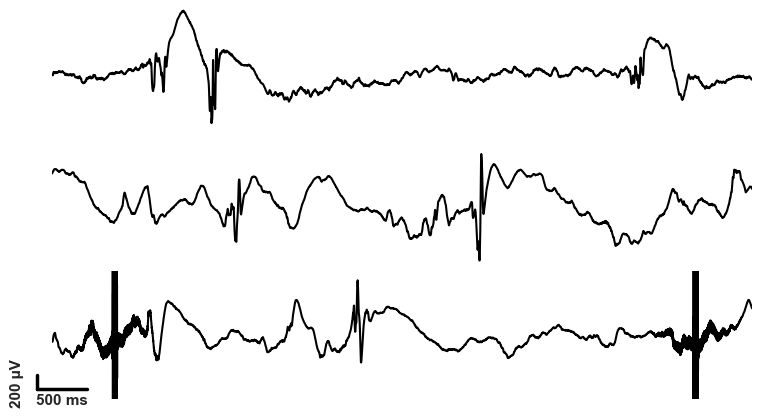

In [4]:
# --------------------
# Parameters
# --------------------
edf_path = r"D:\Maya\p505\P505_fixed.edf"
channel_name = "LEC1"
duration = 7  
amp_bar_val = 200 # µV
time_bar_sec = 0.5 

start_times = [
    1 * 3600 + 12 * 60 + 29.5,                                     
    1 * 3600 + 34 * 60 + 9.5,                 
    3 * 3600 + 11 * 60 + 9.5                  
]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, verbose=False) # בלי preload
raw.pick([channel_name])

segments = []
for t_start in start_times:
    crop = raw.copy().crop(tmin=t_start, tmax=t_start + duration)
    data = crop.get_data()[0] * 1e6
    data = data - np.mean(data)
    segments.append(data)

# חישוב גבולות
y_min_data = min([np.min(s) for s in segments])
y_max_data = max([np.max(s) for s in segments])

y_range_total = 1900 
y_min_global = -y_range_total / 2
y_max_global = y_range_total / 2

# --------------------
# Plot
# --------------------
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 5), sharey=True)

for i, data in enumerate(segments):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    ax.plot(times, data, color="black", linewidth=1.5)
    
    ax.set_ylim(y_min_global, y_max_global)
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar "L" Shape
# --------------------
ax_bottom = axes[2]

corner_x = -0.15 
corner_y = -800 

# 1. הבר האנכי
ax_bottom.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val],
               color="black", linewidth=2.5, clip_on=False)

# 2. הבר האופקי
ax_bottom.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y],
               color="black", linewidth=2.5, clip_on=False)

# 3. כיתובים מעודכנים
# כיתוב למתח - מסובב ב-90 מעלות
ax_bottom.text(corner_x - 0.2, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
               va="center", ha="center", fontsize=11, fontweight='bold', rotation=90)

# כיתוב לזמן - שונה ל-500 ms
ax_bottom.text(corner_x + (time_bar_sec / 2), corner_y - 60, "500 ms", 
               va="top", ha="center", fontsize=11, fontweight='bold')

plt.subplots_adjust(left=0.2, hspace=0.02, bottom=0.1) 
plt.show()

## Figure 2

In [192]:
import joblib
data_stim = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_stim_frontal.pkl")
data_control = joblib.load(r"C:\repos\spikes_stim\paper\for_avg_props_raw_controls_10.pkl")
data_no_base = joblib.load(r"C:\repos\spikes_stim\paper\no_base_515_545.pkl")

In [14]:
def get_clean_matrix(raw_data_list, mode='baseline', max_points=30, threshold=1000):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

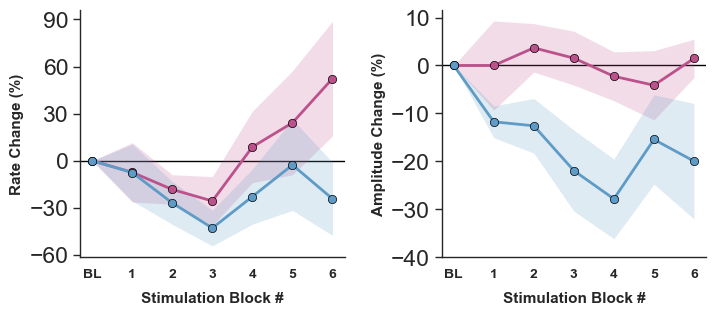

In [176]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. הכנת הנתונים (Rate & Amplitude) ---
# נתונים לגרף שמאל (Rate)
df_rate_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline', threshold=1000)
df_rate_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline', threshold=1000)

# נתונים לגרף ימין (Amplitude)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)
df_amp_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline', threshold=1000)

stim_idx = [1, 3, 5, 7, 9, 11]

def prepare_group_line(df, idx_list):
    mean_s = df.mean()
    sem_s = df.sem()
    y = np.array([0] + mean_s.iloc[idx_list].tolist())
    err = np.array([0] + sem_s.iloc[idx_list].tolist())
    return y, err

# הכנת הנתונים הסופיים
y_rate_stim, err_rate_stim = prepare_group_line(df_rate_stim, stim_idx)
y_rate_ctrl, err_rate_ctrl = prepare_group_line(df_rate_ctrl, stim_idx)

y_amp_stim, err_amp_stim = prepare_group_line(df_amp_stim, stim_idx)
y_amp_ctrl, err_amp_ctrl = prepare_group_line(df_amp_ctrl, stim_idx)

x_axis = np.arange(len(y_rate_stim))

# --- 2. פונקציית עזר לציור קו עם הצללה ---
def plot_shaded_line(ax, x, y, err, color, label, zorder):
    # צל
    ax.fill_between(x, y - err, y + err, color=color, alpha=0.2, linewidth=0, zorder=zorder-1)
    # קו ונקודות
    ax.plot(x, y, color=color, linewidth=2, marker='o', markersize=6, 
            markeredgecolor='black', markeredgewidth=0.5, zorder=zorder, label=label)

# --- 3. יצירת הגרף המאוחד (1 שורה, 2 עמודות) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

stim_blue = '#5e9bc7'
ctrl_pink = '#bb528c'

# גרף שמאל - Rate Change
plot_shaded_line(ax1, x_axis, y_rate_stim, err_rate_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax1, x_axis, y_rate_ctrl, err_rate_ctrl, ctrl_pink, 'Control', zorder=4)

# גרף ימין - Amplitude Change
plot_shaded_line(ax2, x_axis, y_amp_stim, err_amp_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax2, x_axis, y_amp_ctrl, err_amp_ctrl, ctrl_pink, 'Control', zorder=4)

# עיצוב משותף לשני הצירים
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    # החזרת הטיקים: left=True מבטיח שהקווים הקטנים יופיעו על ציר ה-Y
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1, left=True)
    
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)

# הגדרות ספציפיות
ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
ax1.set_yticks(np.arange(-60, 91, 30))

ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
# הגדרת Ticks לאמפליטודה במידה ותרצי (למשל קפיצות של 20)
ax2.set_yticks(np.arange(-40, 20, 10)) 

plt.tight_layout()
plt.savefig('combined_rate_amp_cumulative_shade.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

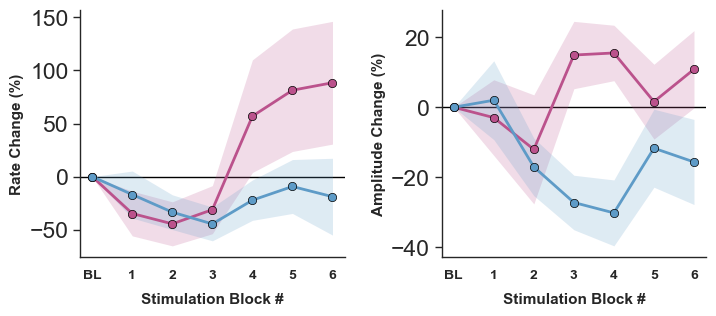

In [178]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. הכנת הנתונים (Rate & Amplitude) ---
# נתונים לגרף שמאל (Rate)
df_rate_stim = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_rate_ctrl = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)

# נתונים לגרף ימין (Amplitude)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['ipsi'], mode='baseline', threshold=1000)
df_amp_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['ipsi'], mode='baseline', threshold=1000)

stim_idx = [1, 3, 5, 7, 9, 11]

def prepare_group_line(df, idx_list):
    mean_s = df.mean()
    sem_s = df.sem()
    y = np.array([0] + mean_s.iloc[idx_list].tolist())
    err = np.array([0] + sem_s.iloc[idx_list].tolist())
    return y, err

# הכנת הנתונים הסופיים
y_rate_stim, err_rate_stim = prepare_group_line(df_rate_stim, stim_idx)
y_rate_ctrl, err_rate_ctrl = prepare_group_line(df_rate_ctrl, stim_idx)

y_amp_stim, err_amp_stim = prepare_group_line(df_amp_stim, stim_idx)
y_amp_ctrl, err_amp_ctrl = prepare_group_line(df_amp_ctrl, stim_idx)

x_axis = np.arange(len(y_rate_stim))

# --- 2. פונקציית עזר לציור קו עם הצללה ---
def plot_shaded_line(ax, x, y, err, color, label, zorder):
    # צל
    ax.fill_between(x, y - err, y + err, color=color, alpha=0.2, linewidth=0, zorder=zorder-1)
    # קו ונקודות
    ax.plot(x, y, color=color, linewidth=2, marker='o', markersize=6, 
            markeredgecolor='black', markeredgewidth=0.5, zorder=zorder, label=label)

# --- 3. יצירת הגרף המאוחד (1 שורה, 2 עמודות) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

stim_blue = '#5e9bc7'
ctrl_pink = '#bb528c'

# גרף שמאל - Rate Change
plot_shaded_line(ax1, x_axis, y_rate_stim, err_rate_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax1, x_axis, y_rate_ctrl, err_rate_ctrl, ctrl_pink, 'Control', zorder=4)

# גרף ימין - Amplitude Change
plot_shaded_line(ax2, x_axis, y_amp_stim, err_amp_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax2, x_axis, y_amp_ctrl, err_amp_ctrl, ctrl_pink, 'Control', zorder=4)

# עיצוב משותף לשני הצירים
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    # החזרת הטיקים: left=True מבטיח שהקווים הקטנים יופיעו על ציר ה-Y
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1, left=True)
    
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)

# הגדרות ספציפיות
ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
# ax1.set_yticks(np.arange(-60, 91, 30))

ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
# הגדרת Ticks לאמפליטודה במידה ותרצי (למשל קפיצות של 20)
# ax2.set_yticks(np.arange(-40, 20, 10)) 

plt.tight_layout()
plt.show()

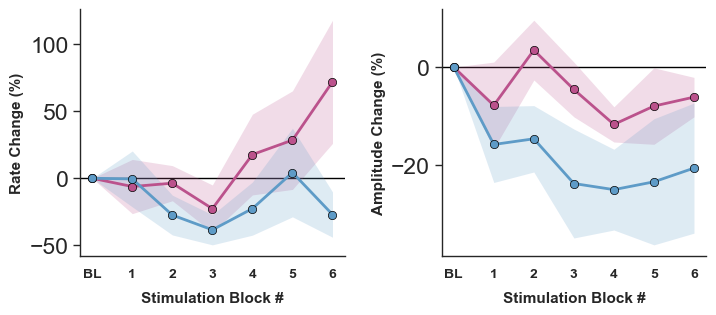

In [179]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. הכנת הנתונים (Rate & Amplitude) ---
# נתונים לגרף שמאל (Rate)
df_rate_stim = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_rate_ctrl = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# נתונים לגרף ימין (Amplitude)
df_amp_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['contra'], mode='baseline', threshold=1000)
df_amp_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['contra'], mode='baseline', threshold=1000)

stim_idx = [1, 3, 5, 7, 9, 11]

def prepare_group_line(df, idx_list):
    mean_s = df.mean()
    sem_s = df.sem()
    y = np.array([0] + mean_s.iloc[idx_list].tolist())
    err = np.array([0] + sem_s.iloc[idx_list].tolist())
    return y, err

# הכנת הנתונים הסופיים
y_rate_stim, err_rate_stim = prepare_group_line(df_rate_stim, stim_idx)
y_rate_ctrl, err_rate_ctrl = prepare_group_line(df_rate_ctrl, stim_idx)

y_amp_stim, err_amp_stim = prepare_group_line(df_amp_stim, stim_idx)
y_amp_ctrl, err_amp_ctrl = prepare_group_line(df_amp_ctrl, stim_idx)

x_axis = np.arange(len(y_rate_stim))

# --- 2. פונקציית עזר לציור קו עם הצללה ---
def plot_shaded_line(ax, x, y, err, color, label, zorder):
    # צל
    ax.fill_between(x, y - err, y + err, color=color, alpha=0.2, linewidth=0, zorder=zorder-1)
    # קו ונקודות
    ax.plot(x, y, color=color, linewidth=2, marker='o', markersize=6, 
            markeredgecolor='black', markeredgewidth=0.5, zorder=zorder, label=label)

# --- 3. יצירת הגרף המאוחד (1 שורה, 2 עמודות) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.5))

stim_blue = '#5e9bc7'
ctrl_pink = '#bb528c'

# גרף שמאל - Rate Change
plot_shaded_line(ax1, x_axis, y_rate_stim, err_rate_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax1, x_axis, y_rate_ctrl, err_rate_ctrl, ctrl_pink, 'Control', zorder=4)

# גרף ימין - Amplitude Change
plot_shaded_line(ax2, x_axis, y_amp_stim, err_amp_stim, stim_blue, 'Stim', zorder=5)
plot_shaded_line(ax2, x_axis, y_amp_ctrl, err_amp_ctrl, ctrl_pink, 'Control', zorder=4)

# עיצוב משותף לשני הצירים
for ax in [ax1, ax2]:
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1)
    ax.spines['bottom'].set_linewidth(1)
    
    # החזרת הטיקים: left=True מבטיח שהקווים הקטנים יופיעו על ציר ה-Y
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1, left=True)
    
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)

# הגדרות ספציפיות
ax1.set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')
# ax1.set_yticks(np.arange(-60, 91, 30))

ax2.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
# הגדרת Ticks לאמפליטודה במידה ותרצי (למשל קפיצות של 20)
# ax2.set_yticks(np.arange(-40, 20, 10)) 

plt.tight_layout()
plt.show()

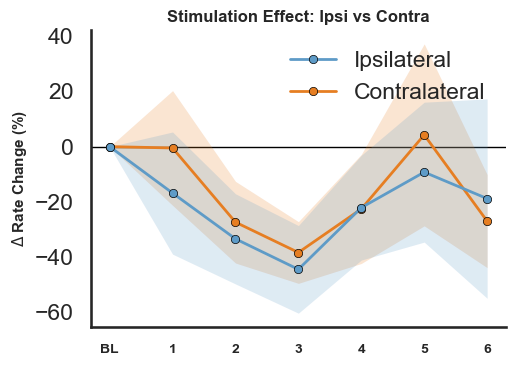

In [181]:
# 1. הכנת המשתנים (חילוץ הנתונים מהמטריצות)
# איפסי
y_ipsi_rate, err_ipsi_rate = prepare_group_line(
    get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000), stim_idx)
# קונטרה
y_contra_rate, err_contra_rate = prepare_group_line(
    get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000), stim_idx)

# 2. יצירת הגרף
fig, ax = plt.subplots(figsize=(5.5, 4))

# שימוש בפונקציית plot_shaded_line שהגדרנו קודם
plot_shaded_line(ax, x_axis, y_ipsi_rate, err_ipsi_rate, '#5e9bc7', 'Ipsilateral', zorder=5)
plot_shaded_line(ax, x_axis, y_contra_rate, err_contra_rate, '#e67e22', 'Contralateral', zorder=4)

# עיצוב הציר
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, zorder=1)
ax.set_ylabel(r'$\Delta$ Rate Change (%)', fontsize=11, fontweight='bold')
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL'] + [str(i) for i in range(1, len(x_axis))], fontsize=10, fontweight='bold')
ax.set_title('Stimulation Effect: Ipsi vs Contra', fontsize=12, fontweight='bold')
ax.legend(frameon=False)

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

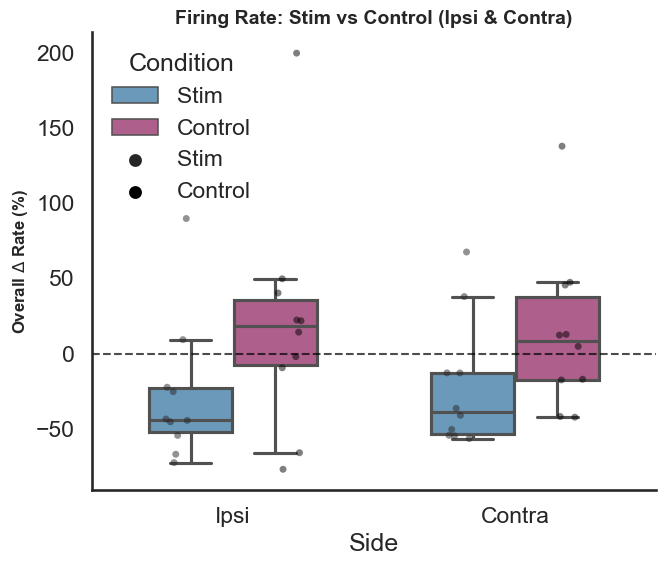

In [188]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. הגדרת האינדקסים של בלוקי הגירוי
stim_idx = [1, 3, 5, 7, 9, 11]

# 2. חילוץ ה-DataFrames (שימוש במבנה המדויק של המילונים שלך)
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# 3. חישוב ממוצע לכל נבדק (Subject Mean) לאורך הבלוקים
v_si = df_si.iloc[:, stim_idx].mean(axis=1).dropna().values
v_sc = df_sc.iloc[:, stim_idx].mean(axis=1).dropna().values
v_ci = df_ci.iloc[:, stim_idx].mean(axis=1).dropna().values
v_cc = df_cc.iloc[:, stim_idx].mean(axis=1).dropna().values

# 4. ארגון הנתונים ב-DataFrame אחד לציור
plot_list = []
for v in v_si: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Stim'})
for v in v_sc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Stim'})
for v in v_ci: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Control'})
for v in v_cc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Control'})

df_plot = pd.DataFrame(plot_list)

# 5. יצירת הגרף (4 בוקסים: 2 לכל צד, מחולקים לפי צבע)
fig, ax = plt.subplots(figsize=(7, 6))

colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

# בוקספלוט
sns.boxplot(x='Side', y='Value', hue='Condition', data=df_plot, 
            palette=colors, ax=ax, width=0.6, fliersize=0)

# הוספת הנבדקים כנקודות (dodge=True מוודא שהן יושבות על הבוקס הנכון)
sns.stripplot(x='Side', y='Value', hue='Condition', data=df_plot, 
              color='black', alpha=0.5, size=5, ax=ax, dodge=True)

# עיצוב
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Firing Rate: Stim vs Control (Ipsi & Contra)', fontsize=14, fontweight='bold')

for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False)

plt.tight_layout()
plt.show()

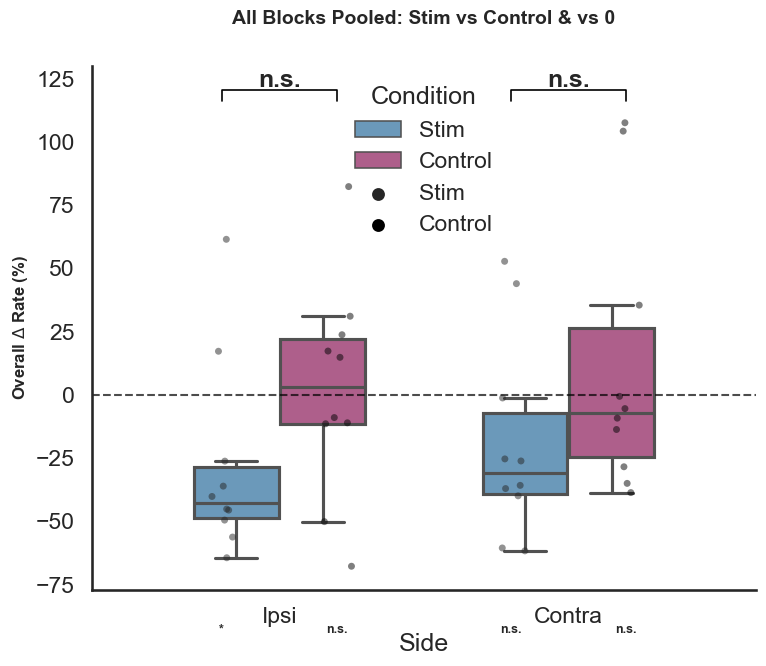

In [199]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. חילוץ ה-DataFrames (כל הבלוקים כלולים)
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# 2. חישוב ממוצע לכל נבדק לאורך כל הבלוקים הזמינים
v_si = df_si.mean(axis=1).dropna().values
v_sc = df_sc.mean(axis=1).dropna().values
v_ci = df_ci.mean(axis=1).dropna().values
v_cc = df_cc.mean(axis=1).dropna().values

# 3. ארגון הנתונים לציור
plot_list = []
for v in v_si: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Stim'})
for v in v_sc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Stim'})
for v in v_ci: plot_list.append({'Value': v, 'Side': 'Ipsi', 'Condition': 'Control'})
for v in v_cc: plot_list.append({'Value': v, 'Side': 'Contra', 'Condition': 'Control'})
df_plot = pd.DataFrame(plot_list)

# 4. פונקציית עזר לכוכביות
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

# 5. יצירת הגרף
fig, ax = plt.subplots(figsize=(8, 7))
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

sns.boxplot(x='Side', y='Value', hue='Condition', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
sns.stripplot(x='Side', y='Value', hue='Condition', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# --- הוספת סטטיסטיקה ---
y_max = df_plot['Value'].max()
y_min = df_plot['Value'].min()
h = abs(y_max - y_min) * 0.05

# א. מבחן בין Stim ל-Control (למעלה)
for i, side in enumerate(['Ipsi', 'Contra']):
    s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Stim')]['Value']
    c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Condition'] == 'Control')]['Value']
    
    _, p_comp = stats.ttest_ind(s_vals, c_vals)
    
    # ציור קו ההשוואה
    ax.plot([i-0.2, i-0.2, i+0.2, i+0.2], [y_max + h, y_max + 1.5*h, y_max + 1.5*h, y_max + h], color='black', lw=1.2)
    ax.text(i, y_max + 1.6*h, get_stars(p_comp), ha='center', fontweight='bold')

# ב. מבחן מול 0 (למטה, מתחת לכל בוקס)
# סדר הבוקסים ב-hue הוא Stim ואז Control
for i, side in enumerate(['Ipsi', 'Contra']):
    for j, (cond, vals) in enumerate([('Stim', [v_si, v_sc][i]), ('Control', [v_ci, v_cc][i])]):
        _, p_vs_0 = stats.ttest_1samp(vals, 0)
        x_pos = i - 0.2 if j == 0 else i + 0.2
        ax.text(x_pos, y_min - 3*h, get_stars(p_vs_0), ha='center', fontsize=9, fontweight='bold')

# עיצוב סופי
ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('All Blocks Pooled: Stim vs Control & vs 0', fontsize=14, fontweight='bold', pad=30)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False)

plt.tight_layout()
plt.show()

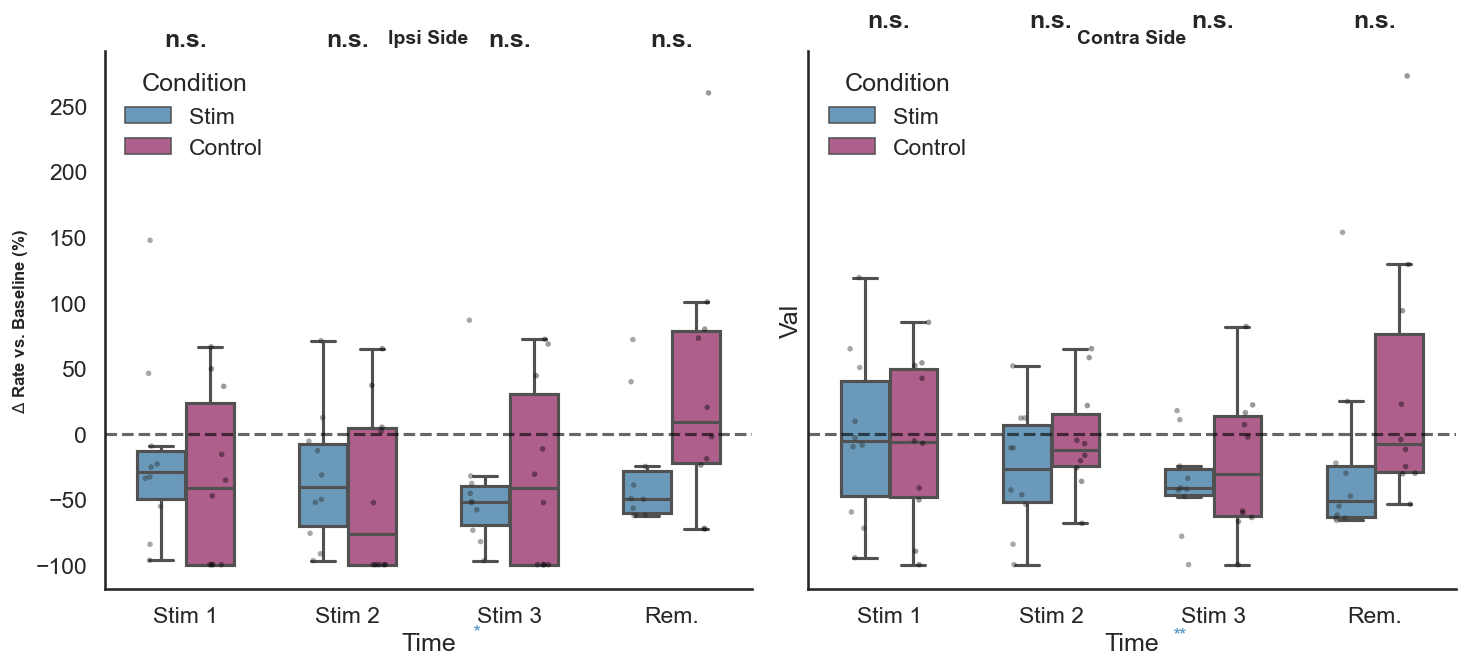

In [202]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. פונקציית עזר לחילוץ נתוני גירוי בלבד לפי זמן ---
def get_stim_only_time_split(df_stim, df_ctrl, side_label):
    """
    מחלץ את בלוקי הגירוי: עמודות 1, 3, 5 (גירוי 1, 2, 3) והשאר (7, 9...).
    עמודה 0 היא בייסליין, לכן מתחילים מ-1.
    """
    res = []
    # אינדקסים של בלוקי הגירוי במטריצה
    stim_indices = [1, 3, 5] 
    
    for df, cond in [(df_stim, 'Stim'), (df_ctrl, 'Control')]:
        # שלושת הגירויים הראשונים
        for i, col_idx in enumerate(stim_indices):
            if df.shape[1] > col_idx:
                vals = df.iloc[:, col_idx].dropna().values
                for v in vals:
                    res.append({'Val': v, 'Time': f'Stim {i+1}', 'Cond': cond, 'Side': side_label})
        
        # כל שאר בלוקי הגירוי (מאינדקס 7 והלאה, בקפיצות של 2)
        if df.shape[1] > 7:
            # לוקחים רק את העמודות האי-זוגיות שנותרו
            other_stim_cols = [c for c in range(7, df.shape[1], 2)]
            remainder_vals = df.iloc[:, other_stim_cols].mean(axis=1).dropna().values
            for v in remainder_vals:
                res.append({'Val': v, 'Time': 'Rem.', 'Cond': cond, 'Side': side_label})
    return res

# --- 2. הכנת הנתונים ---
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

data_all = get_time_split_data_v2 = get_stim_only_time_split(df_si, df_ci, 'Ipsi') + \
           get_stim_only_time_split(df_sc, df_cc, 'Contra')

df_plot = pd.DataFrame(data_all)

# --- 3. יצירת הגרף ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}
time_order = ['Stim 1', 'Stim 2', 'Stim 3', 'Rem.']

for ax, side in zip([ax1, ax2], ['Ipsi', 'Contra']):
    subset = df_plot[df_plot['Side'] == side]
    
    # בוקספלוט ונקודות
    sns.boxplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order, 
                palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order,
                  color='black', alpha=0.4, dodge=True, ax=ax, size=4)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.6)
    ax.set_title(f'{side} Side', fontweight='bold', fontsize=14)
    
    # --- סטטיסטיקה ---
    y_max = subset['Val'].max()
    y_min = subset['Val'].min()
    h = abs(y_max - y_min) * 0.05
    
    for i, t in enumerate(time_order):
        # שליפת ערכים למבחנים
        s_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Stim')]['Val'].values
        c_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Control')]['Val'].values
        
        if len(s_vals) > 1:
            # 1. מבחן Stim vs Control (למעלה)
            if len(c_vals) > 1:
                _, p_comp = stats.ttest_ind(s_vals, c_vals)
                stars = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'n.s.'
                ax.text(i, y_max + 2*h, stars, ha='center', fontweight='bold')

            # 2. מבחן Stim vs 0 (מתחת לבוקס הכחול)
            _, p_vs_0_s = stats.ttest_1samp(s_vals, 0)
            stars_0_s = '***' if p_vs_0_s < 0.001 else '**' if p_vs_0_s < 0.01 else '*' if p_vs_0_s < 0.05 else ''
            ax.text(i - 0.2, y_min - 3*h, stars_0_s, ha='center', color=colors['Stim'], fontweight='bold', fontsize=12)

            # 3. מבחן Control vs 0 (מתחת לבוקס הוורוד)
            if len(c_vals) > 1:
                _, p_vs_0_c = stats.ttest_1samp(c_vals, 0)
                stars_0_c = '***' if p_vs_0_c < 0.001 else '**' if p_vs_0_c < 0.01 else '*' if p_vs_0_c < 0.05 else ''
                ax.text(i + 0.2, y_min - 3*h, stars_0_c, ha='center', color=colors['Control'], fontweight='bold', fontsize=12)

# עיצוב סופי
ax1.set_ylabel(r'$\Delta$ Rate vs. Baseline (%)', fontsize=12, fontweight='bold')
for ax in [ax1, ax2]:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    # ניקוי מקרא כפול מה-stripplot אם מופיע
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Condition', frameon=False)

plt.tight_layout()
plt.show()

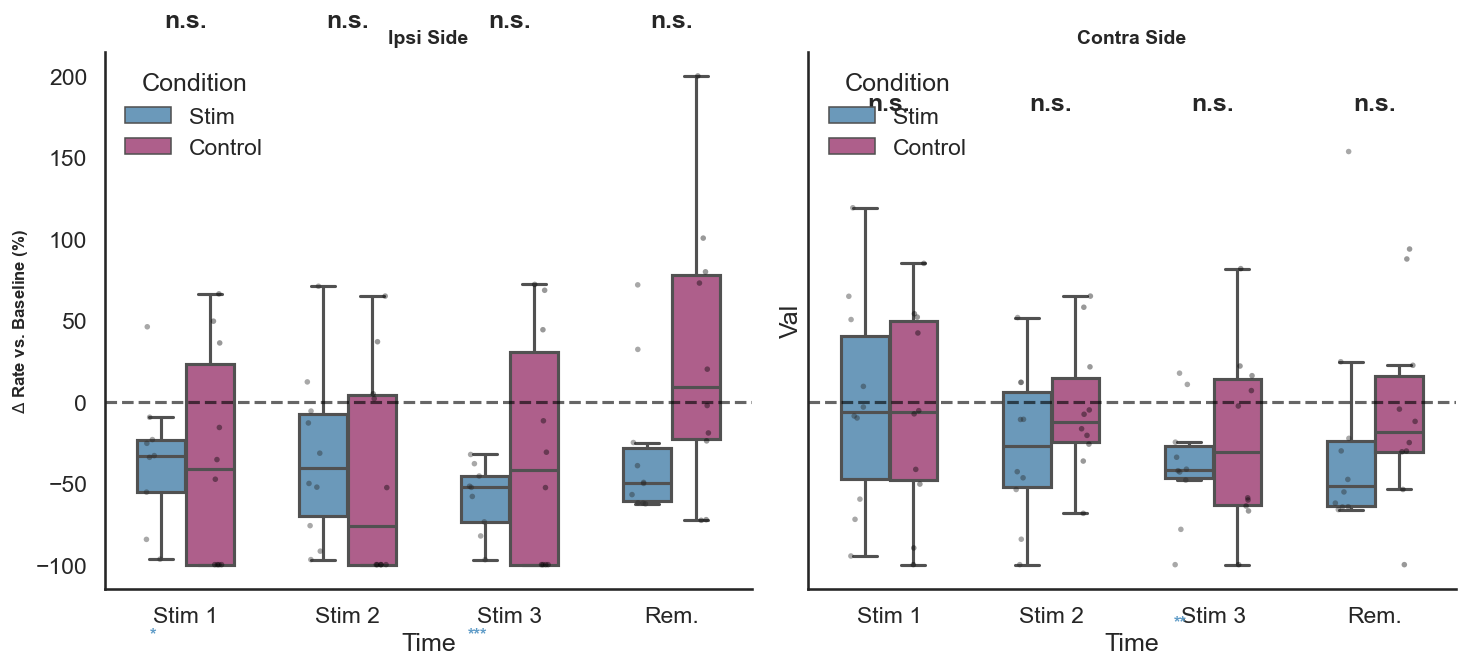

In [205]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. פונקציית עזר לחילוץ נתוני גירוי בלבד לפי זמן ---
def get_stim_only_time_split(df_stim, df_ctrl, side_label):
    """
    מחלץ את בלוקי הגירוי: עמודות 1, 3, 5 (גירוי 1, 2, 3) והשאר (7, 9...).
    עמודה 0 היא בייסליין, לכן מתחילים מ-1.
    """
    res = []
    # אינדקסים של בלוקי הגירוי במטריצה
    stim_indices = [1, 3, 5] 
    
    for df, cond in [(df_stim, 'Stim'), (df_ctrl, 'Control')]:
        # שלושת הגירויים הראשונים
        for i, col_idx in enumerate(stim_indices):
            if df.shape[1] > col_idx:
                vals = df.iloc[:, col_idx].dropna().values
                for v in vals:
                    res.append({'Val': v, 'Time': f'Stim {i+1}', 'Cond': cond, 'Side': side_label})
        
        # כל שאר בלוקי הגירוי (מאינדקס 7 והלאה, בקפיצות של 2)
        if df.shape[1] > 7:
            # לוקחים רק את העמודות האי-זוגיות שנותרו
            other_stim_cols = [c for c in range(7, df.shape[1], 2)]
            remainder_vals = df.iloc[:, other_stim_cols].mean(axis=1).dropna().values
            for v in remainder_vals:
                res.append({'Val': v, 'Time': 'Rem.', 'Cond': cond, 'Side': side_label})
    return res

# --- 2. הכנת הנתונים ---
df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=3)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=3)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=3)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=3)

data_all = get_time_split_data_v2 = get_stim_only_time_split(df_si, df_ci, 'Ipsi') + \
           get_stim_only_time_split(df_sc, df_cc, 'Contra')

df_plot = pd.DataFrame(data_all)

# --- 3. יצירת הגרף ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), sharey=True)
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}
time_order = ['Stim 1', 'Stim 2', 'Stim 3', 'Rem.']

for ax, side in zip([ax1, ax2], ['Ipsi', 'Contra']):
    subset = df_plot[df_plot['Side'] == side]
    
    # בוקספלוט ונקודות
    sns.boxplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order, 
                palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Time', y='Val', hue='Cond', data=subset, order=time_order,
                  color='black', alpha=0.4, dodge=True, ax=ax, size=4)
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.6)
    ax.set_title(f'{side} Side', fontweight='bold', fontsize=14)
    
    # --- סטטיסטיקה ---
    y_max = subset['Val'].max()
    y_min = subset['Val'].min()
    h = abs(y_max - y_min) * 0.05
    
    for i, t in enumerate(time_order):
        # שליפת ערכים למבחנים
        s_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Stim')]['Val'].values
        c_vals = subset[(subset['Time'] == t) & (subset['Cond'] == 'Control')]['Val'].values
        
        if len(s_vals) > 1:
            # 1. מבחן Stim vs Control (למעלה)
            if len(c_vals) > 1:
                _, p_comp = stats.ttest_ind(s_vals, c_vals)
                stars = '***' if p_comp < 0.001 else '**' if p_comp < 0.01 else '*' if p_comp < 0.05 else 'n.s.'
                ax.text(i, y_max + 2*h, stars, ha='center', fontweight='bold')

            # 2. מבחן Stim vs 0 (מתחת לבוקס הכחול)
            _, p_vs_0_s = stats.ttest_1samp(s_vals, 0)
            stars_0_s = '***' if p_vs_0_s < 0.001 else '**' if p_vs_0_s < 0.01 else '*' if p_vs_0_s < 0.05 else ''
            ax.text(i - 0.2, y_min - 3*h, stars_0_s, ha='center', color=colors['Stim'], fontweight='bold', fontsize=12)

            # 3. מבחן Control vs 0 (מתחת לבוקס הוורוד)
            if len(c_vals) > 1:
                _, p_vs_0_c = stats.ttest_1samp(c_vals, 0)
                stars_0_c = '***' if p_vs_0_c < 0.001 else '**' if p_vs_0_c < 0.01 else '*' if p_vs_0_c < 0.05 else ''
                ax.text(i + 0.2, y_min - 3*h, stars_0_c, ha='center', color=colors['Control'], fontweight='bold', fontsize=12)

# עיצוב סופי
ax1.set_ylabel(r'$\Delta$ Rate vs. Baseline (%)', fontsize=12, fontweight='bold')
for ax in [ax1, ax2]:
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    # ניקוי מקרא כפול מה-stripplot אם מופיע
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Condition', frameon=False)

plt.tight_layout()
plt.show()

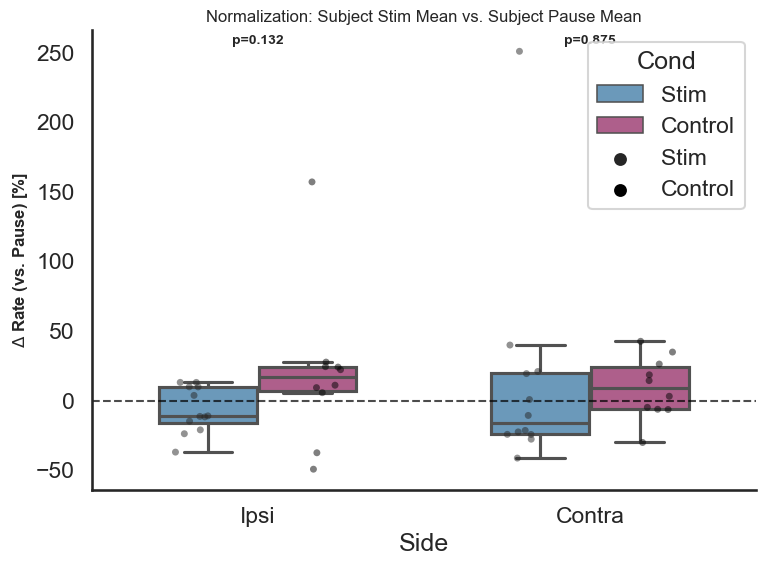

In [195]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# 1. הגדרת אינדקסים
stim_idx = [1, 3, 5, 7, 9, 11]
pause_idx = [0, 2, 4, 6, 8, 10]

def get_normalized_subject_means(data_dict, side):
    """
    הופך רשימה ל-DF, מנרמל כל נבדק לממוצע ההפסקות שלו, ומחזיר ממוצע לכל נבדק בבלוקי הגירוי.
    """
    # שליפת הנתונים והפיכתם ל-DataFrame (למקרה שהם רשימה)
    raw_data = data_dict['rates'][side]
    matrix = pd.DataFrame(raw_data)
    
    # חישוב ממוצע ההפסקות לכל נבדק (שורה)
    # שימוש ב-values.mean כדי לעקוף בעיות אינדקסים אם ישנן
    pause_means = matrix.iloc[:, pause_idx].mean(axis=1)
    
    # נרמול: אחוז שינוי מההפסקה
    # מונעים חלוקה ב-0 על ידי החלפת 0 ב-NaN זמני
    pause_means = pause_means.replace(0, np.nan)
    
    norm_matrix = matrix.iloc[:, stim_idx].div(pause_means, axis=0).sub(1).mul(100)
    
    # ניקוי ערכים לא תקינים וממוצע לכל נבדק
    return norm_matrix.mean(axis=1).dropna().values

# 2. איסוף נתונים (איחוד קבוצות)
try:
    v_si_stim = np.concatenate([
        get_normalized_subject_means(data_stim, 'ipsi'),
        get_normalized_subject_means(data_no_base, 'ipsi')
    ])
    v_sc_stim = np.concatenate([
        get_normalized_subject_means(data_stim, 'contra'),
        get_normalized_subject_means(data_no_base, 'contra')
    ])

    v_si_ctrl = get_normalized_subject_means(data_control, 'ipsi')
    v_sc_ctrl = get_normalized_subject_means(data_control, 'contra')

    # 3. בניית DataFrame לציור
    plot_list = []
    for v in v_si_stim: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Stim'})
    for v in v_sc_stim: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Stim'})
    for v in v_si_ctrl: plot_list.append({'Val': v, 'Side': 'Ipsi', 'Cond': 'Control'})
    for v in v_sc_ctrl: plot_list.append({'Val': v, 'Side': 'Contra', 'Cond': 'Control'})
    df_plot = pd.DataFrame(plot_list)

    # 4. יצירת הגרף
    fig, ax = plt.subplots(figsize=(8, 6))
    colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

    sns.boxplot(x='Side', y='Val', hue='Cond', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
    sns.stripplot(x='Side', y='Val', hue='Cond', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    
    # סטטיסטיקה פשוטה מעל הגרף (Stim vs Control)
    for i, side in enumerate(['Ipsi', 'Contra']):
        s_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Stim')]['Val']
        c_vals = df_plot[(df_plot['Side'] == side) & (df_plot['Cond'] == 'Control')]['Val']
        t_stat, p_val = stats.ttest_ind(s_vals, c_vals)
        
        y_max = df_plot['Val'].max()
        ax.text(i, y_max + 5, f'p={p_val:.3f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_ylabel(r'$\Delta$ Rate (vs. Pause) [%]', fontsize=12, fontweight='bold')
    ax.set_title('Normalization: Subject Stim Mean vs. Subject Pause Mean', fontsize=12)
    
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Error occurred: {e}")

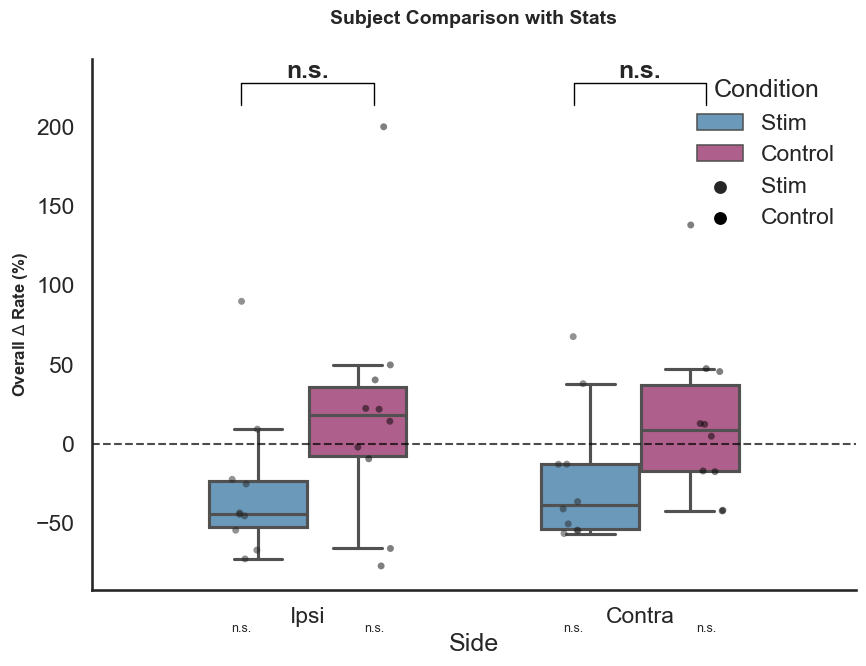

In [190]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. הכנת הנתונים (שימוש במבנה המדויק שלך) ---
stim_idx = [1, 3, 5, 7, 9, 11]

df_si = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_sc = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)
df_ci = get_clean_matrix(data_control['rates']['ipsi'], mode='baseline', threshold=1000)
df_cc = get_clean_matrix(data_control['rates']['contra'], mode='baseline', threshold=1000)

# חילוץ ממוצעים לנבדק
v_si = df_si.iloc[:, stim_idx].mean(axis=1).dropna().values
v_sc = df_sc.iloc[:, stim_idx].mean(axis=1).dropna().values
v_ci = df_ci.iloc[:, stim_idx].mean(axis=1).dropna().values
v_cc = df_cc.iloc[:, stim_idx].mean(axis=1).dropna().values

# ארגון ב-DataFrame
df_plot = pd.DataFrame(
    [{'Val': v, 'Side': 'Ipsi', 'Cond': 'Stim'} for v in v_si] +
    [{'Val': v, 'Side': 'Contra', 'Cond': 'Stim'} for v in v_sc] +
    [{'Val': v, 'Side': 'Ipsi', 'Cond': 'Control'} for v in v_ci] +
    [{'Val': v, 'Side': 'Contra', 'Cond': 'Control'} for v in v_cc]
)

# --- 2. חישוב סטטיסטיקה ---
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'n.s.'

# מבחן מול 0 (One-sample t-test)
p_vals_vs_0 = {
    ('Ipsi', 'Stim'): stats.ttest_1samp(v_si, 0)[1],
    ('Contra', 'Stim'): stats.ttest_1samp(v_sc, 0)[1],
    ('Ipsi', 'Control'): stats.ttest_1samp(v_ci, 0)[1],
    ('Contra', 'Control'): stats.ttest_1samp(v_cc, 0)[1]
}

# מבחן בין Stim ל-Control (Independent t-test)
p_comp_ipsi = stats.ttest_ind(v_si, v_ci)[1]
p_comp_contra = stats.ttest_ind(v_sc, v_cc)[1]

# --- 3. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'Stim': '#5e9bc7', 'Control': '#bb528c'}

sns.boxplot(x='Side', y='Val', hue='Cond', data=df_plot, palette=colors, ax=ax, width=0.6, fliersize=0)
sns.stripplot(x='Side', y='Val', hue='Cond', data=df_plot, color='black', alpha=0.5, dodge=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

# --- 4. הוספת אנוטציות סטטיסטיות ---
y_max = df_plot['Val'].max()
y_min = df_plot['Val'].min()
margin = abs(y_max - y_min) * 0.05

# אנוטציה להשוואה בין Stim ל-Control בתוך כל צד (הקו העליון)
for i, side in enumerate(['Ipsi', 'Contra']):
    p = p_comp_ipsi if side == 'Ipsi' else p_comp_contra
    x_pos = i
    # מיקום הברים מעל כל זוג בוקסים
    ax.plot([x_pos-0.2, x_pos-0.2, x_pos+0.2, x_pos+0.2], 
            [y_max + margin, y_max + 2*margin, y_max + 2*margin, y_max + margin], color='black', lw=1)
    ax.text(x_pos, y_max + 2.2*margin, get_stars(p), ha='center', fontweight='bold')

# אנוטציה למבחן מול 0 (למטה מתחת לכל בוקס)
for i, side in enumerate(['Ipsi', 'Contra']):
    for j, cond in enumerate(['Stim', 'Control']):
        p = p_vals_vs_0[(side, cond)]
        x_offset = -0.2 if j == 0 else 0.2
        ax.text(i + x_offset, y_min - 3*margin, get_stars(p), ha='center', fontsize=9)

ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Subject Comparison with Stats', fontsize=14, fontweight='bold', pad=25)
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
ax.legend(title='Condition', frameon=False, loc='upper right')

plt.tight_layout()
plt.show()

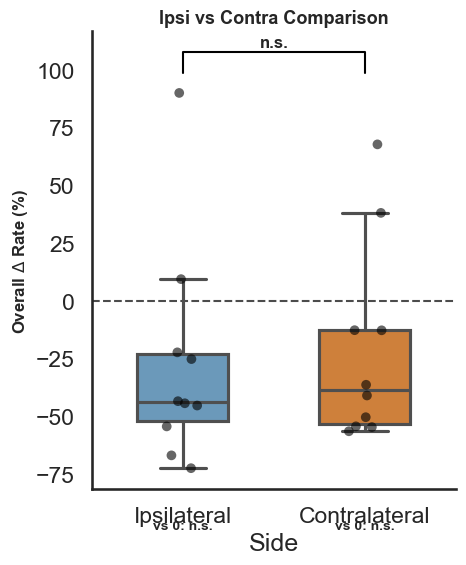

In [185]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# --- 1. הגדרת המשתנים שחסרו (ה-DataFrames) ---
# אנחנו מוציאים את הנתונים עבור 'ipsi' ועבור 'contra' מתוך ה-data_stim
df_rate_ipsi_stim = get_clean_matrix(data_stim['rates']['ipsi'], mode='baseline', threshold=1000)
df_rate_contra_stim = get_clean_matrix(data_stim['rates']['contra'], mode='baseline', threshold=1000)

# הגדרת האינדקסים של הבלוקים (אם לא הוגדר קודם)
stim_idx = [1, 3, 5, 7, 9, 11]

# --- 2. הפונקציה לציור הבוקספלוט עם הסטטיסטיקה ---
def plot_subject_comparison_with_stats(df_ipsi, df_contra, idx_list):
    # חילוץ ממוצעים לכל נבדק
    ipsi_vals = df_ipsi.iloc[:, idx_list].mean(axis=1).dropna().values
    contra_vals = df_contra.iloc[:, idx_list].mean(axis=1).dropna().values
    
    # חישוב סטטיסטיקה מול 0 (One-sample t-test)
    t_ipsi, p_ipsi = stats.ttest_1samp(ipsi_vals, 0)
    t_contra, p_contra = stats.ttest_1samp(contra_vals, 0)
    
    # חישוב סטטיסטיקה בין הקבוצות (Independent t-test)
    t_comp, p_comp = stats.ttest_ind(ipsi_vals, contra_vals)
    
    # הכנת הנתונים לציור
    plot_data = pd.DataFrame({
        'Change': np.concatenate([ipsi_vals, contra_vals]),
        'Side': ['Ipsilateral'] * len(ipsi_vals) + ['Contralateral'] * len(contra_vals)
    })

    fig, ax = plt.subplots(figsize=(5, 6))
    
    # ציור בוקספלוט ונקודות
    sns.boxplot(x='Side', y='Change', data=plot_data, palette=['#5e9bc7', '#e67e22'], 
                ax=ax, width=0.5, fliersize=0, zorder=1)
    sns.stripplot(x='Side', y='Change', data=plot_data, color='black', 
                  alpha=0.6, size=7, ax=ax, zorder=2)
    
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=0)

    # פונקציית עזר לכוכביות
    def get_stars(p):
        if p < 0.001: return '***'
        if p < 0.01: return '**'
        if p < 0.05: return '*'
        return 'n.s.'

    # אנוטציה להשוואה בין הקבוצות (קו עליון)
    y_max = plot_data['Change'].max()
    margin = plot_data['Change'].std() * 0.2
    ax.plot([0, 0, 1, 1], [y_max + margin, y_max + 2*margin, y_max + 2*margin, y_max + margin], color='black', lw=1.5)
    ax.text(0.5, y_max + 2.1*margin, get_stars(p_comp), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # אנוטציות למבחן מול 0 (למטה)
    y_min = plot_data['Change'].min() - 3*margin
    ax.text(0, y_min, f"vs 0: {get_stars(p_ipsi)}", ha='center', fontsize=10, fontweight='bold')
    ax.text(1, y_min, f"vs 0: {get_stars(p_contra)}", ha='center', fontsize=10, fontweight='bold')

    # עיצוב
    ax.set_ylabel(r'Overall $\Delta$ Rate (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Ipsi vs Contra Comparison', fontsize=13, fontweight='bold')
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# --- 3. הרצה ---
plot_subject_comparison_with_stats(df_rate_ipsi_stim, df_rate_contra_stim, stim_idx)

--- Statistics for STIM ---
Stim 1 - Between Groups p: 0.4256
Stim 2 - Between Groups p: 0.3410
Stim 3 - Between Groups p: 0.9697
Last Blocks - Between Groups p: 0.1041


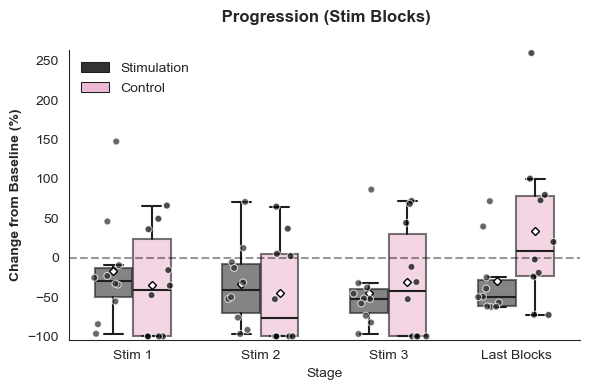

In [27]:

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subjects, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים (מבוסס על prepare_final_data מהשלב הקודם)
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(6, 4))
    sns.set_style("white")
    
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה בולטות
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=5, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # 4. הגדרות גובה לסטטיסטיקה
    y_within = 150 # גובה כוכביות מול בייסליין
    y_between_start = 175 # גובה התחלה לסוגר בין קבוצות
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. סטטיסטיקה בתוך קבוצה (מול 0) - בגובה 150
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. סטטיסטיקה בין קבוצות + קו מחבר
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                # ציור הסוגר (Bracket)
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 5 # גובה ה"כתפיים" של הסוגר
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='#555555')
                plt.text((x1+x2)/2, y_between_start + h + 2, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים ומקרא
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylim(-105, 264) # הגדלת הטווח כדי שיהיה מקום לסוגרים
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f" Progression ({block_to_plot.capitalize()} Blocks)", fontweight='bold', pad=20)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False, loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

--- Statistics for STIM ---


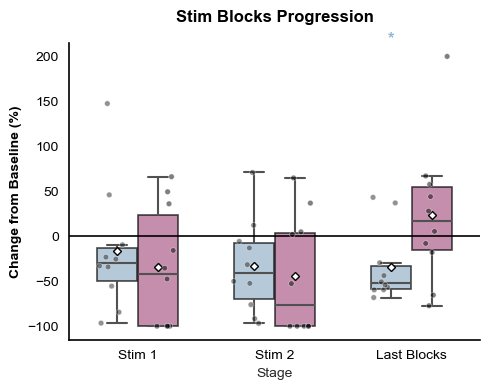

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    # השתמשתי ב-enumerate במקום subjects כדי למנוע בעיות אם הרשימה לא באותו אורך
    for i, subj_rates in enumerate(raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            # הגדרת 3 עמודות בלבד
            stages = ['Stim 1', 'Stim 2', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # לוגיקה מעודכנת: 
        # נקודה 1, נקודה 2, וממוצע של כל השאר (החל מאינדקס 2, שזה הגירוי השלישי)
        row = [pct_changes[0], 
               pct_changes[1], 
               np.nanmean(pct_changes[2:])]
        
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # ללא סינון חריגים (כפי שביקשת)
    
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    # צבעים מעודכנים
    pal = {'Stimulation': '#8db4d3', 'Control': '#bb528c'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.2), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.5, size=4, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white')

    # 4. הגדרות סטטיסטיקה (מותאמות לערכים ללא סינון)
    y_max = df_combined['Change_Percent'].max()
    y_within = y_max + 15
    y_between_start = y_max + 45
    
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. בתוך קבוצה
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 10
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='black')
                plt.text((x1+x2)/2, y_between_start + h, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים שחור מוחלט
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2)
    
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=1.2, colors='black')
    
    plt.ylabel("Change from Baseline (%)", fontweight='bold', color='black')
    plt.title(f"{block_to_plot.capitalize()} Blocks Progression", fontweight='bold', color='black', pad=15)
    
    if ax.get_legend(): ax.get_legend().remove()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

--- Statistics for STIM ---


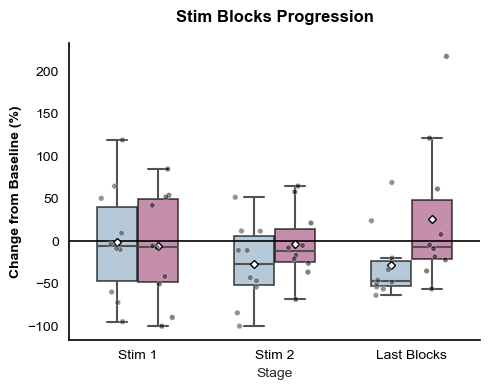

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    # השתמשתי ב-enumerate במקום subjects כדי למנוע בעיות אם הרשימה לא באותו אורך
    for i, subj_rates in enumerate(raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            # הגדרת 3 עמודות בלבד
            stages = ['Stim 1', 'Stim 2', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # לוגיקה מעודכנת: 
        # נקודה 1, נקודה 2, וממוצע של כל השאר (החל מאינדקס 2, שזה הגירוי השלישי)
        row = [pct_changes[0], 
               pct_changes[1], 
               np.nanmean(pct_changes[2:])]
        
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # ללא סינון חריגים (כפי שביקשת)
    
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'contra', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'contra', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    # צבעים מעודכנים
    pal = {'Stimulation': '#8db4d3', 'Control': '#bb528c'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.7, edgecolor='black', linewidth=1.2), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.5, size=4, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white')

    # 4. הגדרות סטטיסטיקה (מותאמות לערכים ללא סינון)
    y_max = df_combined['Change_Percent'].max()
    y_within = y_max + 15
    y_between_start = y_max + 45
    
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. בתוך קבוצה
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 10
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='black')
                plt.text((x1+x2)/2, y_between_start + h, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים שחור מוחלט
    plt.axhline(0, color='black', linestyle='-', linewidth=1.2)
    
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    ax.tick_params(axis='both', which='major', direction='out', length=4, width=1.2, colors='black')
    
    plt.ylabel("Change from Baseline (%)", fontweight='bold', color='black')
    plt.title(f"{block_to_plot.capitalize()} Blocks Progression", fontweight='bold', color='black', pad=15)
    
    if ax.get_legend(): ax.get_legend().remove()
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')

In [29]:
# all data from 2 groups including pause
import statsmodels.formula.api as smf

def get_raw_long(data_dict, group_name):
    # כאן אני לוקח את הרשימה הגולמית של הבלוקים
    # ההנחה היא שכל איבר ברשימה הוא נבדק, ובו מערך של ערכי Rate לכל בלוק
    raw_data = data_dict['rates']['all']
    
    rows = []
    for sub_idx, sub_rates in enumerate(raw_data):
        # sub_rates הוא מערך של ערכים עבור נבדק אחד (למשל 13 בלוקים: BL, S1, P1...)
        for block_idx, value in enumerate(sub_rates):
            # הגדרת סוג הבלוק
            if block_idx == 0:
                condition = 'Baseline'
                is_stim = 0
            elif block_idx % 2 != 0:
                condition = 'Stim'
                is_stim = 1
            else:
                condition = 'Pause'
                is_stim = 0
                
            rows.append({
                'Subject_ID': f"{group_name}_{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Condition': condition,
                'Is_Stim': is_stim,
                'Rate': value
            })
            
    return pd.DataFrame(rows)

# איחוד הקבוצות
df_raw_ctrl = get_raw_long(data_control, 'Control')
df_raw_stim = get_raw_long(data_stim, 'Stimulation')
full_df_raw = pd.concat([df_raw_ctrl, df_raw_stim])

In [30]:
full_df_raw

,Subject_ID,Group,Block_Idx,Condition,Is_Stim,Rate
0,Control_0,Control,0,Baseline,0,26.064516
1,Control_0,Control,1,Stim,1,23.800000
2,Control_0,Control,2,Pause,0,7.400000
3,Control_0,Control,3,Stim,1,19.400000
4,Control_0,Control,4,Pause,0,25.800000
...,...,...,...,...,...,...
145,Stimulation_9,Stimulation,4,Pause,0,16.424214
146,Stimulation_9,Stimulation,5,Stim,1,10.781379
147,Stimulation_9,Stimulation,6,Pause,0,15.264337
148,Stimulation_9,Stimulation,7,Stim,1,11.916605


In [40]:
# מודל ללא פרמטר זמן (Block_Idx)
# בודק רק את האינטראקציה בין הקבוצה לבין מצב הגירוי/הפסקה
model_simple = smf.mixedlm(
    "Rate ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_raw, 
    groups=full_df_raw["Subject_ID"]
)

result_simple = model_simple.fit()
print(result_simple.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Rate     
No. Observations:                320                  Method:                          REML     
No. Groups:                      20                   Scale:                           19.9637  
Min. group size:                 9                    Log-Likelihood:                  -967.5740
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 16.0                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              6.649

In [31]:
# מודל עם פרמטר זמן (Block_Idx)
df_final = full_df_raw.dropna(subset=['Rate'])

# מודל Mixed Effects
# Rate ~ Group * Is_Stim + (1 | Subject_ID)
# אנחנו מוסיפים גם את Block_Idx כמשתנה בקרה (Covariate) כדי לשלוט על דעיכה טבעית בזמן
model_raw = smf.mixedlm("Rate ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        df_final, 
                        groups="Subject_ID")

result_raw = model_raw.fit()
print(result_raw.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Rate     
No. Observations:                320                  Method:                          REML     
No. Groups:                      20                   Scale:                           19.6977  
Min. group size:                 9                    Log-Likelihood:                  -967.5064
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 16.0                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              7.433

In [42]:
import pandas as pd
import statsmodels.formula.api as smf

def get_amplitude_long(data_dict, group_name, is_no_base=False):
    # שימוש בפיצ'ר האמפליטודה
    raw_data = data_dict['relative_spike_amplitude']['all']
    rows = []
    
    for sub_idx, sub_amps in enumerate(raw_data):
        for block_idx, value in enumerate(sub_amps):
            # אם זה no_base, אנחנו עדיין שומרים את הבלוקים אבל נדע שהם ללא בייסליין אמין
            # המודל MixedLM יטפל בזה דרך ה-Random Intercept
            if is_no_base and block_idx == 0:
                continue
                
            condition = 'Stim' if block_idx % 2 != 0 else 'Pause'
            if block_idx == 0: condition = 'Baseline'
            
            rows.append({
                'Subject_ID': f"{group_name}_{'NB_' if is_no_base else ''}{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if block_idx % 2 != 0 else 0,
                'Amplitude': value
            })
    return pd.DataFrame(rows)

# יצירת ה-DF המאוחד
df_amp_ctrl = get_amplitude_long(data_control, 'Control')
df_amp_stim = get_amplitude_long(data_stim, 'Stimulation')
full_df_amp = pd.concat([df_amp_ctrl, df_amp_stim]).dropna(subset=['Amplitude'])

In [43]:
# מודל פשוט: Amplitude ~ Group * Is_Stim
model_amp_simple = smf.mixedlm(
    "Amplitude ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_amp, 
    groups=full_df_amp["Subject_ID"]
)

result_amp_simple = model_amp_simple.fit()
print("--- Simple Amplitude Model ---")
print(result_amp_simple.summary())

--- Simple Amplitude Model ---
                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                314                  Method:                          REML     
No. Groups:                      20                   Scale:                           0.4614   
Min. group size:                 9                    Log-Likelihood:                  -359.0134
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.7                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                    

In [44]:
# בניית המודל: האם האמפליטודה מושפעת מהאינטראקציה בין קבוצה לגירוי?
model_amp = smf.mixedlm("Amplitude ~ C(Group, Treatment('Control')) * Is_Stim + Block_Idx", 
                        full_df_amp, 
                        groups="Subject_ID")

result_amp = model_amp.fit()
print(result_amp.summary())

                             Mixed Linear Model Regression Results
Model:                           MixedLM              Dependent Variable:              Amplitude
No. Observations:                314                  Method:                          REML     
No. Groups:                      20                   Scale:                           0.4490   
Min. group size:                 9                    Log-Likelihood:                  -358.3087
Max. group size:                 31                   Converged:                       Yes      
Mean group size:                 15.7                                                           
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept                                              3.860

In [88]:
# with 515 545
import pandas as pd
import statsmodels.formula.api as smf

def get_complete_long_format(main_data, no_base_data, group_name, feature_key):
    rows = []
    
    # 1. עיבוד הקבוצה הראשית (כולל בייסליין)
    raw_main = main_data[feature_key]['all']
    for sub_idx, values in enumerate(raw_main):
        for block_idx, val in enumerate(values):
            rows.append({
                'Subject_ID': f"{group_name}_{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if (block_idx > 0 and block_idx % 2 != 0) else 0,
                'Value': val
            })
            
    # 2. עיבוד נבדקי ה-no_base (דילוג על בלוק 0)
    raw_nb = no_base_data[feature_key]['all']
    for sub_idx, values in enumerate(raw_nb):
        for block_idx, val in enumerate(values):
            if block_idx == 0:
                continue  # דילוג על בייסליין חסר/לא אמין
            rows.append({
                'Subject_ID': f"{group_name}_NB_{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if block_idx % 2 != 0 else 0,
                'Value': val
            })
            
    return pd.DataFrame(rows)

# --- הרצה עבור קצב ירי (Firing Rate) ---

# בניית ה-DF המלא כולל קבוצת הביקורת והנבדקים החדשים
df_rate_ctrl = get_complete_long_format(data_control, {'rates':{'all':[]}}, 'Control', 'rates') # ביקורת (ללא NB)
df_rate_stim = get_complete_long_format(data_stim, no_base, 'Stimulation', 'rates')
full_df_rate = pd.concat([df_rate_ctrl, df_rate_stim]).dropna(subset=['Value'])

print("=== FIRING RATE: Group * Is_Stim Interaction ===")
model_rate = smf.mixedlm(
    "Value ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_rate, 
    groups=full_df_rate["Subject_ID"]
).fit()
print(model_rate.summary())

# --- הרצה עבור אמפליטודה (Amplitude) ---

df_amp_ctrl = get_complete_long_format(data_control, {'relative_spike_amplitude':{'all':[]}}, 'Control', 'relative_spike_amplitude')
df_amp_stim = get_complete_long_format(data_stim, no_base, 'Stimulation', 'relative_spike_amplitude')
full_df_amp = pd.concat([df_amp_ctrl, df_amp_stim]).dropna(subset=['Value'])

print("\n=== AMPLITUDE: Group * Is_Stim Interaction ===")
model_amp = smf.mixedlm(
    "Value ~ C(Group, Treatment('Control')) * Is_Stim", 
    full_df_amp, 
    groups=full_df_amp["Subject_ID"]
).fit()
print(model_amp.summary())

=== FIRING RATE: Group * Is_Stim Interaction ===
                             Mixed Linear Model Regression Results
Model:                          MixedLM              Dependent Variable:              Value     
No. Observations:               342                  Method:                          REML      
No. Groups:                     22                   Scale:                           18.9586   
Min. group size:                9                    Log-Likelihood:                  -1027.0272
Max. group size:                31                   Converged:                       Yes       
Mean group size:                15.5                                                            
------------------------------------------------------------------------------------------------
                                                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------------
Intercept  

## Figure 3

In [60]:
no_base = joblib.load('no_base_515_545.pkl')
no_base['relative_spike_amplitude']['all']  # בדיקה שהנתונים נטענו כראוי

[[5.0776607376721845,
  0.7549513677110946,
  1.3743995776704292,
  1.2705288885251047,
  2.7550082402852976,
  1.1328717185721837,
  1.831602463115375,
  1.2882814670938028,
  1.2411934783934906,
  1.424039874317983,
  1.7952670597939915,
  1.2711867083169812,
  0.9674750126324017],
 [5.716396515969416,
  5.008920075957256,
  6.2553821296456205,
  3.2208303480034655,
  5.0335565432186,
  3.905628663282357,
  4.165182833360674,
  5.031971921366808,
  2.5918809509560026,
  7.0801932186582475,
  3.307345902800275]]

In [50]:
import statsmodels.formula.api as smf

# סינון: רק קבוצת הגירוי ורק בלוקים שגדולים מ-0 (החל מהגירוי הראשון)
df_rate_stim_active = df_final[(df_final['Group'] == 'Stimulation') & (df_final['Block_Idx'] > 0)].copy()
df_amp_stim_active = full_df_amp[(full_df_amp['Group'] == 'Stimulation') & (full_df_amp['Block_Idx'] > 0)].copy()

# --- 1. מודלים עבור Firing Rate (ללא בייסליין) ---
model_rate_simple = smf.mixedlm("Rate ~ Is_Stim", df_rate_stim_active, groups=df_rate_stim_active["Subject_ID"])
result_rate_simple = model_rate_simple.fit()

model_rate_time = smf.mixedlm("Rate ~ Is_Stim + Block_Idx", df_rate_stim_active, groups=df_rate_stim_active["Subject_ID"])
result_rate_time = model_rate_time.fit()

# --- 2. מודלים עבור Amplitude (ללא בייסליין) ---
model_amp_simple = smf.mixedlm("Amplitude ~ Is_Stim", df_amp_stim_active, groups=df_amp_stim_active["Subject_ID"])
result_amp_simple = model_amp_simple.fit()

model_amp_time = smf.mixedlm("Amplitude ~ Is_Stim + Block_Idx", df_amp_stim_active, groups=df_amp_stim_active["Subject_ID"])
result_amp_time = model_amp_time.fit()

# הדפסת סיכומים
print("--- Firing Rate (Active Only): Simple ---")
print(result_rate_simple.summary())
print("\n--- Firing Rate (Active Only): With Time ---")
print(result_rate_time.summary())
print("\n--- Amplitude (Active Only): Simple ---")
print(result_amp_simple.summary())
print("\n--- Amplitude (Active Only): With Time ---")
print(result_amp_time.summary())

--- Firing Rate (Active Only): Simple ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Rate     
No. Observations: 140     Method:             REML     
No. Groups:       10      Scale:              20.8693  
Min. group size:  8       Log-Likelihood:     -428.8204
Max. group size:  30      Converged:          Yes      
Mean group size:  14.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    10.094    3.450  2.926 0.003  3.333 16.855
Is_Stim      -1.854    0.772 -2.401 0.016 -3.368 -0.341
Group Var   115.697   12.446                           


--- Firing Rate (Active Only): With Time ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Rate     
No. Observations: 140     Method:             REML     
No. Groups:       10      Scale: 

In [87]:
import statsmodels.formula.api as smf

# סינון: רק קבוצת הגירוי ורק בלוקים שגדולים מ-0 (החל מהגירוי הראשון)
df_rate_stim_active = df_final[(df_final['Group'] == 'Stimulation')].copy()
df_amp_stim_active = full_df_amp[(full_df_amp['Group'] == 'Stimulation')].copy()

# --- 1. מודלים עבור Firing Rate (ללא בייסליין) ---
model_rate_simple = smf.mixedlm("Rate ~ Is_Stim", df_rate_stim_active, groups=df_rate_stim_active["Subject_ID"])
result_rate_simple = model_rate_simple.fit()

model_rate_time = smf.mixedlm("Rate ~ Is_Stim + Block_Idx", df_rate_stim_active, groups=df_rate_stim_active["Subject_ID"])
result_rate_time = model_rate_time.fit()

# --- 2. מודלים עבור Amplitude (ללא בייסליין) ---
model_amp_simple = smf.mixedlm("Amplitude ~ Is_Stim", df_amp_stim_active, groups=df_amp_stim_active["Subject_ID"])
result_amp_simple = model_amp_simple.fit()

model_amp_time = smf.mixedlm("Amplitude ~ Is_Stim + Block_Idx", df_amp_stim_active, groups=df_amp_stim_active["Subject_ID"])
result_amp_time = model_amp_time.fit()

# הדפסת סיכומים
print("--- Firing Rate (Active Only): Simple ---")
print(result_rate_simple.summary())
print("\n--- Firing Rate (Active Only): With Time ---")
print(result_rate_time.summary())
print("\n--- Amplitude (Active Only): Simple ---")
print(result_amp_simple.summary())
print("\n--- Amplitude (Active Only): With Time ---")
print(result_amp_time.summary())

--- Firing Rate (Active Only): Simple ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Rate     
No. Observations: 150     Method:             REML     
No. Groups:       10      Scale:              22.6528  
Min. group size:  9       Log-Likelihood:     -464.2416
Max. group size:  31      Converged:          Yes      
Mean group size:  15.0                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    10.476    3.407  3.074 0.002  3.797 17.154
Is_Stim      -2.117    0.779 -2.717 0.007 -3.645 -0.590
Group Var   113.029   11.649                           


--- Firing Rate (Active Only): With Time ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Rate     
No. Observations: 150     Method:             REML     
No. Groups:       10      Scale: 

In [61]:
import pandas as pd
import statsmodels.formula.api as smf

# --- 1. איחוד ועיבוד נתונים (כולל no_base) ---

def get_long_format_data(data_dict, group_name, feature_key, is_no_base=False):
    raw_data = data_dict[feature_key]['all']
    rows = []
    for sub_idx, sub_values in enumerate(raw_data):
        for block_idx, value in enumerate(sub_values):
            rows.append({
                'Subject_ID': f"{group_name}_{'NB_' if is_no_base else ''}{sub_idx}",
                'Group': group_name,
                'Block_Idx': block_idx,
                'Is_Stim': 1 if block_idx % 2 != 0 else 0,
                'Value': value
            })
    return pd.DataFrame(rows)

# הכנת הנתונים
df_rate_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'rates', False),
    get_long_format_data(no_base, 'Stimulation', 'rates', True)
])

df_amp_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'relative_spike_amplitude', False),
    get_long_format_data(no_base, 'Stimulation', 'relative_spike_amplitude', True)
])

# סינון: רק בלוקים אקטיביים (>0) ואיפוס אינדקס (reset_index) - זה השלב שפותר את השגיאה
df_rate_active = df_rate_all[df_rate_all['Block_Idx'] > 0].reset_index(drop=True)
df_amp_active = df_amp_all[df_amp_all['Block_Idx'] > 0].reset_index(drop=True)

# --- 2. הרצת המודלים (ללא שגיאות אינדקס) ---

print("=== FIRING RATE RESULTS (Stimulation Only, Blocks > 0) ===")
# מודל פשוט
model_rate_simple = smf.mixedlm("Value ~ Is_Stim", df_rate_active, groups=df_rate_active["Subject_ID"]).fit()
print(model_rate_simple.summary())

# מודל עם זמן
model_rate_time = smf.mixedlm("Value ~ Is_Stim + Block_Idx", df_rate_active, groups=df_rate_active["Subject_ID"]).fit()
print(model_rate_time.summary())

=== FIRING RATE RESULTS (Stimulation Only, Blocks > 0) ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 162     Method:             REML     
No. Groups:       12      Scale:              18.5625  
Min. group size:  8       Log-Likelihood:     -488.3318
Max. group size:  30      Converged:          Yes      
Mean group size:  13.5                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     8.782    2.960  2.967 0.003  2.981 14.583
Is_Stim      -1.555    0.677 -2.297 0.022 -2.882 -0.228
Group Var   102.112   10.552                           

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 162     Method:             REML     
No. Groups:       12      Scale:              17.9030  
Min. g

In [59]:
df_rate_active

,Subject_ID,Group,Block_Idx,Is_Stim,Value
0,Stimulation_0,Stimulation,1,1,5.796996
1,Stimulation_0,Stimulation,2,0,7.005146
2,Stimulation_0,Stimulation,3,1,2.921098
3,Stimulation_0,Stimulation,4,0,2.064271
4,Stimulation_0,Stimulation,5,1,3.434616
...,...,...,...,...,...
157,Stimulation_NB_1,Stimulation,6,0,1.678896
158,Stimulation_NB_1,Stimulation,7,1,2.950402
159,Stimulation_NB_1,Stimulation,8,0,1.357743
160,Stimulation_NB_1,Stimulation,9,1,0.520380


In [55]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. איחוד מחדש של נתוני האמפליטודה (כולל no_base)
df_amp_all = pd.concat([
    get_long_format_data(data_stim, 'Stimulation', 'relative_spike_amplitude', False),
    get_long_format_data(no_base, 'Stimulation', 'relative_spike_amplitude', True)
])

# 2. סינון בלוקים אקטיביים והסרת NaN (קריטי לפני איפוס אינדקס)
df_amp_active = df_amp_all[df_amp_all['Block_Idx'] > 0].dropna(subset=['Value']).copy()

# 3. איפוס אינדקס כפול כדי להבטיח שאין שום קשר לאינדקס הישן
df_amp_active = df_amp_active.reset_index(drop=True)

print("=== AMPLITUDE RESULTS (Stimulation Only, Blocks > 0) ===")

# מודל פשוט
model_amp_simple = smf.mixedlm("Value ~ Is_Stim", 
                               df_amp_active, 
                               groups=df_amp_active["Subject_ID"]).fit()
print("\n--- Simple Model (Stim vs Pause) ---")
print(model_amp_simple.summary())

# מודל עם זמן
model_amp_time = smf.mixedlm("Value ~ Is_Stim + Block_Idx", 
                             df_amp_active, 
                             groups=df_amp_active["Subject_ID"]).fit()
print("\n--- Model with Time (Block_Idx) ---")
print(model_amp_time.summary())

=== AMPLITUDE RESULTS (Stimulation Only, Blocks > 0) ===

--- Simple Model (Stim vs Pause) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 161     Method:             REML     
No. Groups:       12      Scale:              0.4575   
Min. group size:  8       Log-Likelihood:     -187.0281
Max. group size:  30      Converged:          Yes      
Mean group size:  13.4                                 
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     3.135    0.326  9.628 0.000  2.497  3.773
Is_Stim      -0.166    0.107 -1.557 0.119 -0.375  0.043
Group Var     1.198    0.806                           


--- Model with Time (Block_Idx) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value    
No. Observations: 161     Method:            

In [56]:
df_amp_active

,Subject_ID,Group,Block_Idx,Is_Stim,Value
0,Stimulation_0,Stimulation,1,1,3.397493
1,Stimulation_0,Stimulation,2,0,3.726531
2,Stimulation_0,Stimulation,3,1,4.994247
3,Stimulation_0,Stimulation,4,0,3.772729
4,Stimulation_0,Stimulation,5,1,2.303360
...,...,...,...,...,...
156,Stimulation_NB_1,Stimulation,6,0,4.165183
157,Stimulation_NB_1,Stimulation,7,1,5.031972
158,Stimulation_NB_1,Stimulation,8,0,2.591881
159,Stimulation_NB_1,Stimulation,9,1,7.080193


In [78]:
df_amp_active.to_csv('frontal_and_control_amp_blocks_v2.csv', index=False)

In [76]:
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np

# 1. פונקציית נירמול משופרת (פותרת את בעיית האינדקס וה-NaN)
def normalize_to_pause_mean_safe(df):
    # סינון בלוקים אקטיביים והסרת שורות ריקות ב-Value
    df_active = df[df['Block_Idx'] > 0].dropna(subset=['Value']).copy()
    
    normalized_rows = []
    for sub in df_active['Subject_ID'].unique():
        sub_data = df_active[df_active['Subject_ID'] == sub].copy()
        
        # חישוב ממוצע הפסקות לנבדק
        pause_data = sub_data[sub_data['Is_Stim'] == 0]['Value']
        if not pause_data.empty:
            pause_mean = pause_data.mean()
            if pause_mean > 0:
                sub_data['Value_Norm'] = (sub_data['Value'] / pause_mean) * 100
                normalized_rows.append(sub_data)
            
    # איחוד מחדש ואיפוס אינדקס קריטי למניעת IndexError
    return pd.concat(normalized_rows).reset_index(drop=True)

# 2. הכנת הנתונים מחדש
df_rate_norm = normalize_to_pause_mean_safe(df_rate_all)
df_amp_norm = normalize_to_pause_mean_safe(df_amp_all)

# 3. פונקציה להרצת המודלים
def run_final_models(df, label):
    print(f"\n{'='*25} {label} {'='*25}")
    
    # מודל פשוט
    try:
        res_simple = smf.mixedlm("Value_Norm ~ Is_Stim", df, groups=df["Subject_ID"]).fit()
        print("\n--- Simple Model Summary ---")
        print(res_simple.summary())
    except Exception as e:
        print(f"Simple model error: {e}")

    # מודל עם זמן
    try:
        res_time = smf.mixedlm("Value_Norm ~ Is_Stim + Block_Idx", df, groups=df["Subject_ID"]).fit()
        print("\n--- Model with Time Summary ---")
        print(res_time.summary())
    except Exception as e:
        print(f"Time model error: {e}")

# הרצה סופית
run_final_models(df_rate_norm, "FIRING RATE (NORMALIZED)")
run_final_models(df_amp_norm, "AMPLITUDE (NORMALIZED)")


========================= FIRING RATE (NORMALIZED) =========================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



--- Simple Model Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 162     Method:             REML      
No. Groups:       12      Scale:              2661.6424 
Min. group size:  8       Log-Likelihood:     -862.3605 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.5                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  100.000    5.365 18.640 0.000  89.485 110.515
Is_Stim     -2.076    8.107 -0.256 0.798 -17.965  13.813
Group Var    0.000                                      


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)



--- Model with Time Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 162     Method:             REML      
No. Groups:       12      Scale:              2606.0663 
Min. group size:  8       Log-Likelihood:     -859.7603 
Max. group size:  30      Converged:          Yes       
Mean group size:  13.5                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  111.841    7.982 14.011 0.000  96.196 127.487
Is_Stim     -3.341    8.043 -0.415 0.678 -19.105  12.423
Block_Idx   -1.265    0.583 -2.169 0.030  -2.409  -0.122
Group Var    0.000                                      


========================= AMPLITUDE (NORMALIZED) =========================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(



--- Simple Model Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 161     Method:             REML      
No. Groups:       12      Scale:              535.2717  
Min. group size:  8       Log-Likelihood:     -731.1107 
Max. group size:  30      Converged:          No        
Mean group size:  13.4                                  
--------------------------------------------------------
            Coef.  Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept   99.810    2.846 35.067 0.000  94.232 105.389
Is_Stim     -6.362    3.647 -1.744 0.081 -13.511   0.787
Group Var   14.415    0.951                             


--- Model with Time Summary ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: Value_Norm
No. Observations: 161     Method:             REML      
No. Groups:       12      Scale:            

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 1.922572
  warnings.warn(msg, ConvergenceWarning)


In [82]:
import pandas as pd
import statsmodels.formula.api as smf

def run_hierarchical_pct_model(df_input, label):
    # 1. נרמול לכל נבדק לפי ממוצע הפסקות
    normalized_list = []
    for sub in df_input['Subject_ID'].unique():
        sub_data = df_input[df_input['Subject_ID'] == sub].copy()
        pause_mean = sub_data[sub_data['Is_Stim'] == 0]['Value'].mean()
        if pause_mean > 0:
            # הנוסחה: ((ערך - ממוצע הפסקות) / ממוצע הפסקות) * 100
            sub_data['pct_norm_block'] = ((sub_data['Value'] - pause_mean) / pause_mean) * 100
            normalized_list.append(sub_data)
    
    df_norm = pd.concat(normalized_list)
    
    # 2. התיקון הקריטי: הסרת NaNs ואיפוס אינדקס רציף (למניעת IndexError)
    df_norm = df_norm.dropna(subset=['pct_norm_block']).reset_index(drop=True)
    
    # 3. הרצת המודל
    print(f"\n{'='*20} {label} HIERARCHICAL MODEL {'='*20}")
    model = smf.mixedlm("pct_norm_block ~ Is_Stim", df_norm, groups=df_norm["Subject_ID"]).fit()
    print(model.summary())
    return model

# לשימוש על קובץ האמפליטודה:
df_amp = pd.read_csv('frontal_and_control_amp_blocks_v2.csv')
model_amp = run_hierarchical_pct_model(df_amp, "AMPLITUDE")


==================== AMPLITUDE HIERARCHICAL MODEL ====================


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(


           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pct_norm_block
No. Observations: 161     Method:             REML          
No. Groups:       12      Scale:              535.2717      
Min. group size:  8       Log-Likelihood:     -731.1107     
Max. group size:  30      Converged:          No            
Mean group size:  13.4                                      
-------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|   [0.025  0.975]
-------------------------------------------------------------
Intercept    -0.190     2.846  -0.067  0.947   -5.768   5.389
Is_Stim      -6.362     3.647  -1.744  0.081  -13.511   0.787
Group Var    14.415     0.951                                


C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2207: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2219: ConvergenceWarning: Gradient optimization failed, |grad| = 1.922572
  warnings.warn(msg, ConvergenceWarning)


In [102]:
df_amp

,subject_id,group_label,block_type,block_index,relative_spike_amplitude
0,485,stimulation,stimuli_block,0,3.397493
1,485,stimulation,pause_block,0,3.726531
2,485,stimulation,stimuli_block,1,4.994247
3,485,stimulation,pause_block,1,3.772729
4,485,stimulation,stimuli_block,2,2.303360
...,...,...,...,...,...
290,417,control,stimuli_block,5,2.759081
291,417,control,pause_block,5,2.953844
292,417,control,stimuli_block,6,2.794032
293,417,control,pause_block,6,2.319222


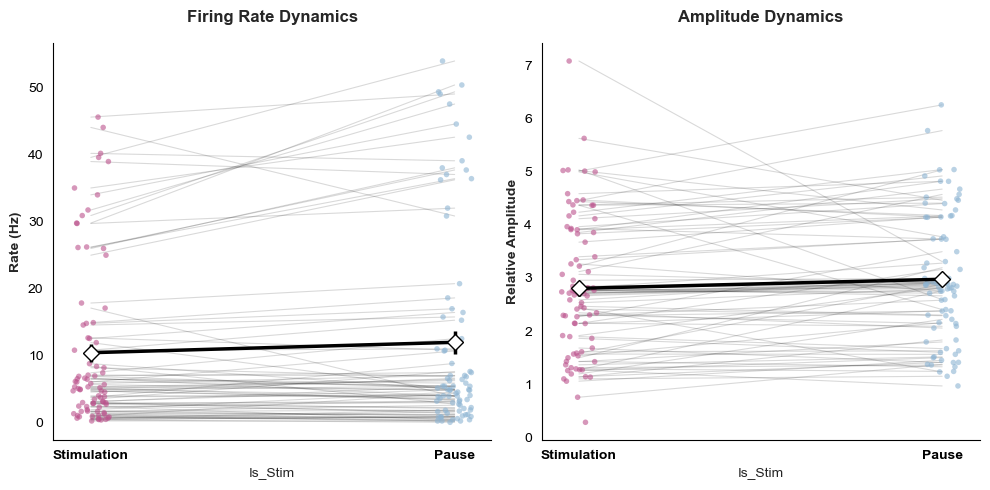

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_paired_dynamics(df_rate, df_amp):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5), sharey=False)
    
    # הגדרות עיצוב
    stim_color = '#8db4d3'
    pause_color = '#bb528c'
    line_color = 'black'
    
    for ax, df, title, ylabel in zip([ax1, ax2], 
                                     [df_rate, df_amp], 
                                     ['Firing Rate Dynamics', 'Amplitude Dynamics'],
                                     ['Rate (Hz)', 'Relative Amplitude']):
        
        # 1. יצירת הזוגות: מחברים כל בלוק אי-זוגי (Stim) לבלוק העוקב לו (Pause)
        subjects = df['Subject_ID'].unique()
        
        for sub in subjects:
            sub_data = df[df['Subject_ID'] == sub].sort_values('Block_Idx')
            # רצים על בלוקים אי-זוגיים שיש להם בלוק עוקב
            for b_idx in sub_data['Block_Idx'].unique():
                if b_idx % 2 != 0: # זה בלוק גירוי
                    stim_val = sub_data[sub_data['Block_Idx'] == b_idx]['Value'].values
                    pause_val = sub_data[sub_data['Block_Idx'] == b_idx + 1]['Value'].values
                    
                    if len(stim_val) > 0 and len(pause_val) > 0:
                        # ציור הקו המחבר
                        ax.plot([0, 1], [stim_val[0], pause_val[0]], 
                                color=line_color, alpha=0.15, linewidth=0.8, zorder=1)
        
        # 2. ציור נקודות הממוצע לכל מצב (כדי להדגיש את המגמה)
        # מחשבים ממוצעים לכל הגירויים ולכל ההפסקות
        means = df.groupby('Is_Stim')['Value'].mean()
        sems = df.groupby('Is_Stim')['Value'].sem()
        
        # ציור הנקודות הבודדות (Stripplot) מעל הקווים
        sns.stripplot(data=df, x='Is_Stim', y='Value', ax=ax, 
                      palette=[pause_color, stim_color], order=[1, 0],
                      size=4, alpha=0.6, zorder=2, jitter=0.05)
        
        # הוספת ממוצע קבוצתי בולט
        ax.errorbar([0, 1], [means[1], means[0]], yerr=[sems[1], sems[0]], 
                    fmt='-D', color='black', markerfacecolor='white', 
                    markersize=8, linewidth=2.5, zorder=4)

        # 3. עיצוב צירים
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Stimulation', 'Pause'], fontweight='bold')
        ax.set_title(title, fontweight='bold', pad=15)
        ax.set_ylabel(ylabel, fontweight='bold')
        
        # ניקוי מסגרת
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_color('black')
        ax.spines['bottom'].set_color('black')
        ax.tick_params(axis='both', colors='black')
        ax.grid(False)

    plt.tight_layout()
    plt.show()

# הרצה (נשתמש ב-DataFrames שיצרנו עבור המודלים)
plot_paired_dynamics(df_rate_active, df_amp_active)

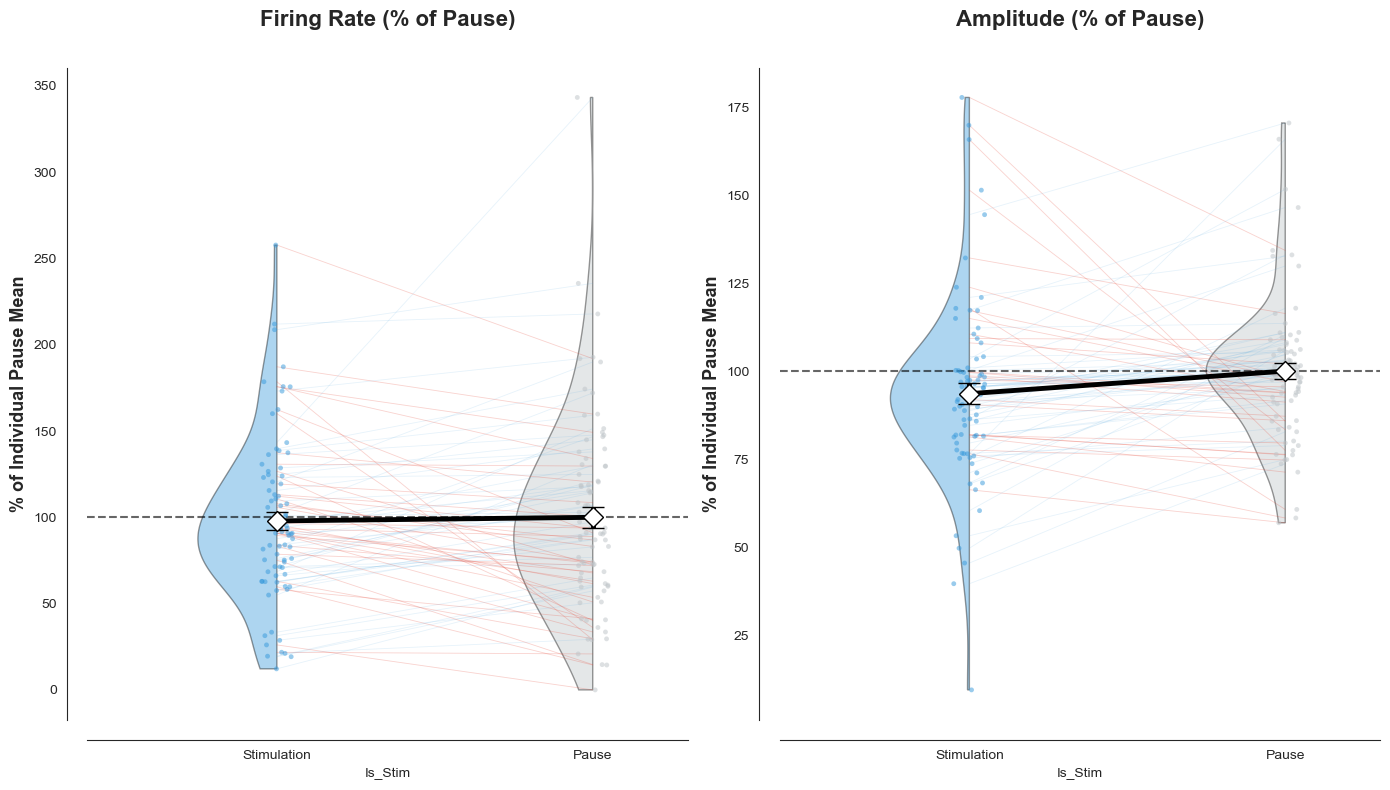

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_percentage_raincloud(df_rate, df_amp):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    
    stim_color = '#3498db'  # כחול לגירוי
    pause_color = '#bdc3c7' # אפור להפסקה
    down_line_color = '#e74c3c'  # אדום בהיר לירידה
    up_line_color = '#5dade2'    # כחול בהיר לעלייה
    
    palette = [stim_color, pause_color]
    order = [1, 0] 
    
    for ax, df, title, ylabel in zip([ax1, ax2], 
                                     [df_rate, df_amp], 
                                     ['Firing Rate (% of Pause)', 'Amplitude (% of Pause)'],
                                     ['% of Individual Pause Mean', '% of Individual Pause Mean']):
        
        # --- 1. נירמול לאחוזים: (Value / Pause_Mean) * 100 ---
        df_norm = df.copy()
        for sub in df_norm['Subject_ID'].unique():
            sub_mask = df_norm['Subject_ID'] == sub
            pause_mean = df_norm.loc[sub_mask & (df_norm['Is_Stim'] == 0), 'Value'].mean()
            
            # מניעת חלוקה ב-0 במקרה של נוירון שקצבו אפס (נדיר אבל חשוב)
            if pause_mean != 0:
                df_norm.loc[sub_mask, 'Perc_Value'] = (df_norm.loc[sub_mask, 'Value'] / pause_mean) * 100
            else:
                df_norm.loc[sub_mask, 'Perc_Value'] = np.nan

        # 2. ציור חצאי כינור (Clouds)
        from scipy.stats import gaussian_kde
        for i, grp_val in enumerate(order):
            grp_data = df_norm[df_norm['Is_Stim'] == grp_val]['Perc_Value'].dropna()
            if len(grp_data) < 2: continue
            
            kde = gaussian_kde(grp_data, bw_method=0.4)
            y_domain = np.linspace(grp_data.min(), grp_data.max(), 500)
            density = (kde(y_domain) / kde(y_domain).max()) * 0.25
            
            x_vals = np.concatenate([np.full_like(y_domain, i), (np.full_like(y_domain[::-1], i) - density[::-1])])
            y_vals = np.concatenate([y_domain, y_domain[::-1]])
            
            poly = plt.Polygon(np.column_stack([x_vals, y_vals]), 
                               facecolor=palette[i], edgecolor='black', alpha=0.4, zorder=0)
            ax.add_patch(poly)

        # 3. ציור נקודות (Rain) - Jitter צר
        sns.stripplot(data=df_norm, x='Is_Stim', y='Perc_Value', ax=ax, 
                      order=order, palette=palette, size=3.5, alpha=0.5, 
                      zorder=1, jitter=0.05)

        # 4. חיבור בלוקים בקווים מותנים
        subjects = df_norm['Subject_ID'].unique()
        for sub in subjects:
            sub_data = df_norm[df_norm['Subject_ID'] == sub].sort_values('Block_Idx')
            for b_idx in sub_data['Block_Idx'].unique():
                if b_idx % 2 != 0: 
                    stim_val = sub_data[sub_data['Block_Idx'] == b_idx]['Perc_Value'].values
                    pause_val = sub_data[sub_data['Block_Idx'] == b_idx + 1]['Perc_Value'].values
                    if len(stim_val) > 0 and len(pause_val) > 0:
                        if pause_val[0] < stim_val[0]: 
                            l_color, l_alpha = down_line_color, 0.25
                        else: 
                            l_color, l_alpha = up_line_color, 0.15
                            
                        ax.plot([0, 1], [stim_val[0], pause_val[0]], 
                                color=l_color, alpha=l_alpha, linewidth=0.6, zorder=0)

        # 5. ממוצע קבוצתי
        g_means = [df_norm[df_norm['Is_Stim'] == 1]['Perc_Value'].mean(), 
                   df_norm[df_norm['Is_Stim'] == 0]['Perc_Value'].mean()]
        g_sems = [df_norm[df_norm['Is_Stim'] == 1]['Perc_Value'].sem(), 
                  df_norm[df_norm['Is_Stim'] == 0]['Perc_Value'].sem()]
        
        ax.errorbar([0, 1], g_means, yerr=g_sems, fmt='-D', color='black', 
                    markerfacecolor='white', markeredgecolor='black',
                    markersize=10, linewidth=3.5, capsize=8, zorder=5)
        
        # קו ה-100% (הבייסליין של ההפסקות)
        ax.axhline(100, color='black', linestyle='--', alpha=0.6, linewidth=1.5, zorder=0)

        # עיצוב
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Stimulation', 'Pause'], fontweight='bold', fontsize=12)
        ax.set_title(title, fontweight='bold', pad=30, fontsize=16)
        ax.set_ylabel(ylabel, fontweight='bold', fontsize=13)
        sns.despine(ax=ax, offset=15)
        ax.set_xlim(-0.6, 1.3)

    plt.tight_layout()
    plt.show()

# הרצה
plot_percentage_raincloud(df_rate_active, df_amp_active)

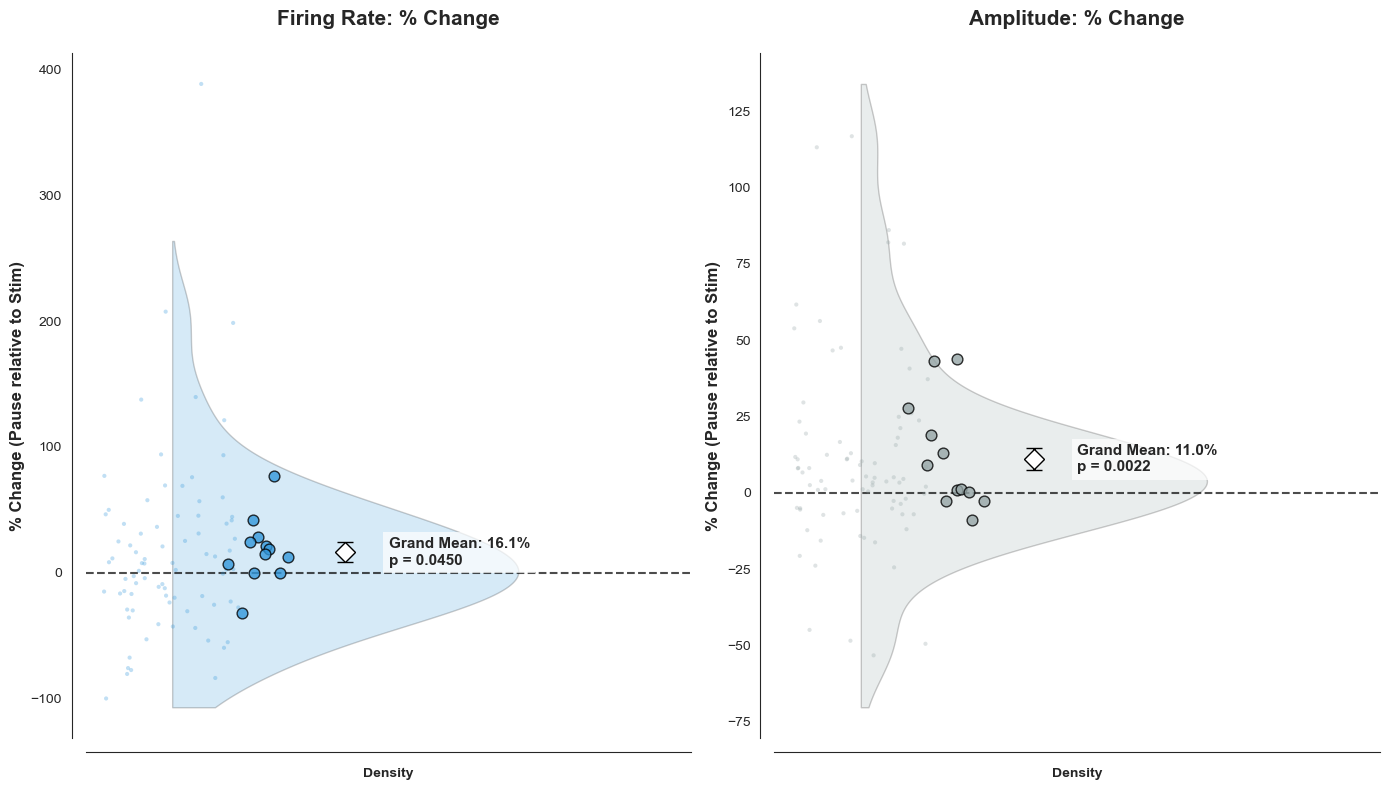

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, ttest_1samp

def plot_percent_change_with_subject_means(df_rate, df_amp):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
    
    rate_color = '#3498db' 
    amp_color = '#95a5a6'  
    
    for ax, df, title in zip([ax1, ax2], 
                             [df_rate, df_amp], 
                             ['Firing Rate: % Change', 'Amplitude: % Change']):
        
        # 1. חישוב אחוזי השינוי ברמת הבלוק
        all_changes = []
        subjects = df['Subject_ID'].unique()
        for sub in subjects:
            sub_data = df[df['Subject_ID'] == sub].sort_values('Block_Idx')
            for b_idx in sub_data['Block_Idx'].unique():
                if b_idx % 2 != 0:
                    stim_val = sub_data[sub_data['Block_Idx'] == b_idx]['Value'].values
                    pause_val = sub_data[sub_data['Block_Idx'] == b_idx + 1]['Value'].values
                    if len(stim_val) > 0 and len(pause_val) > 0 and stim_val[0] > 0:
                        perc_diff = ((pause_val[0] - stim_val[0]) / stim_val[0]) * 100
                        all_changes.append({'Subject_ID': sub, 'Change': perc_diff})
        
        df_change = pd.DataFrame(all_changes).dropna()
        df_change = df_change[np.isfinite(df_change['Change'])]
        
        # 2. חישוב ממוצע לכל נבדק
        subject_means = df_change.groupby('Subject_ID')['Change'].mean()
        
        # 3. מבחן סטטיסטי (על כל הדגימות)
        t_stat, p_val = ttest_1samp(df_change['Change'], 0)
        color = rate_color if 'Rate' in title else amp_color

        # 4. ציור חצי כינור (הענן)
        kde = gaussian_kde(df_change['Change'], bw_method=0.4)
        y_min, y_max = np.percentile(df_change['Change'], [1, 99]) 
        y_domain = np.linspace(y_min - 20, y_max + 20, 500)
        density = (kde(y_domain) / kde(y_domain).max()) * 0.4
        ax.fill_betweenx(y_domain, 0, density, facecolor=color, alpha=0.2, edgecolor='black', zorder=0)

        # 5. ציור כל הדגימות (הגשם הקטן)
        sns.stripplot(y=df_change['Change'], ax=ax, color=color, size=3, alpha=0.3, jitter=0.08, zorder=1)

        # 6. ציור ממוצעי נבדקים (נקודות גדולות ובולטות יותר)
        # נצייר אותן עם jitter קטן במרכז
        ax.scatter(np.random.normal(0.1, 0.02, size=len(subject_means)), subject_means, 
                   color=color, edgecolor='black', s=60, alpha=0.8, zorder=4, label='Subject Means')

        # 7. ממוצע קבוצתי ו-SEM (המעוין הלבן)
        grand_mean = df_change['Change'].mean()
        grand_sem = df_change['Change'].sem()
        ax.errorbar(0.2, grand_mean, yerr=grand_sem, fmt='-D', color='black', 
                    markerfacecolor='white', markersize=10, capsize=6, linewidth=2, zorder=5)
        
        # 8. הוספת טקסט סטטיסטי
        stat_text = f'Grand Mean: {grand_mean:.1f}%\np = {p_val:.4f}'
        if p_val < 0.001: stat_text = f'Grand Mean: {grand_mean:.1f}%\np < 0.001'
        ax.text(0.25, grand_mean, stat_text, fontweight='bold', va='center', fontsize=11, 
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # 9. קו אפס
        ax.axhline(0, color='black', linestyle='--', alpha=0.7, linewidth=1.5, zorder=0)

        # עיצוב
        ax.set_title(title, fontweight='bold', pad=20, fontsize=15)
        ax.set_ylabel('% Change (Pause relative to Stim)', fontweight='bold', fontsize=12)
        ax.set_xlabel('Density', fontweight='bold')
        ax.set_xlim(-0.1, 0.6)
        sns.despine(ax=ax, offset=10)

    plt.tight_layout()
    plt.show()

# הרצה
plot_percent_change_with_subject_means(df_rate_active, df_amp_active)

## Fig 3

Reading 0 ... 21678999  =      0.000 ... 21678.999 secs...
Segment 1 (Start: 3188s):
  - Peak Height: 791.85 µV
  - Peak Height (Z-score): 5.71 SD
------------------------------
Segment 2 (Start: 3832s):
  - Peak Height: 403.78 µV
  - Peak Height (Z-score): 2.91 SD
------------------------------
Segment 3 (Start: 4057s):
  - Peak Height: 624.31 µV
  - Peak Height (Z-score): 4.50 SD
------------------------------
Segment 4 (Start: 4494.3s):
  - Peak Height: 367.59 µV
  - Peak Height (Z-score): 2.65 SD
------------------------------


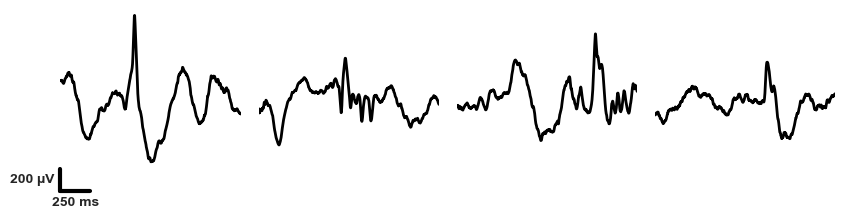

In [164]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# --------------------
# Parameters
# --------------------
subj = '515'
edf_path = rf"D:\Maya\p{subj}\P{subj}_fixed.edf"
channel_name = "RAH2"
duration = 1.5  

# הגדרות ה-Scale Bar החדשות שלך
amp_bar_val = 200     # 200 µV
time_bar_sec = 0.25   # 250 ms = 0.25 sec

start_times = [3188, 3832, 4057, 4494.3]

# --------------------
# Load and Prepare Data
# --------------------
raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
raw.pick([channel_name])
raw.load_data()

original_data_full = raw.get_data()[0] * 1e6
channel_mean = np.mean(original_data_full)
channel_std = np.std(original_data_full)
full_data_z = (original_data_full - channel_mean) / channel_std

segments_z = []
segments_uv = []

for i, t_start in enumerate(start_times):
    sfreq = raw.info['sfreq']
    start_samp = int(t_start * sfreq)
    end_samp = int((t_start + duration) * sfreq)
    
    seg_uv = original_data_full[start_samp:end_samp]
    seg_z = full_data_z[start_samp:end_samp]
    
    segments_uv.append(seg_uv)
    segments_z.append(seg_z)
    
    peak_uv = np.max(seg_uv)
    peak_z = np.max(seg_z)
    
    print(f"Segment {i+1} (Start: {t_start}s):")
    print(f"  - Peak Height: {peak_uv:.2f} µV")
    print(f"  - Peak Height (Z-score): {peak_z:.2f} SD")
    print("-" * 30)

# עכשיו אנחנו מחשבים גבולות לפי יחידות µV לצורך הציור
y_min_global = min([np.min(s) for s in segments_uv])
y_max_global = max([np.max(s) for s in segments_uv])

# --------------------
# Plot (Microvolts Units)
# --------------------
num_segments = len(segments_uv)
fig, axes = plt.subplots(nrows=1, ncols=num_segments, figsize=(2.5 * num_segments, 2.5), sharey=True)

for i, data in enumerate(segments_uv):
    ax = axes[i]
    times = np.linspace(0, duration, len(data))
    ax.plot(times, data, color="black", linewidth=2) 
    
    ax.set_ylim(y_min_global - 50, y_max_global + 50) # מרווח קטן ב-µV
    ax.set_xlim(0, duration)
    ax.set_axis_off()

# --------------------
# Scale Bar (Updated to µV and 250ms)
# --------------------
ax_ref = axes[0] 
vertical_gap = abs(y_max_global - y_min_global) * 0.2 
corner_x = 0 
corner_y = y_min_global - vertical_gap

# ציור הברים
ax_ref.plot([corner_x, corner_x], [corner_y, corner_y + amp_bar_val], 
            color="black", linewidth=3, clip_on=False, zorder=5)
ax_ref.plot([corner_x, corner_x + time_bar_sec], [corner_y, corner_y], 
            color="black", linewidth=3, clip_on=False, zorder=5)

# כיתובים מעודכנים
ax_ref.text(corner_x - 0.05, corner_y + (amp_bar_val / 2), f"{amp_bar_val} µV", 
            va="center", ha="right", fontsize=10, fontweight='bold')
ax_ref.text(corner_x + (time_bar_sec / 2), corner_y - (vertical_gap * 0.2), 
            "250 ms", va="top", ha="center", fontsize=10, fontweight='bold')

plt.subplots_adjust(bottom=0.25, wspace=0.1) 
plt.savefig("raw_examples_515_updated.pdf", bbox_inches='tight')  # שמירה ל-PDF עם הגדרות החדשות
plt.show()

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 7, 7]


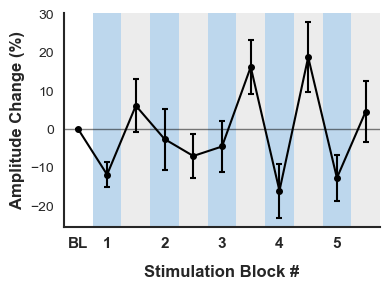

In [95]:


# --- עיבוד נתונים ---
data_list = data_stim['relative_spike_amplitude']['all']
df_cum = get_clean_matrix(data_list, mode='baseline', max_points=11, threshold=1000)   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive', max_points=11, threshold=1000) # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#91bde1' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.6, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
# ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
#             label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)


# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

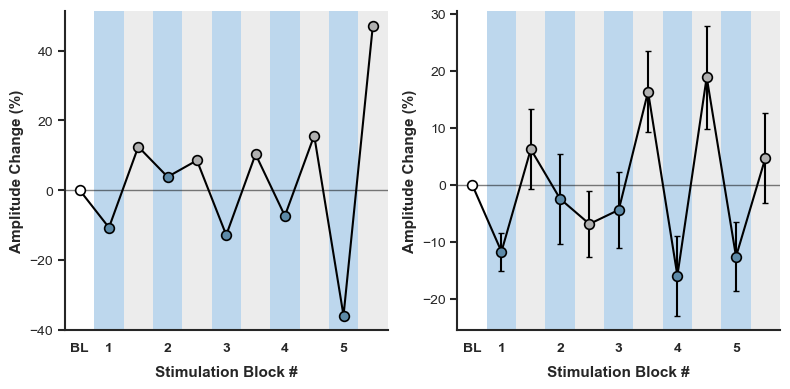

In [110]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- 1. הכנת נתונים ---
# א. נתוני כל הקבוצה (כפי שחושבו קודם)
# mean_imm, sem_imm

# ב. נתוני נבדק 7 (Subject 499)
raw_sub7 = data_stim['relative_spike_amplitude']['all'][7]
pct_sub7 = [0]
for i in range(1, len(raw_sub7)):
    prev = raw_sub7[i-1]
    curr = raw_sub7[i]
    pct_sub7.append(((curr - prev) / prev) * 100 if prev != 0 else 0)

# --- 2. הגדרות עיצוב משותפות ---
stim_bg = '#91bde1'
stim_marker = '#5d8aa8'
pause_bg = '#e0e0e0'
pause_marker = '#b0b0b0'

def style_ax(ax, title):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', direction='out', length=5, width=1.5, left=True)
    # ax.set_title(title, fontsize=12, fontweight='bold', pad=15)
    ax.set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Stimulation Block #', fontsize=11, fontweight='bold', labelpad=8)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# --- 3. יצירת הגרף המאוחד ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), sharey=False)

for ax, data, errors, title in zip([ax1, ax2], 
                                   [pct_sub7, mean_imm], 
                                   [None, sem_imm], 
                                   ['Representative Subject', 'Group Average']):
    
    x_idx = np.arange(len(data))
    
    # רקע וצבעי מרקרים
    marker_colors = [pause_marker]
    for j in range(1, len(data)):
        if j % 2 != 0:
            ax.axvspan(j - 0.5, j + 0.5, color=stim_bg, alpha=0.6, linewidth=0)
            marker_colors.append(stim_marker)
        else:
            ax.axvspan(j - 0.5, j + 0.5, color=pause_bg, alpha=0.6, linewidth=0)
            marker_colors.append(pause_marker)
            
    # קו זיגזג
    ax.plot(x_idx, data, color='black', linewidth=1.5, zorder=3)
    
    # Errorbars (רק לגרף הממוצע)
    if errors is not None:
        ax.errorbar(x_idx, data, yerr=errors, fmt='none', color='black', 
                    linewidth=1.5, elinewidth=1.5, capsize=2, zorder=4)
        
    # נקודות (Opaque)
    for i in range(len(x_idx)):
        # BL לבן כפי שביקשת בקוד האחרון
        f_color = 'white' if i == 0 else marker_colors[i]
        ax.plot(x_idx[i], data[i], marker='o', markersize=7, 
                markerfacecolor=f_color, markeredgecolor='black', 
                markeredgewidth=1.2, zorder=10)
    
    # עיצוב צירים
    style_ax(ax, title)
    stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(data), 2)]
    ax.set_xticks([0] + [i for i in range(1, len(data), 2)])
    ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
    ax.set_xlim(-0.5, len(data) - 0.5)

plt.tight_layout()
plt.savefig('zigzag_499_and_group.pdf', dpi=300)
plt.show()

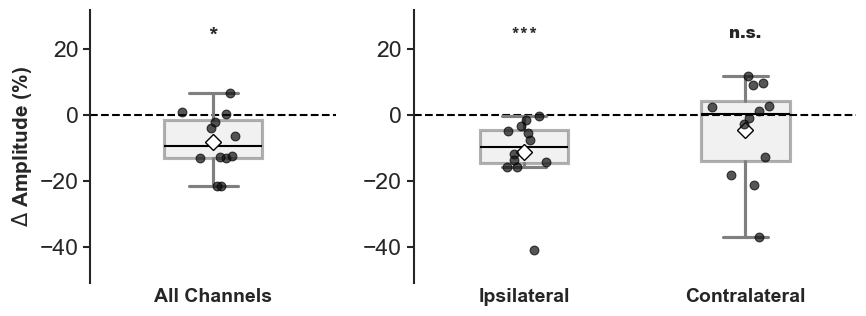

In [124]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
target_param = "relative_spike_amplitude"

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים
# ----------------------------------------------------
all_data_lat, all_data_all = [], []
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        all_data_lat.append(df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean())
        all_data_all.append(df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean())

df_plot_lat = compute_pct_change_pause_vs_stim(pd.concat(all_data_lat), ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(pd.concat(all_data_all), ["subject_id"], [target_param])

# ----------------------------------------------------
# 2. ויזואליזציה
# ----------------------------------------------------
sns.set(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), gridspec_kw={'width_ratios': [1, 1.8]})

min_y = min(df_plot_all["Percent_Change"].min(), df_plot_lat["Percent_Change"].min()) - 10
max_y = max(df_plot_all["Percent_Change"].max(), df_plot_lat["Percent_Change"].max()) + 20

# הגדרות בוקספלוט משותפות
box_style = dict(width=0.4, color="lightgray", showmeans=True, showfliers=False, zorder=2,
                 meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
                 boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5))

# --- גרף שמאל ---
vals_all = df_plot_all["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)
sns.boxplot(y=vals_all, ax=ax1, **box_style)
ax1.scatter(np.random.default_rng(6).normal(0, 0.05, size=len(vals_all)), vals_all, s=40, c="#100f0d", alpha=0.7, edgecolors="black", zorder=3, linewidths=0.8)

_, p_all = wilcoxon(vals_all)
ax1.text(0, max_y - 5, f"{p_to_stars(p_all)}", ha="center", va="top", fontsize=15, fontweight='heavy')
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')

# --- גרף ימין ---
df_plot_final = df_plot_lat.copy()
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)
sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=["ipsi", "contra"], ax=ax2, **box_style)

for i, grp in enumerate(["ipsi", "contra"]):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    ax2.scatter(np.random.default_rng(5+i).normal(i, 0.06, size=len(vals)), vals, s=40, c="#100f0d", alpha=0.7, edgecolors="black", zorder=3, linewidths=0.8)
    _, p_v = wilcoxon(vals)
    ax2.text(i, max_y - 5, f"{p_to_stars(p_v)}", ha="center", va="top", fontsize=12, fontweight='heavy')

ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב צירים וסימוני TICKS ---
for ax_obj in [ax1, ax2]:
    ax_obj.set_ylim(min_y, max_y)
    ax_obj.set_xlabel(""); ax_obj.set_ylabel("")
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)
    
    # הוספת סימוני ה-Ticks הקטנים (שנתות)
    ax_obj.tick_params(axis='y', which='major', direction='out', length=5, width=1.5, left=True)
    ax_obj.tick_params(axis='x', which='major', length=0) # בלי שנתות ב-X כי יש בוקספלוט

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_boxplot+ipsi_contra.pdf', dpi=300)
plt.show()

## old

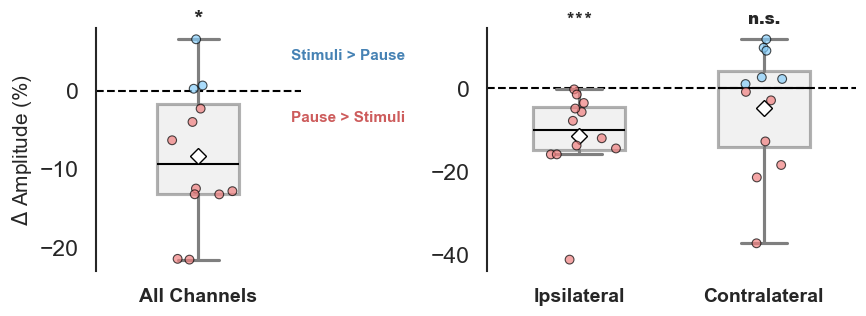

In [112]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

base_path = r"D:\Ofer_backup\V6_model"
target_param = "relative_spike_amplitude"

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    
    # וידוא שאין כפילויות לפני הפיבוט
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
        
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים (כולל תיקון NREM והסרת כפילויות)
# ----------------------------------------------------
all_data_lat = [] # עבור הגרף הימני (Ipsi/Contra)
all_data_all = [] # עבור הגרף השמאלי (All Channels - משוקלל נכון)
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    
    # חובה: סינון NREM והסרת כפילויות כדי לשמור על עקביות
    # df = df[df["hypnogram_flag"] == "nrem"].copy() 
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    
    # סינון לערוצים רלוונטיים (R/L)
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        # 1. חישוב עבור הגרף המפוצל (הממוצע נשמר לפי lat_group)
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        subj_avg_lat = df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean()
        all_data_lat.append(subj_avg_lat)
        
        # 2. חישוב עבור הגרף המאוחד (מתעלמים מהצד, כל הערוצים מקבלים משקל שווה בממוצע)
        subj_avg_all = df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean()
        all_data_all.append(subj_avg_all)

# איחוד הנתונים בנפרד
data_lat_combined = pd.concat(all_data_lat, ignore_index=True)
data_all_combined = pd.concat(all_data_all, ignore_index=True)

# חישוב אחוז השינוי על אובייקטים נפרדים
df_plot_lat = compute_pct_change_pause_vs_stim(data_lat_combined, ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(data_all_combined, ["subject_id"], [target_param])
# ----------------------------------------------------
# ויזואליזציה מאוחדת: לייבלים נקיים וסטטיסטיקה מיושרת
# ----------------------------------------------------
sns.set(style="white", context="talk")

# יצירת Figure עם צירים עצמאיים
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5), sharey=False, gridspec_kw={'width_ratios': [1, 1.8]})

# --- גרף שמאל: All Channels ---
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
ax1.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(y=vals_all, width=0.4, color="lightgray", showmeans=True, ax=ax1,
            meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

rng1 = np.random.default_rng(3)
xj1 = rng1.normal(loc=0.0, scale=0.05, size=len(vals_all))
ax1.scatter(xj1, vals_all, s=40, c=np.where(vals_all > 0, "lightskyblue", "lightcoral"), 
            edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)

# סטטיסטיקה (ax1)
_, p_all = wilcoxon(vals_all)
y_max_all = vals_all.max()
ax1.text(0, y_max_all + abs(y_max_all)*0.2, f"{p_to_stars(p_all)}", ha="center", va="bottom", fontsize=15, fontweight='heavy')

# לייבלים וכיתובים כיווניים (רק בגרף השמאלי)
ax1.set_xticks([0])
ax1.set_xticklabels(["All Channels"], fontsize=14, fontweight='bold')
curr_ylim1 = ax1.get_ylim()
ax1.text(0.45, 4, "Stimuli > Pause", color="steelblue", fontsize=11, fontweight='bold', ha='left')
ax1.text(0.45, -4, "Pause > Stimuli", color="indianred", fontsize=11, fontweight='bold', ha='left')

# --- גרף ימין: By Laterality (Ipsi/Contra) ---
df_plot_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
lat_order = ["ipsi", "contra"]
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5, zorder=1)

sns.boxplot(data=df_plot_final, x="lat_group", y="Percent_Change", order=lat_order, width=0.5, color="lightgray", 
            showmeans=True, ax=ax2, meanprops={"marker":"D", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":8},
            boxprops=dict(alpha=0.3, edgecolor="black"), medianprops=dict(color="black", linewidth=1.5), 
            showfliers=False, zorder=2)

# חישוב גובה אחיד לכוכביות בגרף הימני
y_max_lat = df_plot_final[df_plot_final["lat_group"].isin(lat_order)]["Percent_Change"].max()
star_y_lat = y_max_lat + abs(y_max_lat)*0.25


for i, grp in enumerate(lat_order):
    vals = df_plot_final[df_plot_final["lat_group"] == grp]["Percent_Change"].dropna().values
    rng2 = np.random.default_rng(3 + i)
    xj2 = rng2.normal(loc=i, scale=0.06, size=len(vals))
    ax2.scatter(xj2, vals, s=40, c=np.where(vals > 0, "lightskyblue", "lightcoral"), 
                edgecolors="black", linewidths=0.8, alpha=0.7, zorder=3)
    
    _, p_v = wilcoxon(vals)
    # שימוש ב-star_y_lat האחיד לשני הבוקסים
    ax2.text(i, star_y_lat, f"{p_to_stars(p_v)}", ha="center", va="bottom", fontsize=12, fontweight='heavy')

ax2.set_xlabel("")
ax2.set_xticklabels(["Ipsilateral", "Contralateral"], fontsize=14, fontweight='bold')

# --- עיצוב סופי ---
for ax_obj in [ax1, ax2]:
    for spine in ['top', 'right', 'bottom']: ax_obj.spines[spine].set_visible(False)
    ax_obj.spines['left'].set_linewidth(1.5)

ax1.set_ylabel("$\Delta$ Amplitude (%)", fontsize=15)
ax2.set_ylabel("")

plt.tight_layout()

plt.show()


   STATISTICAL ANALYSIS RESULTS
1. All Channels (vs 0):      p = 0.01611 (*)
2. Ipsilateral (vs 0):       p = 0.00049 (***)
3. Contralateral (vs 0):     p = 0.51855 (n.s.)
4. Comparison (Ipsi vs Contra): p = 0.20361 (n.s.)


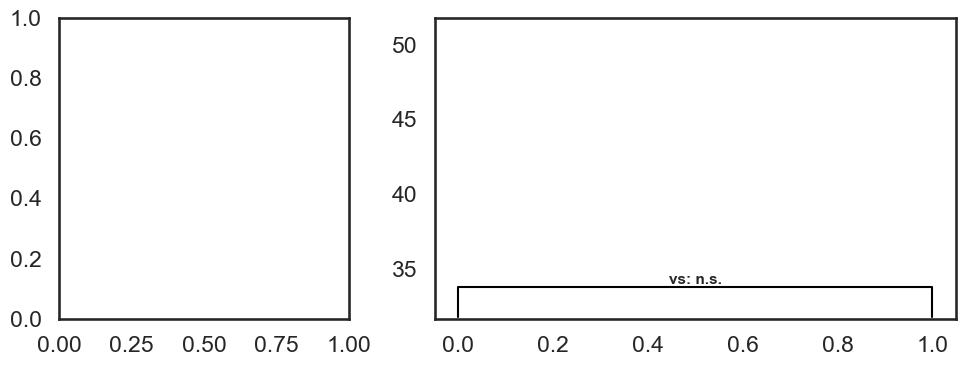

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import utils

def p_to_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "n.s."

def compute_pct_change_pause_vs_stim(data, index_cols, feats):
    cond_order = ["pause_block", "stimuli_block"]
    data_ps = data[data["stimuli_flag"].isin(cond_order)].copy()
    
    # וידוא שאין כפילויות לפני הפיבוט
    data_ps = data_ps.groupby(index_cols + ["stimuli_flag"])[feats].mean().reset_index()
    
    df_pivot = data_ps.pivot(index=index_cols, columns="stimuli_flag", values=feats)
    pct_change_df = pd.DataFrame(index=df_pivot.index)
    
    for feat in feats:
        val_pause = df_pivot[(feat, "pause_block")]
        val_stim  = df_pivot[(feat, "stimuli_block")]
        ok = val_pause.notna() & (val_pause != 0) & val_stim.notna()
        pct_change_df.loc[ok, feat] = ((val_stim[ok] - val_pause[ok]) / val_pause[ok]) * 100
        
    return pct_change_df.melt(var_name="Parameter", value_name="Percent_Change", ignore_index=False).reset_index()

# ----------------------------------------------------
# 1. עיבוד נתונים (כולל תיקון NREM והסרת כפילויות)
# ----------------------------------------------------
all_data_lat = [] # עבור הגרף הימני (Ipsi/Contra)
all_data_all = [] # עבור הגרף השמאלי (All Channels - משוקלל נכון)
subject_ids_to_run = [x for x in subjects if x not in ['5101','541', '544']]

for subj in subject_ids_to_run:
    feat_path = os.path.join(base_path, f"p{subj}", "unichannel_model", "min_amplitude_1", "features", f"p{subj}_flat_features.csv")
    if not os.path.exists(feat_path): continue
    
    df = pd.read_csv(feat_path)
    
    # חובה: סינון NREM והסרת כפילויות כדי לשמור על עקביות
    # df = df[df["hypnogram_flag"] == "nrem"].copy() 
    df = df.drop_duplicates(subset="group", keep="first")
    
    ann_path = fr"D:\Maya\clean Stim Project\P{subj}\P{subj}_annotations_ms.csv"
    try:
        df = utils.remove_noisy_samples_and_channels(subj, df, ann_path, ts_col="timestamp", channel_col="channel")
    except: continue
    
    df["subject_id"] = subj
    stim = stim_side.get(str(subj))
    df["chan_side"] = df["channel"].astype(str).str[0]
    
    # סינון לערוצים רלוונטיים (R/L)
    df_lat = df[df["chan_side"].isin(["R", "L"])].copy()
    
    if stim:
        # 1. חישוב עבור הגרף המפוצל (הממוצע נשמר לפי lat_group)
        df_lat["lat_group"] = np.where(df_lat["chan_side"] == stim, "ipsi", "contra")
        subj_avg_lat = df_lat.groupby(["subject_id", "stimuli_flag", "lat_group"], as_index=False)[[target_param]].mean()
        all_data_lat.append(subj_avg_lat)
        
        # 2. חישוב עבור הגרף המאוחד (מתעלמים מהצד, כל הערוצים מקבלים משקל שווה בממוצע)
        subj_avg_all = df_lat.groupby(["subject_id", "stimuli_flag"], as_index=False)[[target_param]].mean()
        all_data_all.append(subj_avg_all)

# איחוד הנתונים בנפרד
data_lat_combined = pd.concat(all_data_lat, ignore_index=True)
data_all_combined = pd.concat(all_data_all, ignore_index=True)
# --- 1. המשך ישיר אחרי חישוב אחוזי השינוי ---
df_plot_lat = compute_pct_change_pause_vs_stim(data_lat_combined, ["subject_id", "lat_group"], [target_param])
df_plot_all = compute_pct_change_pause_vs_stim(data_all_combined, ["subject_id"], [target_param])

# --- 2. חישוב והדפסת סטטיסטיקה (לפני הציור) ---
print("\n" + "="*30)
print("   STATISTICAL ANALYSIS RESULTS")
print("="*30)

# בדיקת All Channels (האם שונה מ-0)
vals_all = df_plot_all[df_plot_all["Parameter"] == target_param]["Percent_Change"].dropna()
stat_all, p_all = wilcoxon(vals_all)
print(f"1. All Channels (vs 0):      p = {p_all:.5f} ({p_to_stars(p_all)})")

# הכנת נתונים להשוואת צדדים (חשוב למיין לפי subject_id כדי שהזיווג יהיה נכון)
df_lat_final = df_plot_lat[df_plot_lat["Parameter"] == target_param].copy()
ipsi_data = df_lat_final[df_lat_final["lat_group"] == "ipsi"].set_index("subject_id")["Percent_Change"].sort_index()
contra_data = df_lat_final[df_lat_final["lat_group"] == "contra"].set_index("subject_id")["Percent_Change"].sort_index()

# שומרים רק נבדקים שקיימים בשני הצדדים לצורך המבחן המזווג
common_subs = ipsi_data.index.intersection(contra_data.index)
v_ipsi = ipsi_data.loc[common_subs]
v_contra = contra_data.loc[common_subs]

# מבחני Wilcoxon
stat_ipsi, p_ipsi = wilcoxon(v_ipsi)
stat_contra, p_contra = wilcoxon(v_contra)
stat_comp, p_comp = wilcoxon(v_ipsi, v_contra) # השוואה בין הצדדים

print(f"2. Ipsilateral (vs 0):       p = {p_ipsi:.5f} ({p_to_stars(p_ipsi)})")
print(f"3. Contralateral (vs 0):     p = {p_contra:.5f} ({p_to_stars(p_contra)})")
print(f"4. Comparison (Ipsi vs Contra): p = {p_comp:.5f} ({p_to_stars(p_comp)})")
print("="*30)

# --- 3. ויזואליזציה (עם תוספת קו ההשוואה) ---
sns.set(style="white", context="talk")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={'width_ratios': [1, 1.8]})

# [כאן נכנס קוד הציור המקורי שלך עבור ax1 ו-ax2...]
# (דילגתי על הקוד הקיים שלך כדי לקצר, פשוט תשאיר אותו כמו שהוא)

# --- הוספת שכבת הסטטיסטיקה מעל ax2 (בסוף הלופ של ה-scatter) ---
# נשתמש ב-y_max_lat שכבר חישבת במקור
star_y_lat = df_lat_final["Percent_Change"].max() + 5 

# קו השוואה בין Ipsi ל-Contra
y_compare = star_y_lat + 15
ax2.plot([0, 0, 1, 1], [y_compare, y_compare+2, y_compare+2, y_compare], lw=1.5, c='black')
ax2.text(0.5, y_compare+2, f"vs: {p_to_stars(p_comp)}", ha="center", va="bottom", fontsize=11, fontweight='bold')

# וידוא שגבול הציר מספיק גבוה לכל הכוכביות
ax2.set_ylim(ax2.get_ylim()[0], y_compare + 20)

plt.tight_layout()
plt.show()

# time-related analysis

In [7]:
import pandas as pd
import numpy as np

summary_data = []

# Process all subjects in your run
for subj in curr_run_subjects:
    # 1. Get Epochs
    if is_control:
        _, _, stim_epochs = utils.get_nrem_epochs(utils.control_stim[subj])
    else:
        _, _, stim_epochs = utils.get_nrem_epochs(subj)
    
    # 2. Number of stimulation sessions
    num_sessions = len(stim_epochs)
    
    # 3. Total time: (Last End + 5 min) - First Start
    first_stim_start = stim_epochs[0][0]
    last_stim_end = stim_epochs[-1][1]
    total_time_min = ((last_stim_end - first_stim_start) + (5 * 60)) / 60
    avg_session_time = total_time_min / num_sessions 

    # 4. Baseline (Handle the excluded subjects)
    # If the subject was 515 or 545, we don't have a 'natural' baseline recorded in your 'baselines' list
    # We can flag it as NaN so it doesn't break the Mean/Std calculations
    if subj in ['515', '545']:
        subj_baseline = np.nan
    else:
        # We need to find the index in the original 'valid_subjects' list to match 'baselines'
        valid_subs = [x for x in curr_run_subjects if x not in ['515', '545']]
        if subj in valid_subs:
            idx = valid_subs.index(subj)
            subj_baseline = baselines[idx]
        else:
            subj_baseline = np.nan

    summary_data.append({
        'Subject': subj,
        'Baseline_Min': subj_baseline,
        'Num_Sessions': num_sessions,
        'Total_Stim_to_After_Min': total_time_min,
        'Avg_Session_Time_Min': avg_session_time
    })

df_summary = pd.DataFrame(summary_data)

# Calculate stats - .mean() and .std() automatically ignore NaN values
stats = df_summary[['Baseline_Min', 'Num_Sessions', 'Total_Stim_to_After_Min', 'Avg_Session_Time_Min']].agg(['min', 'max', 'mean', 'std']).T

print("--- Per Patient Information (Including 515/545) ---")
print(df_summary)
print("\n--- Aggregate Statistics ---")
print(stats)

--- Per Patient Information (Including 515/545) ---
   Subject  Baseline_Min  Num_Sessions  Total_Stim_to_After_Min  \
0      485     52.176783             4                52.229033   
1      486     43.615217             4                72.061550   
2      487     14.987617             6               114.767500   
3      488     77.243933             7                91.789450   
4      497     16.927700            15               186.056650   
5      498     35.634867            12               134.968867   
6      499      5.871083             8                89.187333   
7      505    106.095467             5                50.051517   
8     5107    119.586633             5                50.146767   
9      515           NaN             6               102.752067   
10     520      9.072658             4                39.901842   
11     545           NaN             5                51.027383   

    Avg_Session_Time_Min  
0              13.057258  
1              18.0153

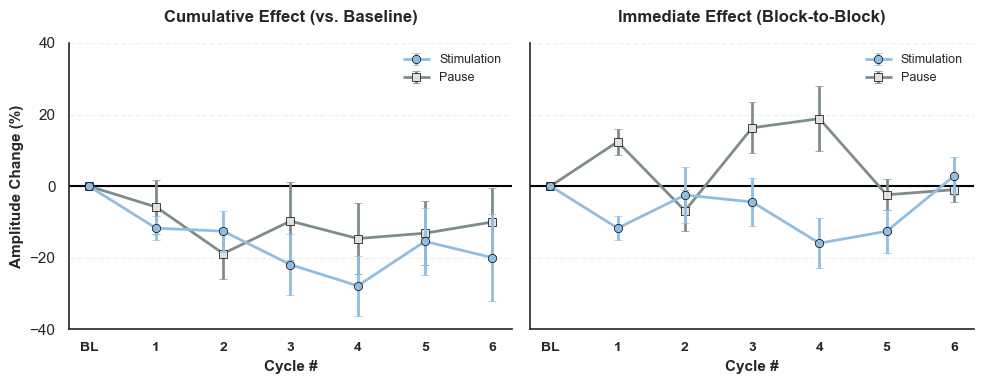

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# --- עיבוד נתונים ---
# (בהנחה ש-mean_cum, mean_imm וכו' כבר קיימים מהשלב הקודם)

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# --- פונקציית עזר לבניית מערך שמתחיל ב-0 ---
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#91bde1'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum, sem_cum), (mean_imm, sem_imm)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה (מוודאים שאם יש פחות הפסקה מגירוי, המערכים יתאימו)
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y
    ax.set_yticks(np.arange(-40, 50, 20))
    ax.set_ylim(-40, 40)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Amplitude Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Change in Amplitude Between Consecutive Time Windows (%)
Inter-Window Amplitude Change (%)
Relative Amplitude Change (% from Previous Block)
Amplitude Modulation (% Change)
Amplitude Change Following State Transition (%)
Consecutive Block-to-Block Change (%)

In [83]:
import os
import numpy as np
import pandas as pd
import mne
import utils

# הגדרות בסיס
base_path = r"D:\Ofer_backup\V6_model"
PRE_MS, POST_MS = 200, 200
cases = [
    {"subj": "497", "chan": "LEC1"},
    {"subj": "497", "chan": "LA1"}
]

all_results = {} # כאן יישמרו כל הנתונים המוכנים

for case in cases:
    subj_id, ch_name = case["subj"], case["chan"]
    print(f"Processing Subj {subj_id}...")
    
    # טעינת נתיבים
    edf_path = rf"D:\Maya\p{subj_id}\P{subj_id}_fixed.edf"
    features_csv = os.path.join(base_path, f"p{subj_id}", "unichannel_model", "min_amplitude_1", "features", f"p{subj_id}_flat_features.csv")
    clean_annot_path = rf"D:\Maya\clean Stim Project\P{subj_id}\P{subj_id}_annotations_ms.csv"

    # עיבוד DataFrame
    df = pd.read_csv(features_csv)
    # df = df[df["hypnogram_flag"] == "nrem"].copy()
    df = df.drop_duplicates(subset=["group"], keep="first")
    df = utils.remove_noisy_samples_and_channels(subj_id, df, clean_annot_path, ts_col="timestamp", channel_col="channel")
    df_target = df[(df["channel"] == ch_name) & (df["stimuli_flag"].isin(["stimuli_block", "pause_block"]))]

    # קריאת EDF
    raw = mne.io.read_raw_edf(edf_path, preload=False, verbose=False)
    fs = raw.info["sfreq"]
    w_len = int((PRE_MS + POST_MS) * fs / 1000)
    
    waveforms = {"stimuli_block": [], "pause_block": []}
    for _, row in df_target.iterrows():
        t_start = (row["timestamp"] - PRE_MS) / 1000
        t_stop = (row["timestamp"] + POST_MS) / 1000
        try:
            wf = raw.get_data(picks=[ch_name], tmin=t_start, tmax=t_stop, return_times=False)
            wf = np.squeeze(wf) * 1e6 # המרה ל-uV
            if len(wf) >= w_len:
                wf_final = wf[:w_len] - np.mean(wf[:int(PRE_MS * fs / 1000)])
                waveforms[row["stimuli_flag"]].append(wf_final)
        except: continue
        
    all_results[f"{subj_id}_{ch_name}"] = {"data": waveforms, "fs": fs}

print("Data is ready for plotting!")

Processing Subj 497...
Processing Subj 497...
Data is ready for plotting!


Case 497_LEC1: Stim Peak=281.90uV, Pause Peak=331.07uV. Difference: 14.9%
Case 497_LA1: Stim Peak=237.73uV, Pause Peak=268.19uV. Difference: 11.4%


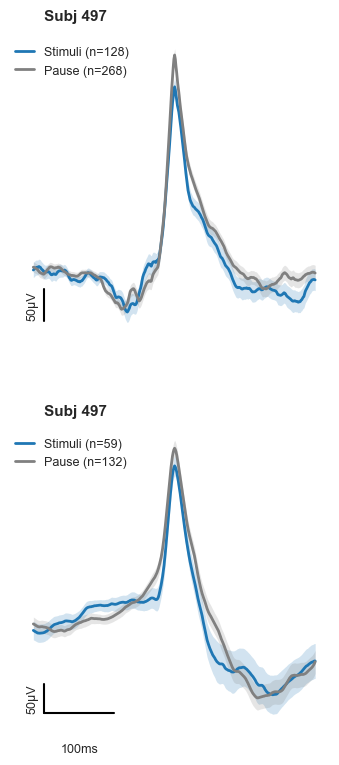

In [87]:
# פרמטרים לציור
SCALE_X = 100        
COLORS = {"stimuli_block": "#1f77b4", "pause_block": "#808080"}
LEGEND_LABELS = {"stimuli_block": "Stimuli", "pause_block": "Pause"}

scale_y_values = [50, 50] 

fig, axes = plt.subplots(2, 1, figsize=(4, 9)) # הגבהתי מעט את הפיגורה ל-9

for i, (key, content) in enumerate(all_results.items()):
    waveforms = content["data"]
    fs = content["fs"]
    ax = axes[i]
    t = np.linspace(-PRE_MS, POST_MS, int((PRE_MS + POST_MS) * fs / 1000))
    current_scale_y = scale_y_values[i]
    
    max_peaks = {} # לאחסון שיאי הגובה
    
    for cond in ["stimuli_block", "pause_block"]:
        wf_list = waveforms[cond]
        if len(wf_list) > 0:
            W = np.vstack(wf_list)
            mean = np.mean(W, axis=0)
            sem = np.std(W, axis=0) / np.sqrt(W.shape[0])
            
            # שמירת שיא הגובה (אבסולוטי) של הממוצע
            max_peaks[cond] = np.max(np.abs(mean))
            
            label_with_n = f"{LEGEND_LABELS[cond]} (n={len(wf_list)})"
            ax.plot(t, mean, color=COLORS[cond], lw=2, label=label_with_n)
            ax.fill_between(t, mean - sem, mean + sem, color=COLORS[cond], alpha=0.2, lw=0)

    # --- חישוב הפרש בשיא הגובה (Peak Amplitude) ---
    if "stimuli_block" in max_peaks and "pause_block" in max_peaks:
        p1, p2 = max_peaks["stimuli_block"], max_peaks["pause_block"]
        pct_diff = abs(p1 - p2) / p2 * 100
        print(f"Case {key}: Stim Peak={p1:.2f}uV, Pause Peak={p2:.2f}uV. Difference: {pct_diff:.1f}%")

    ax.set_axis_off()
    
    # כותרת נבדק - הוספתי pad ויזואלי על ידי העלאת ה-y position
    # ושימוש ב-va='bottom' כדי שיהיה רווח מהסיגנל
    y_max_curr = ax.get_ylim()[1]
    ax.text(-185, y_max_curr * 1.05, f"Subj {key.split('_')[0]}", 
            fontsize=11, fontweight='bold', va='bottom')

    # מקרא - הוספת bbox_to_anchor עם קצת יותר רווח מלמעלה
    ax.legend(loc='upper left', frameon=False, fontsize=9, 
              bbox_to_anchor=(-0.05, 1.0), handlelength=1.5)

    # Scale Bar
    y_min_local, y_max_local = ax.get_ylim()
    y_range = y_max_local - y_min_local
    x_start, y_start = -185, y_min_local + (y_range * 0.05)
    
    ax.plot([x_start, x_start], [y_start, y_start + current_scale_y], color='black', lw=1.5)
    ax.text(x_start - 8, y_start + current_scale_y/2, f'{current_scale_y}µV', 
            ha='right', va='center', rotation=90, fontsize=9)
    
    if i == 1:
        ax.plot([x_start, x_start + SCALE_X], [y_start, y_start], color='black', lw=1.5)
        ax.text(x_start + SCALE_X/2, y_start - (y_range * 0.1), 
                f'{SCALE_X}ms', ha='center', va='top', fontsize=9)

# הגדלת המרווח בין הגרפים כדי למנוע צפיפות בין הכותרת של התחתון ל-Scale Bar של העליון
plt.subplots_adjust(hspace=0.3)
plt.show()

# Rates

Data points per block (after outlier removal):
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 9, 9, 10]


C:\Users\user\AppData\Local\Temp\ipykernel_44912\2330815547.py:63: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-o" (-> linestyle='-'). The keyword argument will take precedence.
  ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--',


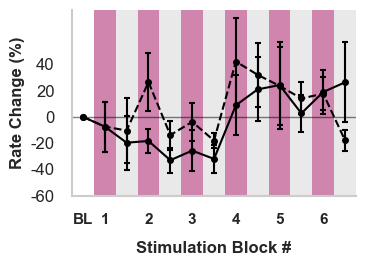

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

def get_clean_matrix(raw_data_list, mode='baseline', max_points=13, threshold=3):
    all_rows = []
    for subj_rates in raw_data_list:
        subj_rates = np.array(subj_rates)[:max_points]
        if len(subj_rates) < 2: continue
        
        if mode == 'baseline':
            b = subj_rates[0]
            if b == 0: continue
            vals = ((subj_rates - b) / b) * 100
        else: # consecutive
            prev = subj_rates[:-1]
            denom = np.where(prev == 0, 1e-9, prev)
            vals = np.insert(((subj_rates[1:] - prev) / denom) * 100, 0, 0)
        
        padded = np.full(max_points, np.nan)
        padded[:len(vals)] = vals
        all_rows.append(padded)
    
    df_wide = pd.DataFrame(all_rows)
    for col in df_wide.columns[1:]:
        q1, q3 = df_wide[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        df_wide.loc[(df_wide[col] < q1 - threshold*iqr) | (df_wide[col] > q3 + threshold*iqr), col] = np.nan
    return df_wide

# --- עיבוד נתונים ---
data_list = data_control['rates']['all']  # רשימת רשימות של כל הנבדקים
df_cum = get_clean_matrix(data_list, mode='baseline')   # Cumulative
df_imm = get_clean_matrix(data_list, mode='consecutive') # Immediate

mean_cum = df_cum.mean()
sem_cum = df_cum.sem()
mean_imm = df_imm.mean()
sem_imm = df_imm.sem()
n_counts = df_cum.count() 
print("Data points per block (after outlier removal):")
print(n_counts.tolist())
x_indices = np.arange(len(mean_cum))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(4, 3))

# 1. רקע צבעוני
for j in range(1, len(mean_cum)):
    color = '#bb528c' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. הגדרות סטייל זהות
err_style = {'fmt': '-o', 'color': 'black', 'capsize': 2, 'markersize': 4, 
             'linewidth': 1.5, 'elinewidth': 1.5, 'capthick': 1.5}

# ציור הקווים
ax.errorbar(x_indices, mean_cum, yerr=sem_cum, zorder=5, 
            label='Cumulative Effect (vs. BL)', **err_style)

ax.errorbar(x_indices, mean_imm, yerr=sem_imm, zorder=4, linestyle='--', 
            label='Immediate Effect (Block-to-Block)', **err_style)

# 3. קו אפס
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)

# 4. עיצוב צירים ו-Ticks (העדכון שביקשת)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# הגדרת שנתות ציר Y כל 10%
y_ticks = np.arange(-60, 50, 20) # מ-40- עד 40 (כולל) בקפיצות של 10
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_ticks, fontsize=12) # הקטנת פונט מספרים בציר Y
# ax.set_ylim(-45, 40)

# תוויות ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_cum), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_cum), 2)])
ax.set_xticklabels(stim_labels, fontsize=11, fontweight='bold')

ax.set_xlabel('Stimulation Block #', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, len(mean_cum) - 0.5)
ax.grid(False)

# 5. מקרא (אופציונלי להחזיר אם תרצה)
stim_patch = mpatches.Patch(color='#8db4d3', label='Stimulation Block')
pause_patch = mpatches.Patch(color='#e0e0e0', label='Pause Block')

plt.tight_layout()
plt.show()

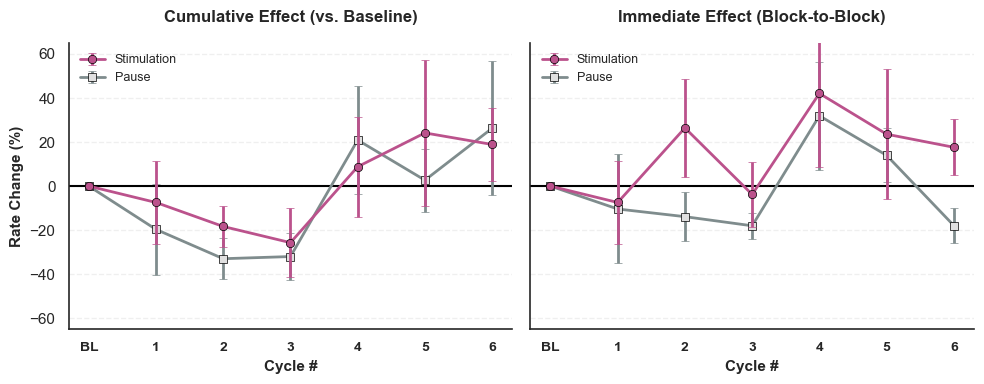

In [80]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד הנתונים עבור קצב הירי (Rates) ---
data_list_rates = data_control['rates']['all']
df_cum_rates = get_clean_matrix(data_list_rates, mode='baseline')
df_imm_rates = get_clean_matrix(data_list_rates, mode='consecutive')

mean_cum_r = df_cum_rates.mean()
sem_cum_r = df_cum_rates.sem()
mean_imm_r = df_imm_rates.mean()
sem_imm_r = df_imm_rates.sem()

# הגדרת אינדקסים (S1=1, P1=2, S2=3, P2=4...)
stim_idx = [i for i in range(1, len(mean_cum_r)) if i % 2 != 0]
pause_idx = [i for i in range(2, len(mean_cum_r)) if i % 2 == 0]

# ציר X המשותף (0 ל-Baseline, ואז 1, 2, 3...)
x_axis = np.arange(len(stim_idx) + 1) 

# פונקציית עזר לבניית מערך שמתחיל ב-0
def prepare_line(mean_series, sem_series, indices):
    y = [0] + mean_series.iloc[indices].tolist()
    err = [0] + sem_series.iloc[indices].tolist()
    return y, err

# --- 2. יצירת הפיגורה ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# הגדרות צבעים וסטייל (כחול לגירוי, אפור להפסקה)
stim_color = '#bb528c'  # הכחול מהרקע המקורי
pause_color = '#e0e0e0' # האפור מהרקע המקורי

stim_style = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
pause_style = {'fmt': '-s', 'color': '#7f8c8d', 'ecolor': '#7f8c8d', 'capsize': 3, 
               'markersize': 6, 'linewidth': 2, 'markerfacecolor': pause_color, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

titles = ['Cumulative Effect (vs. Baseline)', 'Immediate Effect (Block-to-Block)']
datasets = [(mean_cum_r, sem_cum_r), (mean_imm_r, sem_imm_r)]

for i, ax in enumerate(axes):
    m_data, s_data = datasets[i]
    
    # הכנת נתוני הקווים (חיבור נקודת ה-0)
    y_stim, err_stim = prepare_line(m_data, s_data, stim_idx)
    y_pause, err_pause = prepare_line(m_data, s_data, pause_idx)
    
    # ציור קו גירוי
    ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation', zorder=5, **stim_style)
    
    # ציור קו הפסקה
    ax.errorbar(x_axis[:len(y_pause)], y_pause, yerr=err_pause, label='Pause', zorder=4, **pause_style)
    
    # קו אפס שחור ובולט
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)
    
    # עיצוב צירים
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    
    # הגדרות Y (ניתן להתאים את הטווח אם קצב הירי משתנה יותר/פחות מאמפליטודה)
    ax.set_yticks(np.arange(-60, 80, 20))
    ax.set_ylim(-65, 65)
    
    # הגדרות X
    ax.set_xticks(x_axis)
    ax.set_xticklabels(['BL'] + [f'{j}' for j in x_axis[1:]], fontsize=10, fontweight='bold')
    ax.set_xlabel('Cycle #', fontsize=11, fontweight='bold')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=15)
    ax.legend(frameon=False, fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Rate Change (%)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

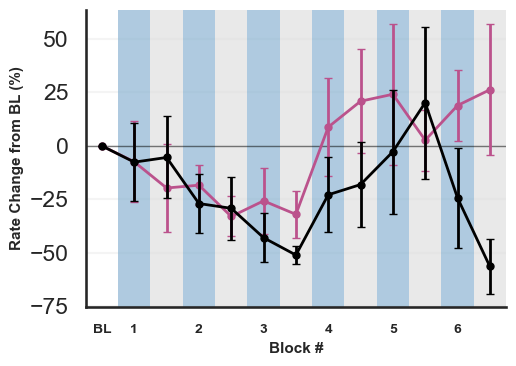

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- עיבוד נתונים (בהנחה שהפונקציה get_clean_matrix הוגדרה קודם) ---
df_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_control = get_clean_matrix(data_control['rates']['all'], mode='baseline')

mean_stim = df_stim.mean()
sem_stim = df_stim.sem()
mean_ctrl = df_control.mean()
sem_ctrl = df_control.sem()

x_indices = np.arange(len(mean_stim))

# --- יצירת הגרף ---
fig, ax = plt.subplots(figsize=(5.5, 4)) # הגדלתי מעט את הרוחב למקרא

# 1. רקע צבעוני לבלוקים
for j in range(1, len(mean_stim)):
    color = '#8db4d3' if j % 2 != 0 else '#e0e0e0'
    ax.axvspan(j - 0.5, j + 0.5, color=color, alpha=0.7, linewidth=0)

# 2. ציור הקווים
# קבוצת הניסוי - כחול עמוק
ax.errorbar(x_indices, mean_stim, yerr=sem_stim, fmt='-o', color='black', 
            capsize=3, markersize=5, linewidth=2, label='Stimulation Group', zorder=5)

# קבוצת הביקורת - ורוד ce84ad
ax.errorbar(x_indices, mean_ctrl, yerr=sem_ctrl, fmt='-o', color='#bb528c', 
            capsize=3, markersize=5, linewidth=2, label='Control Group', zorder=4)

# 3. עיצוב ציר Y
ax.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5, zorder=2)
# הגדרה הגיונית לציר Y בהתאם לדאטה (מ-80- עד 60+)
# ax.set_ylim(-60, 40)
# y_ticks = np.arange(-60, 41, 20)
# ax.set_yticks(y_ticks)
# ax.set_yticklabels(y_ticks, fontsize=10)
ax.set_ylabel('Rate Change from BL (%)', fontsize=11, fontweight='bold')

# 4. עיצוב ציר X
stim_labels = ['BL'] + [str((i//2) + 1) for i in range(1, len(mean_stim), 2)]
ax.set_xticks([0] + [i for i in range(1, len(mean_stim), 2)])
ax.set_xticklabels(stim_labels, fontsize=10, fontweight='bold')
ax.set_xlabel('Block #', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, len(mean_stim) - 0.5)

# 5. ניקוי מסגרת
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)

# 6. מקרא - שמאל למעלה
# ax.legend(frameon=True, fontsize=9, loc='upper left', facecolor='white', framealpha=0.8)
plt.tight_layout()
plt.show()

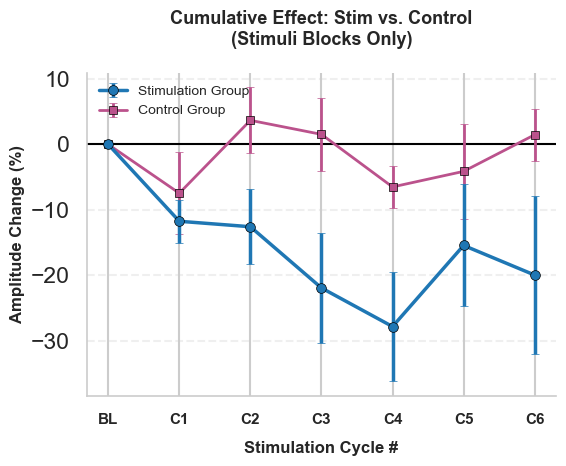

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

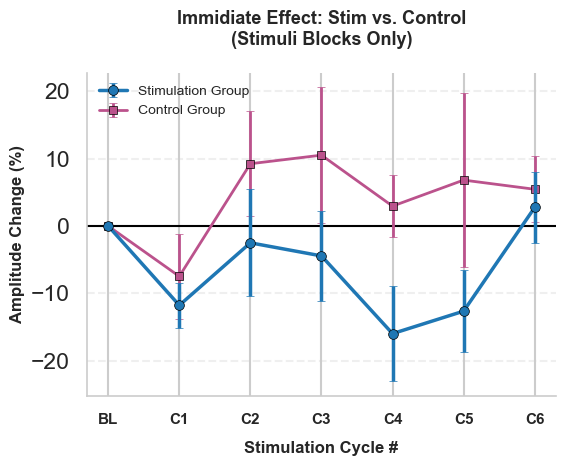

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['relative_spike_amplitude']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['relative_spike_amplitude']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_ylabel('Amplitude Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immidiate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

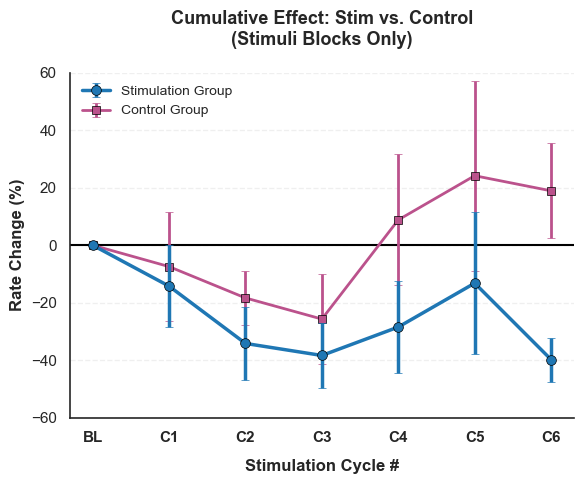

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='baseline')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Cumulative Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

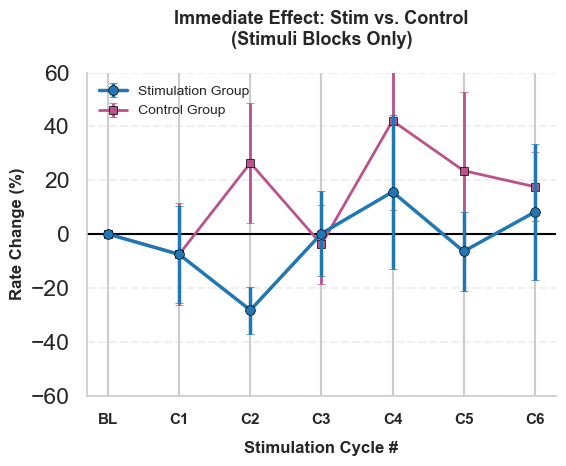

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. עיבוד נתונים עבור קבוצת הגירוי ---
df_cum_stim = get_clean_matrix(data_stim['rates']['all'], mode='consecutive')
mean_stim = df_cum_stim.mean()
sem_stim = df_cum_stim.sem()

# --- 2. עיבוד נתונים עבור קבוצת הקונטרול ---
df_cum_ctrl = get_clean_matrix(data_control['rates']['all'], mode='consecutive')
mean_ctrl = df_cum_ctrl.mean()
sem_ctrl = df_cum_ctrl.sem()

# --- 3. שליפת זמני הגירוי בלבד (אינדקסים 1, 3, 5, 7) ---
stim_idx = [1, 3, 5, 7, 9, 11] # אינדקסים של בלוקי הגירוי בתוך המטריצה

# פונקציה להכנת הקו (הוספת 0 של ה-BL בהתחלה)
def prepare_group_line(mean_s, sem_s, idx_list):
    y = [0] + mean_s.iloc[idx_list].tolist()
    err = [0] + sem_s.iloc[idx_list].tolist()
    return y, err

y_stim, err_stim = prepare_group_line(mean_stim, sem_stim, stim_idx)
y_ctrl, err_ctrl = prepare_group_line(mean_ctrl, sem_ctrl, stim_idx)

# ציר X (BL ואז מחזורים 1 עד 4)
x_axis = np.arange(len(y_stim))

# --- 4. יצירת הגרף ---
fig, ax = plt.subplots(figsize=(6, 5))

# הגדרות סטייל
stim_color = '#1f77b4' # כחול חזק לקבוצת הגירוי
ctrl_color = '#bb528c' # אפור לקבוצת הביקורת

style_stim = {'fmt': '-o', 'color': stim_color, 'ecolor': stim_color, 'capsize': 3, 
              'markersize': 7, 'linewidth': 2.5, 'markeredgecolor': 'black', 'markeredgewidth': 0.5}
style_ctrl = {'fmt': '-s', 'color': ctrl_color, 'ecolor': ctrl_color, 'capsize': 3, 
              'markersize': 6, 'linewidth': 2, 'markerfacecolor': '#bb528c', 'markeredgecolor': 'black', 'markeredgewidth': 0.5}

# ציור הקווים
ax.errorbar(x_axis, y_stim, yerr=err_stim, label='Stimulation Group', zorder=5, **style_stim)
ax.errorbar(x_axis, y_ctrl, yerr=err_ctrl, label='Control Group', zorder=4, **style_ctrl)

# קו אפס שחור
ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5, zorder=1)

# עיצוב צירים
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# הגדרות Y
ax.set_yticks(np.arange(-60, 80, 20))
ax.set_ylim(-60, 60)
ax.set_ylabel('Rate Change (%)', fontsize=12, fontweight='bold')

# הגדרות X
ax.set_xticks(x_axis)
ax.set_xticklabels(['BL', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6'], fontsize=11, fontweight='bold')
ax.set_xlabel('Stimulation Cycle #', fontsize=12, fontweight='bold', labelpad=10)

ax.set_title('Immediate Effect: Stim vs. Control\n(Stimuli Blocks Only)', fontsize=13, fontweight='bold', pad=20)
ax.legend(frameon=False, fontsize=10, loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [98]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# --- 1. הכנת הנתונים (כל בלוקי הגירוי הקיימים) ---
df_stim_raw = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_ctrl_raw = get_clean_matrix(data_control['rates']['all'], mode='baseline')

def prepare_all_stim_blocks(df, group_label):
    # שליפת כל האינדקסים האי-זוגיים הקיימים במטריצה (1, 3, 5, 7, 9...)
    all_indices = [i for i in range(len(df)) if i % 2 != 0]
    
    subset = df.iloc[all_indices].copy()
    long_df = subset.melt(ignore_index=False).reset_index()
    long_df.columns = ['block_id', 'subject_id', 'rate_change']
    long_df['group'] = group_label
    
    # חישוב ה-Cycle לכל אורך הדאטה
    long_df['cycle'] = (long_df['block_id'].astype(int) // 2) + 1
    return long_df

# איחוד הקבוצות - הפעם עם כל הבלוקים
df_model_all = pd.concat([
    prepare_all_stim_blocks(df_stim_raw, 'stimulation'),
    prepare_all_stim_blocks(df_ctrl_raw, 'control')
])

# ניקוי NaNs וסידור אינדקסים
df_model_all = df_model_all.dropna(subset=['rate_change', 'subject_id']).reset_index(drop=True)
df_model_all['subject_id'] = df_model_all['subject_id'].astype(str)

# בדיקה: כמה בלוקים יש לנו עכשיו?
print(f"Total observations in model: {len(df_model_all)}")
print(f"Max cycle reached: {df_model_all['cycle'].max()}")

# --- 2. בניית המודל ההיררכי על כל הדאטה ---
hierarchical_model_all = smf.mixedlm("rate_change ~ group * cycle", 
                                     df_model_all, 
                                     groups=df_model_all["subject_id"])

results_all = hierarchical_model_all.fit()

# --- 3. הדפסת תוצאות ---
print("\n" + "="*60)
print("   HIERARCHICAL MODEL RESULTS (ALL STIM BLOCKS)")
print("="*60)
print(results_all.summary().tables[1])

# בדיקת מובהקות האינטראקציה
p_inter = results_all.pvalues['group[T.stimulation]:cycle']
print("-" * 60)
print(f"Interaction P-value (Group x Cycle): {p_inter:.4f}")
print("="*60)

Total observations in model: 133
Max cycle reached: 6

   HIERARCHICAL MODEL RESULTS (ALL STIM BLOCKS)
                              Coef. Std.Err.       z  P>|z|    [0.025   0.975]
Intercept                    24.357   13.495   1.805  0.071    -2.091   50.806
group[T.stimulation]        -79.413   18.559  -4.279  0.000  -115.788  -43.038
cycle                       -12.924    3.966  -3.259  0.001   -20.696   -5.151
group[T.stimulation]:cycle   15.326    5.250   2.919  0.004     5.035   25.616
Group Var                   118.511    2.954                                  
------------------------------------------------------------
Interaction P-value (Group x Cycle): 0.0035


In [99]:
print(df_model_all['cycle'].value_counts().sort_index())

cycle
1    22
2    26
3    26
4    26
5    24
6     9
Name: count, dtype: int64


In [101]:
import pandas as pd
import statsmodels.formula.api as smf

# --- 1. הכנת הנתונים (צורה בטוחה) ---
df_stim_raw = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
df_ctrl_raw = get_clean_matrix(data_control['rates']['all'], mode='baseline')

def get_blocks_by_type_safe(df, group_label, block_type='stim'):
    # הגדרת אינדקסים לפי סוג הבלוק
    if block_type == 'stim':
        indices = [i for i in range(len(df)) if i % 2 != 0] # 1, 3, 5...
    else:
        indices = [i for i in range(len(df)) if i % 2 == 0 and i > 0] # 2, 4, 6...
    
    # שליפת הנתונים הקיימים בלבד עבור המטריצה הספציפית הזו
    # (מוודא שלא נחרוג מהגבולות של המטריצה הזו)
    valid_indices = [i for i in indices if i < len(df)]
    
    long_df = df.iloc[valid_indices].melt(ignore_index=False).reset_index()
    long_df.columns = ['block_id', 'subject_id', 'change']
    long_df['group'] = group_label
    return long_df.dropna(subset=['change', 'subject_id'])

# --- 2. הרצת המודלים ---

# א. מקטעי גירוי בלבד
df_stim_only = pd.concat([
    get_blocks_by_type_safe(df_stim_raw, 'stimulation', 'stim'),
    get_blocks_by_type_safe(df_ctrl_raw, 'control', 'stim')
])
df_stim_only['subject_id'] = df_stim_only['subject_id'].astype(str)

model_stim = smf.mixedlm("change ~ group", df_stim_only, groups=df_stim_only["subject_id"])
res_stim = model_stim.fit()

# ב. מקטעי הפסקה בלבד
df_pause_only = pd.concat([
    get_blocks_by_type_safe(df_stim_raw, 'stimulation', 'pause'),
    get_blocks_by_type_safe(df_ctrl_raw, 'control', 'pause')
])
df_pause_only['subject_id'] = df_pause_only['subject_id'].astype(str)

model_pause = smf.mixedlm("change ~ group", df_pause_only, groups=df_pause_only["subject_id"])
res_pause = model_pause.fit()

# --- 3. הדפסת תוצאות ---
print("="*60)
print("     HIERARCHICAL COMPARISON: STIMULATION BLOCKS")
print("="*60)
print(res_stim.summary().tables[1])
print(f"\nP-value for Group Difference during STIM: {res_stim.pvalues['group[T.stimulation]']:.4f}")

print("\n\n" + "="*60)
print("     HIERARCHICAL COMPARISON: PAUSE BLOCKS")
print("="*60)
print(res_pause.summary().tables[1])
print(f"\nP-value for Group Difference during PAUSE: {res_pause.pvalues['group[T.stimulation]']:.4f}")

C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\anaconda3\envs\depth_ieds\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2201: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


     HIERARCHICAL COMPARISON: STIMULATION BLOCKS
                        Coef. Std.Err.       z  P>|z|   [0.025   0.975]
Intercept             -14.413    6.464  -2.230  0.026  -27.082   -1.744
group[T.stimulation]  -32.418    8.165  -3.970  0.000  -48.421  -16.415
Group Var             102.975    2.834                                 

P-value for Group Difference during STIM: 0.0001


     HIERARCHICAL COMPARISON: PAUSE BLOCKS
                        Coef. Std.Err.       z  P>|z|   [0.025  0.975]
Intercept              17.457    8.337   2.094  0.036    1.116  33.798
group[T.stimulation]  -11.683   11.087  -1.054  0.292  -33.413  10.048
Group Var               0.442    3.076                                

P-value for Group Difference during PAUSE: 0.2920



--- Statistical Results ---

Phase: ON
  Stim vs 0: p = 0.06543
  Ctrl vs 0: p = 0.53906
  Stim vs Ctrl: p = 0.08099

Phase: OFF
  Stim vs 0: p = 0.09668
  Ctrl vs 0: p = 0.38477
  Stim vs Ctrl: p = 0.09294


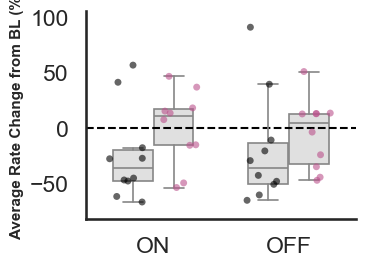

In [38]:

def plot_split_groups_reproducible_safe(data_stim, data_control):
    # 1. ניקוי וסגירת פיגרים קודמים
    plt.close('all')
    fig, ax = plt.subplots(figsize=(4, 3))
    
    # 2. עיבוד נתונים
    df_s = get_clean_matrix(data_stim['rates']['all'], mode='baseline')
    df_c = get_clean_matrix(data_control['rates']['all'], mode='baseline')
    
    def get_split_means(df, group_name):
        stim_blocks = df.iloc[:, 1::2].mean(axis=1)
        pause_blocks = df.iloc[:, 2::2].mean(axis=1)
        return pd.DataFrame({
            'Change': pd.concat([stim_blocks, pause_blocks]),
            'Block_Type': ['ON']*len(stim_blocks) + ['OFF']*len(pause_blocks),
            'Group': group_name
        }).dropna()

    plot_df = pd.concat([get_split_means(df_s, 'Stimulation'), get_split_means(df_c, 'Control')])
    
    group_order = ['Stimulation', 'Control']
    point_pal = {'Stimulation': 'black', 'Control': '#bb528c'}
    box_color = '#e0e0e0'
    
    # 3. יצירת בוקספלוט
    sns.set_style("white")
    sns.boxplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                hue_order=group_order, color=box_color, width=0.6, 
                fliersize=0, zorder=2, linewidth=1.2, ax=ax)
    
    for patch in ax.patches:
        patch.set_facecolor(box_color)

    # 4. פריסת נקודות קבועה - הדרך הבטוחה
    # הגדרת ה-Seed כאן מבטיחה שה-Jitter של stripplot יהיה זהה בכל הרצה
    np.random.seed(4) 
    
    sns.stripplot(data=plot_df, x='Block_Type', y='Change', hue='Group', 
                  hue_order=group_order, dodge=True, palette=point_pal, 
                  alpha=0.6, size=5, jitter=0.25, ax=ax, zorder=3)

    # 5. הדפסת סטטיסטיקה מלאה
    print("\n--- Statistical Results ---")
    for b_type in ['ON', 'OFF']:
        s_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Stimulation')]['Change']
        c_vals = plot_df[(plot_df['Block_Type'] == b_type) & (plot_df['Group'] == 'Control')]['Change']
        print(f"\nPhase: {b_type}")
        if len(s_vals) >= 5:
            res_w = wilcoxon(s_vals, alternative='less')
            print(f"  Stim vs 0: p = {res_w.pvalue:.5f}")
        if len(c_vals) >= 5:
            res_w = wilcoxon(c_vals, alternative='less')
            print(f"  Ctrl vs 0: p = {res_w.pvalue:.5f}")
        if len(s_vals) >= 5 and len(c_vals) >= 5:
            _, p_mw = mannwhitneyu(s_vals, c_vals, alternative='less')
            print(f"  Stim vs Ctrl: p = {p_mw:.5f}")

    # 6. עיצוב סופי
    ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
    ax.set_ylabel('Average Rate Change from BL (%)', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    if ax.get_legend(): ax.get_legend().remove()
    ax.set_ylim(plot_df['Change'].min() - 15, plot_df['Change'].max() + 15)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_split_groups_reproducible_safe(data_stim, data_control)


   NON-PARAMETRIC ONE-TAILED RESULTS
Stimulation vs 0 (Wilcoxon) | p (one-tailed) = 0.01562
Pause vs 0       (Wilcoxon) | p (one-tailed) = 0.21875
Stim < Pause     (Wilcoxon) | p (one-tailed) = 0.34375


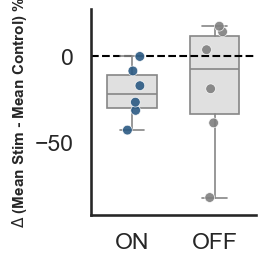

In [40]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים (ממוצע קבוצתי לכל נקודת זמן)
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# 2. פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 3. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed) - הדפסה בלבד
print("\n" + "="*45)
print("   NON-PARAMETRIC ONE-TAILED RESULTS")
print("="*45)

# א. האם הגירוי מוריד את ה-Rate מול 0? (Wilcoxon)
# alternative='less' בודק אם הערכים קטנים מ-0
_, p_stim_0_one = stats.wilcoxon(stim_diffs, alternative='less')

# ב. האם ההפסקה מראה ירידה מובהקת מול 0? (Wilcoxon)
_, p_pause_0_one = stats.wilcoxon(pause_diffs, alternative='less')

# ג. האם האפקט בגירוי חזק (נמוך) יותר מההפסקה? (Wilcoxon Paired)
# משתמשים ב-wilcoxon כי הנקודות מזווגות כרונולוגית
res_comp_one = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Stimulation vs 0 (Wilcoxon) | p (one-tailed) = {p_stim_0_one:.5f}")
print(f"Pause vs 0       (Wilcoxon) | p (one-tailed) = {p_pause_0_one:.5f}")
print(f"Stim < Pause     (Wilcoxon) | p (one-tailed) = {res_comp_one.pvalue:.5f}")

# 4. הכנת נתונים לגרף
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6
})

# 5. ויזואליזציה מעוצבת
plt.close('all')
fig, ax = plt.subplots(figsize=(3, 3))
sns.set_style("white")

group_order = ['ON', 'OFF']
point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} 
box_color = '#e0e0e0' 

# בוקספלוט ניטרלי
sns.boxplot(data=plot_df, x='Type', y='Difference', order=group_order,
            color=box_color, width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax)

# צביעת הבוקסים באפור
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת נקודות (Jitter קטן למרכוז כמו במקור) עם Seed קבוע
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Type', y='Difference', order=group_order,
              dodge=True, palette=point_pal, alpha=0.9, size=7, 
              jitter=0.1, edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 6. עיצוב סופי
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

if ax.get_legend(): ax.get_legend().remove()
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()


   OVERALL EFFECT: ONE-TAILED WILCOXON
Overall Difference vs 0 | p (one-tailed) = 0.01709
ON vs OFF Comparison    | p (one-tailed) = 0.34375


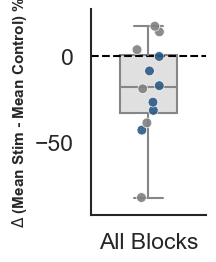

In [41]:
import seaborn as sns
from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. חישוב הממוצעים וההפרשים - העתקה מדויקת של הלוגיקה שעבדה לך
mean_series_stim = df_stim.iloc[:, 1:].mean()
mean_series_ctrl = df_control.iloc[:, 1:].mean()
time_point_diffs = mean_series_stim - mean_series_ctrl

# פיצול ל-6 נקודות גירוי (ON) ו-6 נקודות הפסקה (OFF)
stim_diffs = time_point_diffs.iloc[::2]
pause_diffs = time_point_diffs.iloc[1::2]

# 2. ניתוח סטטיסטי לא-פרמטרי חד-כיווני (One-tailed Wilcoxon)
print("\n" + "="*45)
print("   OVERALL EFFECT: ONE-TAILED WILCOXON")
print("="*45)

# א. האם כל 12 הבלוקים יחד נמוכים מ-0 באופן מובהק?
_, p_overall = stats.wilcoxon(time_point_diffs, alternative='less')

# ב. האם הגירוי (ON) נמוך משמעותית מההפסקה (OFF)? (מבחן מזווג)
_, p_on_off = stats.wilcoxon(stim_diffs, pause_diffs, alternative='less')

print(f"Overall Difference vs 0 | p (one-tailed) = {p_overall:.5f}")
print(f"ON vs OFF Comparison    | p (one-tailed) = {p_on_off:.5f}")

# 3. הכנת נתונים לגרף - שימוש ב-concatenate מבטיח עקביות צבעים
# אנחנו יוצרים רשימה של 6 'ON' ואז 6 'OFF' שמתאימה בדיוק לסדר הערכים
plot_df = pd.DataFrame({
    'Difference': np.concatenate([stim_diffs.values, pause_diffs.values]),
    'Type': ['ON'] * 6 + ['OFF'] * 6,
    'Group': 'All Blocks' # שם קטגוריה אחת לציר ה-X
})

# 4. ויזואליזציה מעוצבת ואחידה
plt.close('all')
fig, ax = plt.subplots(figsize=(2.5, 3)) # פרופורציה צרה וגבוהה
sns.set_style("white")

point_pal = {'ON': '#2b5a83', 'OFF': '#808080'} # כחול ואפור המקוריים
box_color = '#e0e0e0' 

# בוקספלוט יחיד
sns.boxplot(data=plot_df, x='Group', y='Difference', color=box_color, 
            width=0.5, fliersize=0, zorder=2, linewidth=1.5, ax=ax)

# צביעת הבוקס
for patch in ax.patches:
    patch.set_facecolor(box_color)

# הוספת הנקודות - dodge=False גורם לכולן להיות על אותו ציר מרכזי
np.random.seed(4) 
sns.stripplot(data=plot_df, x='Group', y='Difference', hue='Type', 
              hue_order=['ON', 'OFF'], dodge=False, 
              palette=point_pal, alpha=0.9, size=7, jitter=0.1, 
              edgecolor='white', linewidth=0.5, ax=ax, zorder=3)

# 5. עיצוב סופי (עובי צירים 1.5 לאחידות)
ax.axhline(0, color='black', linestyle='--', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$\Delta$ (Mean Stim - Mean Control) %', fontweight='bold', fontsize=11)
ax.set_xlabel('')

# עיבוי צירים (Spines)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_linewidth(1.5)
ax.tick_params(width=1.5)

# הסרת המקרא
if ax.get_legend():
    ax.get_legend().remove()

# הגדרת גבולות ציר Y (מרווח סביר סביב הנתונים)
ax.set_ylim(plot_df['Difference'].min() - 10, plot_df['Difference'].max() + 10)

sns.despine()
plt.tight_layout()
plt.show()

In [44]:
from matplotlib import colors
from nilearn import plotting

# 1. הגדרת צבע כחול עם שקיפות (Alpha = 0.5)
# אפשר לשנות את ה-0.5 לערך נמוך יותר לשקיפות גבוהה יותר
node_color_transparent = colors.to_rgba('tab:blue', alpha=0.8)

# 2. ציור ושמירה כקובץ PDF
plotting.plot_connectome(
    adjacency_matrix=np.zeros((len(coords), len(coords))),
    node_coords=coords,
    node_color=[node_color_transparent] * len(coords), # רשימת צבעים לכל נקודה
    node_size=30,
    display_mode='ortho',
    colorbar=False,           
    output_file='stimulation_areas.pdf' # שמירה כקובץ PDF וקטורי
)

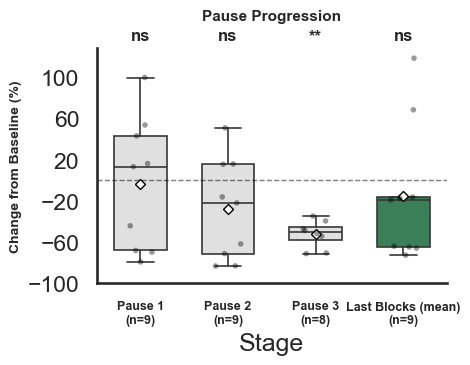

In [13]:


# 2. עיבוד הנתונים למקטעי הפסקה (Pauses)
def prepare_pause_data():
    exclude = ['515', '545']
    all_subjects_processed = []
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
            
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue # חייב לפחות בייסליין והפסקה ראשונה
        
        baseline = subj_rates[0]
        # שליפת ההפסקות: אינדקסים 2, 4, 6 (Pause 1, 2, 3)
        pauses = subj_rates[2::2] 
        
        if len(pauses) < 3: continue 
        
        denom = baseline if baseline != 0 else 1e-9
        pct_changes = ((pauses - baseline) / denom) * 100
        
        p1, p2, p3 = pct_changes[0], pct_changes[1], pct_changes[2]
        rest_remaining = pct_changes[3:]
        mean_rest = np.nanmean(rest_remaining) if len(rest_remaining) > 0 else np.nan
        
        all_subjects_processed.append([p1, p2, p3, mean_rest])
    
    stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
    df_wide = pd.DataFrame(all_subjects_processed, columns=stages)
    
    # סינון IQR (threshold=3)
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan

    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 3. יצירת הגרף
def plot_pause_graph(df_wide, df_long):
    plt.figure(figsize=(5, 4))
    sns.set_style("white")
    
    pause_gray = '#e0e0e0' # הצבע האפור שהשתמשנו בו להפסקות
    rest_green = '#2e8b57'
    
    new_labels = [f"{col}\n(n={df_wide[col].dropna().count()})" for col in df_wide.columns]
    
    # בוקספלוט
    ax = sns.boxplot(data=df_long, x='Stage', y='Change_Percent', 
                     palette=[pause_gray, pause_gray, pause_gray, rest_green],
                     width=0.6, fliersize=0, zorder=2, linewidth=1.2,
                     showmeans=True,
                     meanprops={"marker":"D", "markerfacecolor":"white", 
                                "markeredgecolor":"black", "markersize":5})
    
    # נקודות (Stripplot)
    sns.stripplot(data=df_long, x='Stage', y='Change_Percent', 
                  color='black', alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
    
    # סטטיסטיקה - Wilcoxon
    y_max = df_long['Change_Percent'].max()
    for i in range(df_wide.shape[1]):
        data = df_wide.iloc[:, i].dropna()
        if len(data) >= 5:
            _, p_val = wilcoxon(data)
            stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            ax.text(i, y_max * 1.15, stars, ha='center', fontweight='bold', fontsize=12)

    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    
    # ציר Y
    y_min = df_long['Change_Percent'].min()
    ax.set_yticks(np.arange(int(y_min//20)*20, int(y_max//20 + 2)*20, 40))
    
    ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=10, fontweight='bold')
    plt.title("Pause Progression", fontsize=11, fontweight='bold', pad=20)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# --- הרצה ---
df_w_pause, df_l_pause = prepare_pause_data()
plot_pause_graph(df_w_pause, df_l_pause)

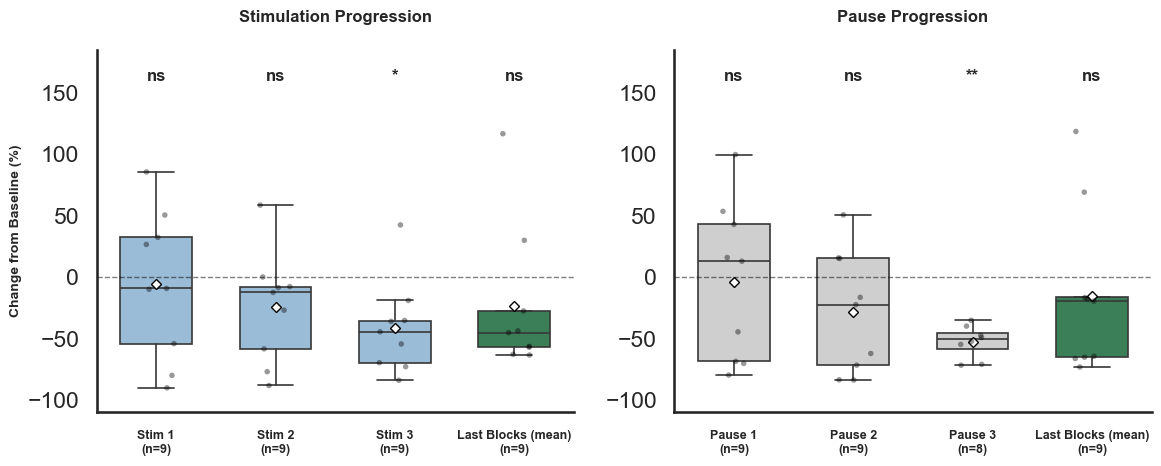

In [14]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = for_avg_props_raw['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#91bde1'
    pause_gray = '#cfcfcf'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

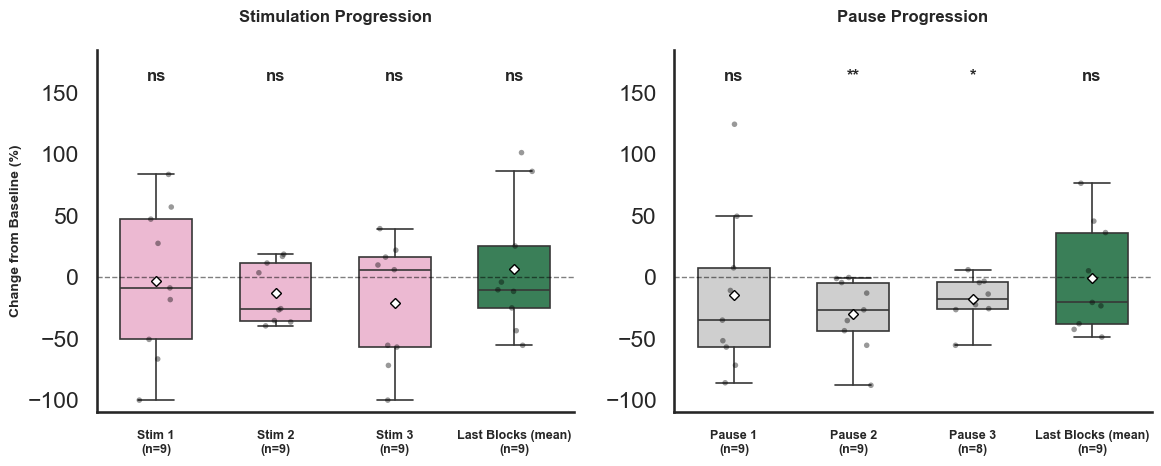

In [38]:
# 1. פונקציית עיבוד גנרית לנתונים מאוחדים (All)
def prepare_unified_data(block_type='stim'):
    exclude = ['515', '545']
    all_subjects_raw_pct = []
    # שימוש בנתוני 'all' כפי שביקשת
    raw_data = data_control['rates']['all']
    
    for name, subj_rates in zip(subject_ids, raw_data):
        if name in exclude: continue
        
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        if baseline == 0: continue
        
        # בחירת בלוקים: אי-זוגיים לגירוי, זוגיים להפסקה
        vals = subj_rates[1::2] if block_type == 'stim' else subj_rates[2::2]
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / baseline) * 100
        all_subjects_raw_pct.append(pd.Series(pct_changes))
    
    df_temp = pd.DataFrame(all_subjects_raw_pct)
    
    # שלב הסינון: IQR על כל בלוק בנפרד לפני המיצוע
    for col in df_temp.columns:
        Q1, Q3 = df_temp[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_temp.loc[(df_temp[col] < Q1 - 3*IQR) | (df_temp[col] > Q3 + 3*IQR), col] = np.nan
        
    # בניית השלבים הסופיים
    label_prefix = 'Stim' if block_type == 'stim' else 'Pause'
    final_dict = {
        f'{label_prefix} 1': df_temp[0],
        f'{label_prefix} 2': df_temp[1],
        f'{label_prefix} 3': df_temp[2],
        'Last Blocks (mean)': df_temp.iloc[:, 3:].mean(axis=1)
    }
    
    df_wide = pd.DataFrame(final_dict)
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    return df_wide, df_long

# 2. פונקציית הציור המשותפת
def plot_combined_unified_graphs():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.set_style("white")
    
    # צבעים
    stim_blue = '#f4b1d2'
    pause_gray = '#cfcfcf'
    last_blocks_color = '#2e8b57' # ירוק כפי שהיה בגרף המקורי שלך
    
    def draw_ax(ax, block_type):
        df_w, df_l = prepare_unified_data(block_type)
        
        # הגדרת פלטת צבעים: 3 בלוקים ראשונים בצבע המאפיין, והאחרון בירוק
        current_color = stim_blue if block_type == 'stim' else pause_gray
        pal = [current_color, current_color, current_color, last_blocks_color]
        
        # בוקספלוט
        sns.boxplot(data=df_l, x='Stage', y='Change_Percent', palette=pal,
                    width=0.6, fliersize=0, zorder=2, linewidth=1.2, ax=ax,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":5})
        
        # נקודות (Stripplot)
        sns.stripplot(data=df_l, x='Stage', y='Change_Percent', color='black', 
                      alpha=0.4, size=4, jitter=0.15, ax=ax, zorder=3)
        
        # סטטיסטיקה מול 0
        y_max = df_l['Change_Percent'].max()
        for i in range(df_w.shape[1]):
            data = df_w.iloc[:, i].dropna()
            if len(data) >= 5:
                _, p = wilcoxon(data)
                stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                # הצבת הכוכביות בגובה אחיד ומעט גבוה יותר
                ax.text(i, 160, stars, ha='center', fontweight='bold', fontsize=12)

        ax.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        
        # כותרות וצירים
        title = "Stimulation Progression" if block_type == 'stim' else "Pause Progression"
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=10, fontweight='bold')
        ax.set_xlabel("")
        
        # תוויות X עם n
        new_labels = [f"{col}\n(n={df_w[col].dropna().count()})" for col in df_w.columns]
        ax.set_xticklabels(new_labels, fontsize=9, fontweight='bold')
        
        # הגדרת ציר Y אחיד
        ax.set_ylim(-110, 185)
        ax.set_yticks(np.arange(-100, 151, 50))
        sns.despine(ax=ax)

    draw_ax(ax1, 'stim')
    draw_ax(ax2, 'pause')
    
    plt.tight_layout()
    plt.show()

# הרצה
plot_combined_unified_graphs()

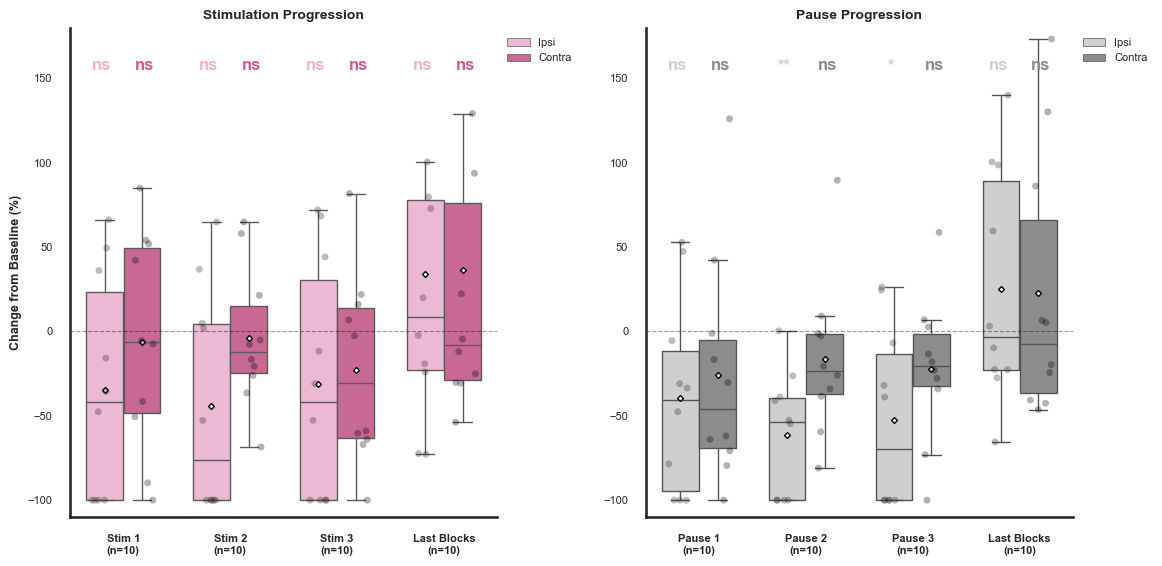

In [35]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = data_control['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#f4b1d2', 'Contra': '#d65a92'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

In [18]:
import joblib
joblib.dump(for_avg_props_raw, 'for_avg_props_raw_stim_frontal.pkl')

['for_avg_props_raw_stim_frontal.pkl']

In [42]:
for subj_idx, subj in enumerate(subject_ids):
    print(f"  {subj}: {data_stim['rates']['all'][subj_idx][0]:.2f} spikes/min")


  485: 12.61 spikes/min
  486: 6.17 spikes/min
  487: 8.14 spikes/min
  488: 18.94 spikes/min
  497: 5.14 spikes/min
  498: 1.48 spikes/min
  499: 24.58 spikes/min
  505: 15.43 spikes/min
  5107: 2.21 spikes/min
  515: 9.53 spikes/min
  520: 0.67 spikes/min
  545: 24.91 spikes/min


In [44]:
for subj_idx, subj in enumerate(controls):
    print(f"  {subj}: {data_control['rates']['all'][subj_idx][0]:.2f} spikes/min")


  394: 26.06 spikes/min
  396: 4.90 spikes/min
  398: 5.02 spikes/min
  402: 1.65 spikes/min
  404: 0.93 spikes/min
  406: 2.83 spikes/min
  415: 8.42 spikes/min
  416: 1.79 spikes/min
  417: 22.74 spikes/min
  423: 4.82 spikes/min


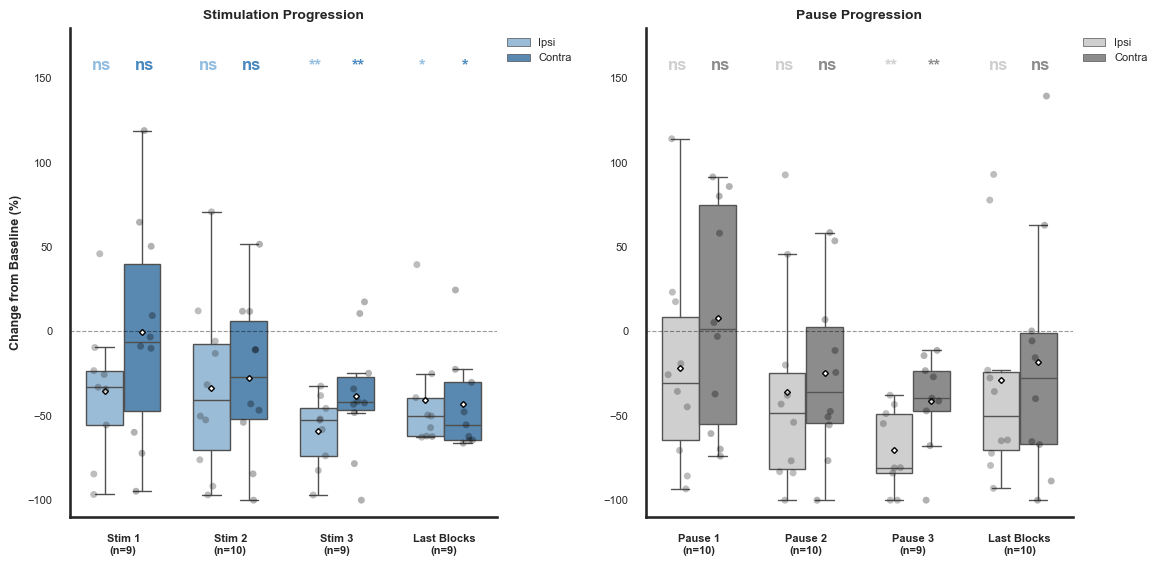

In [36]:
from scipy.stats import wilcoxon

def prepare_hemi_progression_data(hemi_type, block_type='stim'):
    all_subjects = []
    # שליפת הדאטה המתאים (ipsi או contra)
    raw_data = for_avg_props_raw['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            # בלוקים 1, 3, 5
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks (mean)']
        else:
            # בלוקים 2, 4, 6
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks (mean)']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Hemisphere'] = hemi_type.capitalize()
    return df_wide, df_long


def plot_combined_progression_final_v3():
    # יצירת פיגר רחב
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))
    sns.set_style("white")
    
    # גובה אחיד וגבוה יותר לסטטיסטיקה כדי למנוע דריסה
    y_stat_fixed = 155 
    
    def draw_on_ax(ax, block_type):
        hemi_types = ['ipsi', 'contra']
        df_list = []
        df_wide_dict = {}
        
        for h in hemi_types:
            df_w, df_l = prepare_hemi_progression_data(h, block_type)
            df_list.append(df_l)
            df_wide_dict[h.capitalize()] = df_w
            
        df_combined = pd.concat(df_list)
        
        if block_type == 'stim':
            pal = {'Ipsi': '#91bde1', 'Contra': '#4a89bf'}
            title = "Stimulation Progression"
        else:
            pal = {'Ipsi': '#cfcfcf', 'Contra': '#8c8c8c'}
            title = "Pause Progression"
            
        # בוקספלוט
        sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                    palette=pal, width=0.7, fliersize=0, zorder=2, linewidth=1,
                    showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                               "markeredgecolor":"black", "markersize":3}, ax=ax)
        
        sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Hemisphere',
                      dodge=True, color='black', alpha=0.3, size=2.5, jitter=0.2, ax=ax, zorder=3, s=5)
        
        # --- סטטיסטיקה בגובה אחיד למעלה ---
        offsets = [-0.2, 0.2]
        current_stages = df_combined['Stage'].unique()
        
        for i, stage in enumerate(current_stages):
            for h_idx, h_name in enumerate(['Ipsi', 'Contra']):
                data = df_wide_dict[h_name][stage].dropna()
                if len(data) >= 5:
                    _, p = wilcoxon(data)
                    stars = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                    ax.text(i + offsets[h_idx], y_stat_fixed, stars, ha='center', 
                            fontsize=12, fontweight='bold', color=pal[h_name])

        ax.axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
        
        # עיצוב צירים
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylabel("Change from Baseline (%)" if ax == ax1 else "", fontsize=9, fontweight='bold')
        
        # הסרת כותרת ציר X
        ax.set_xlabel("") 
        
        # תוויות X
        new_labels = []
        for stage in current_stages:
            n_val = df_wide_dict['Ipsi'][stage].dropna().count()
            label = stage.replace(" (mean)", "")
            new_labels.append(f"{label}\n(n={n_val})")
        ax.set_xticklabels(new_labels, fontsize=8, fontweight='bold')
        
        # הגדלת טווח ציר Y
        ax.set_ylim(-110, 180) 
        ax.set_yticks(np.arange(-100, 151, 50))
        ax.tick_params(labelsize=8)
        
        # מקרא מחוץ לגרף
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title=None, fontsize=8, 
                  frameon=False, loc='upper left', bbox_to_anchor=(1, 1))
        sns.despine(ax=ax)

    draw_on_ax(ax1, 'stim')
    draw_on_ax(ax2, 'pause')
    
    plt.tight_layout(rect=[0, 0, 0.92, 1])
    plt.show()

# הרצה
plot_combined_progression_final_v3()

In [47]:
import pandas as pd
import statsmodels.formula.api as smf

# 1. טעינת הנתונים
df = pd.read_csv('frontal_and_control_block_rates.csv')

# --- 2. שלב המיצוע (חדש) ---
# אנחנו מחשבים את ממוצע ה-rate עבור כל נבדק בכל סוג בלוק
# זה מבטיח שלכל נבדק יהיה משקל שווה במודל, ללא קשר למספר הבלוקים שביצע
df_subj = df.groupby(['subject_id', 'group_label', 'block_type'])['rate'].mean().reset_index()

# 3. הכנת הנתונים: הגדרת רמות ייחוס (Reference Levels)
# חשוב לבצע את זה על ה-DataFrame החדש (df_subj)
df_subj['group_label'] = pd.Categorical(df_subj['group_label'], categories=['control', 'stimulation'])
df_subj['block_type'] = pd.Categorical(df_subj['block_type'], categories=['pause_block', 'stimuli_block'])

# --- 4. בניית המודל ההיררכי על הממוצעים ---
# המודל כעת רץ על df_subj שבו יש פחות תצפיות (2 לכל נבדק)
model = smf.mixedlm("rate ~ group_label * block_type", df_subj, groups=df_subj["subject_id"])
result = model.fit()

# הדפסת סיכום המודל הסטטיסטי המעודכן
print(result.summary())

                              Mixed Linear Model Regression Results
Model:                          MixedLM               Dependent Variable:               rate     
No. Observations:               44                    Method:                           REML     
No. Groups:                     22                    Scale:                            2.8064   
Min. group size:                2                     Log-Likelihood:                   -122.6720
Max. group size:                2                     Converged:                        Yes      
Mean group size:                2.0                                                              
-------------------------------------------------------------------------------------------------
                                                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------------------
Intercept                                         

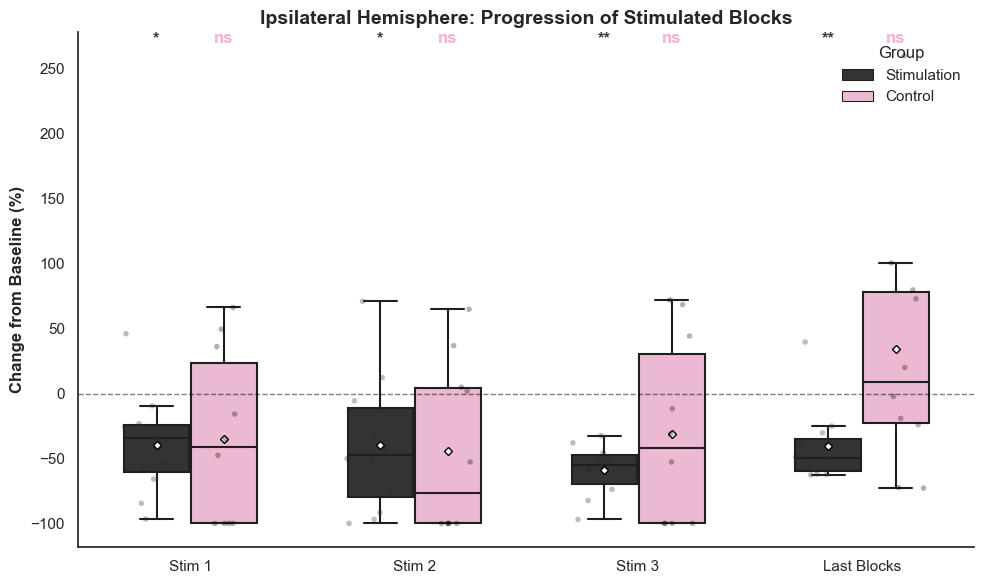

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon

def prepare_progression_single_hemi(data_source, group_name, hemi_type='ipsi'):
    all_subjects = []
    # שליפת הדאטה (מניח שקיים subject_ids גלובלי או מועבר)
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        # לוקחים רק את מקטעי הגירוי (1, 3, 5...)
        vals = subj_rates[1::2]
        stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        
        # בניה של השורה: 3 בלוקים ראשונים וממוצע השאר
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    
    # סינון IQR 3.0
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_name
    return df_wide, df_long

def plot_ipsi_progression_comparison():
    # 1. הכנת נתונים משתי הקבוצות (רק איפסי)
    df_wide_stim, df_long_stim = prepare_progression_single_hemi(data_stim, 'Stimulation', 'ipsi')
    df_wide_ctrl, df_long_ctrl = prepare_progression_single_hemi(data_control, 'Control', 'ipsi')
    
    df_combined = pd.concat([df_long_stim, df_long_ctrl])
    
    # 2. הגדרות עיצוב
    plt.figure(figsize=(10, 6))
    sns.set_style("white")
    
    # פלטה: שחור לגירוי, ורוד לקונטרול
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 3. ציור הבוקספלוט (שני בוקסים לכל שלב)
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2, linewidth=1.5,
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # הוספת נקודות גולמיות (Jitter)
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.3, size=4, jitter=0.2, zorder=3)

    # 4. סטטיסטיקה (מבחן Wilcoxon מול הבייסליין לכל קבוצה בנפרד)
    y_stat = df_combined['Change_Percent'].max() + 10
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15] # הזזה שמאלה לגירוי וימינה לקונטרול
    
    for i, stage in enumerate(stages):
        # סטטיסטיקה לגירוי
        d_stim = df_wide_stim[stage].dropna()
        if len(d_stim) >= 5:
            _, p = wilcoxon(d_stim)
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            plt.text(i + offsets[0], y_stat, star, ha='center', fontweight='bold', color=pal['Stimulation'])
            
        # סטטיסטיקה לקונטרול
        d_ctrl = df_wide_ctrl[stage].dropna()
        if len(d_ctrl) >= 5:
            _, p = wilcoxon(d_ctrl)
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            plt.text(i + offsets[1], y_stat, star, ha='center', fontweight='bold', color=pal['Control'])

    # 5. עיצוב סופי
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    plt.title("Ipsilateral Hemisphere: Progression of Stimulated Blocks", fontsize=14, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=12, fontweight='bold')
    plt.xlabel("")
    
    # הסרת כפילויות במקרא מה-stripplot
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Group", frameon=False, loc='upper right')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_ipsi_progression_comparison()

--- Statistics for STIM Progression ---
Stim 1 - Between Groups p: 0.8047
Stim 2 - Between Groups p: 0.4638
Stim 3 - Between Groups p: 0.7328
Last Blocks - Between Groups p: 0.0448


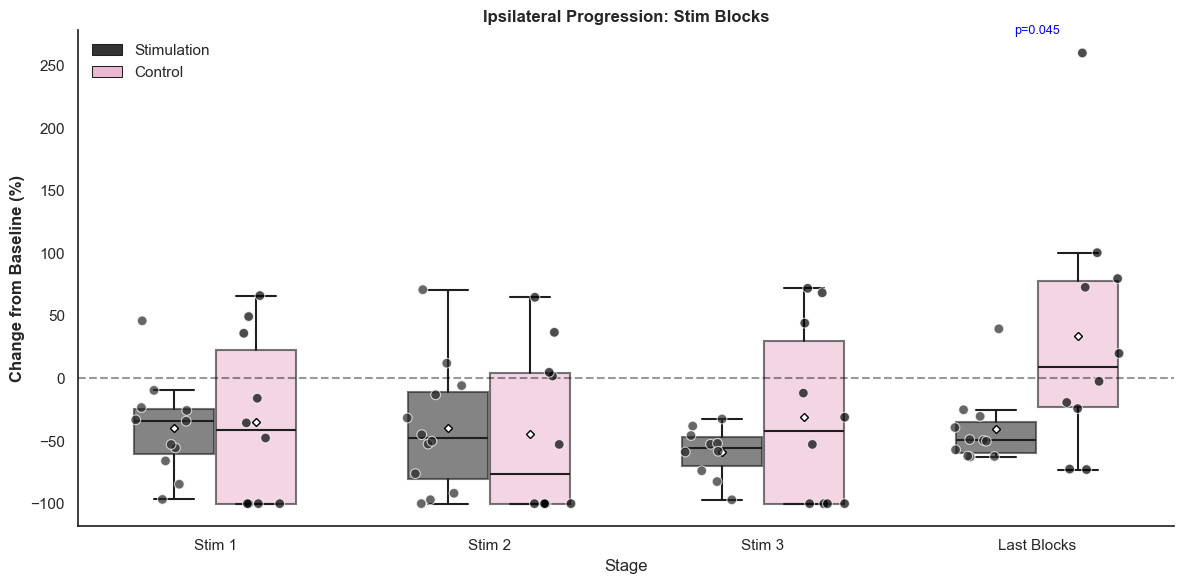

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

# פונקציה מתוקנת ששומרת על הלוגיקה המקורית שלך
def prepare_final_data(data_source, hemi_type='ipsi', block_type='stim', group_label='Group'):
    all_subjects = []
    raw_data = data_source['rates'][hemi_type]
    
    for name, subj_rates in zip(subject_ids, raw_data):
        subj_rates = np.array(subj_rates)
        if len(subj_rates) < 3: continue
        
        baseline = subj_rates[0]
        denom = baseline if baseline != 0 else 1e-9
        
        if block_type == 'stim':
            vals = subj_rates[1::2]
            stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
        else:
            vals = subj_rates[2::2]
            stages = ['Pause 1', 'Pause 2', 'Pause 3', 'Last Blocks']
            
        if len(vals) < 3: continue
        
        pct_changes = ((vals - baseline) / denom) * 100
        row = [pct_changes[0], pct_changes[1], pct_changes[2], 
               np.nanmean(pct_changes[3:]) if len(pct_changes) > 3 else np.nan]
        all_subjects.append(row)
    
    df_wide = pd.DataFrame(all_subjects, columns=stages)
    # סינון IQR 3.0 כפי שהיה לך
    for col in df_wide.columns:
        Q1, Q3 = df_wide[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        df_wide.loc[(df_wide[col] < Q1 - 3*IQR) | (df_wide[col] > Q3 + 3*IQR), col] = np.nan
        
    df_long = df_wide.melt(var_name='Stage', value_name='Change_Percent')
    df_long['Group'] = group_label
    return df_wide, df_long

def plot_final_comparison(block_to_plot='stim'):
    # טעינת הנתונים מחדש לשתי הקבוצות - רק איפסי
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(12, 6))
    sns.set_style("white")
    
    # צבעים: שחור לגירוי, ורוד לקונטרול
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # בוקספלוט עם שקיפות כדי שהנקודות ייראו
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), # שקיפות הבוקס
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # נקודות גדולות יותר עם מסגרת לבנה למניעת "היבלעות" בשחור
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=7, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # סטטיסטיקה
    stages = df_combined['Stage'].unique()
    y_max = df_combined['Change_Percent'].max()
    
    print(f"--- Statistics for {block_to_plot.upper()} Progression ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # מבחן בין קבוצות
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            if p_bet < 0.05:
                plt.text(i, y_max + 15, f"p={p_bet:.3f}", ha='center', color='blue', fontsize=9)

    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f"Ipsilateral Progression: {block_to_plot.capitalize()} Blocks", fontweight='bold')
    
    # ניקוי מקרא
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה על מקטעי הגירוי
plot_final_comparison('stim')

--------------------------------------------------
BETWEEN-GROUP COMPARISON (Stim vs Ctrl)
--------------------------------------------------
Stim 1: p-value (Stim vs Ctrl) = 0.8047
Stim 2: p-value (Stim vs Ctrl) = 0.4638
Stim 3: p-value (Stim vs Ctrl) = 0.7328
Last Blocks: p-value (Stim vs Ctrl) = 0.0448


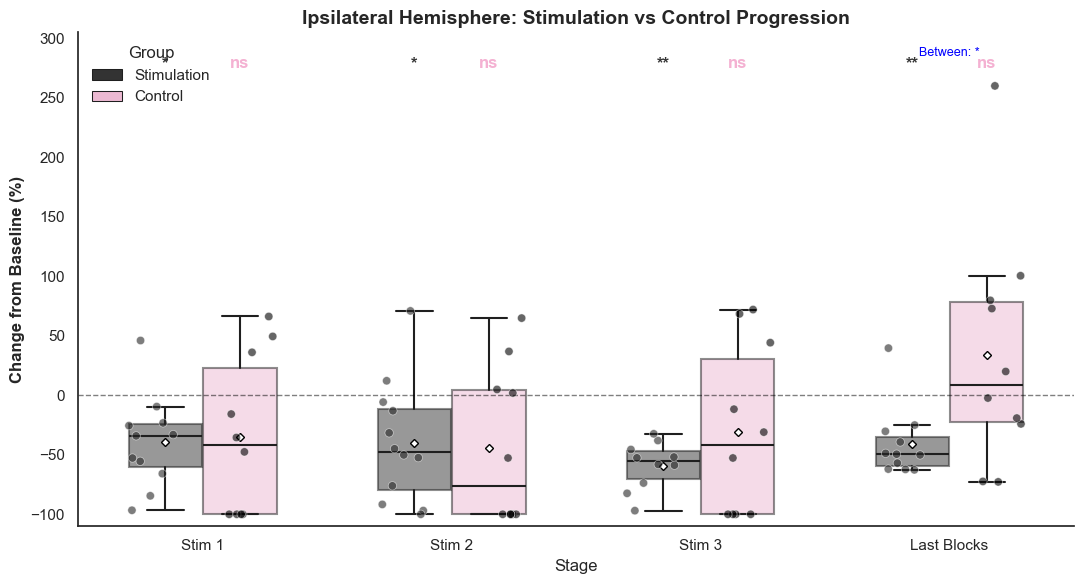

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def plot_ipsi_progression_comparison_v2():
    # 1. הכנת נתונים
    df_wide_stim, df_long_stim = prepare_progression_single_hemi(data_stim, 'Stimulation', 'ipsi')
    df_wide_ctrl, df_long_ctrl = prepare_progression_single_hemi(data_control, 'Control', 'ipsi')
    df_combined = pd.concat([df_long_stim, df_long_ctrl])
    
    plt.figure(figsize=(11, 6))
    sns.set_style("white")
    
    # פלטה: שחור שקוף וורוד פסטל
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט עם שקיפות (alpha) גבוהה יותר לבוקסים
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2, linewidth=1.5,
                     boxprops=dict(alpha=0.5), # הופך את הבוקס לשקוף כדי לראות את הנקודות
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. הוספת נקודות גדולות ובולטות יותר (Stripplot)
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.6, size=6, jitter=0.2, zorder=3,
                  linewidth=0.5, edgecolor='white') # מסגרת לבנה לנקודות

    # 4. סטטיסטיקה והדפסה
    y_stat_top = df_combined['Change_Percent'].max() + 15
    stages = ['Stim 1', 'Stim 2', 'Stim 3', 'Last Blocks']
    offsets = [-0.15, 0.15]
    
    print("-" * 50)
    print("BETWEEN-GROUP COMPARISON (Stim vs Ctrl)")
    print("-" * 50)

    for i, stage in enumerate(stages):
        d_stim = df_wide_stim[stage].dropna()
        d_ctrl = df_wide_ctrl[stage].dropna()
        
        # א. מבחן בין הקבוצות (Mann-Whitney)
        if len(d_stim) >= 3 and len(d_ctrl) >= 3:
            u_stat, p_between = mannwhitneyu(d_stim, d_ctrl)
            print(f"{stage}: p-value (Stim vs Ctrl) = {p_between:.4f}")
            
            # הוספת סימון בין הקבוצות בגרף (אם תרצי קו מחבר)
            if p_between < 0.05:
                star_b = '*' if p_between < 0.05 else '**'
                plt.text(i, y_stat_top + 10, f"Between: {star_b}", ha='center', fontsize=9, color='blue')

        # ב. מבחן בתוך כל קבוצה (Wilcoxon מול 0)
        for idx, (data, grp_name) in enumerate([(d_stim, 'Stimulation'), (d_ctrl, 'Control')]):
            if len(data) >= 5:
                _, p_within = wilcoxon(data)
                star_w = '***' if p_within < 0.001 else '**' if p_within < 0.01 else '*' if p_within < 0.05 else 'ns'
                plt.text(i + offsets[idx], y_stat_top, star_w, ha='center', fontweight='bold', color=pal[grp_name])

    # 5. עיצוב סופי
    plt.axhline(0, color='black', linestyle='--', alpha=0.5, linewidth=1)
    plt.title("Ipsilateral Hemisphere: Stimulation vs Control Progression", fontsize=14, fontweight='bold')
    plt.ylabel("Change from Baseline (%)", fontsize=12, fontweight='bold')
    plt.ylim(df_combined['Change_Percent'].min() - 10, y_stat_top + 30)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], title="Group", frameon=False)
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_ipsi_progression_comparison_v2()

--- Statistics for STIM ---
Stim 1 - Between Groups p: 0.8047
Stim 2 - Between Groups p: 0.4638
Stim 3 - Between Groups p: 0.7328
Last Blocks - Between Groups p: 0.0448


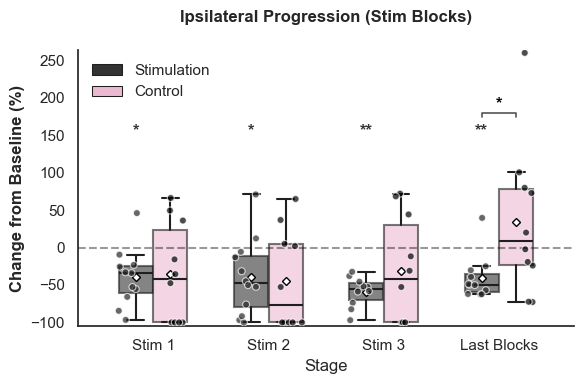

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import wilcoxon, mannwhitneyu

def plot_final_comparison_with_brackets(block_to_plot='stim'):
    # 1. הכנת הנתונים (מבוסס על prepare_final_data מהשלב הקודם)
    df_w_stim, df_l_stim = prepare_final_data(data_stim, 'ipsi', block_to_plot, 'Stimulation')
    df_w_ctrl, df_l_ctrl = prepare_final_data(data_control, 'ipsi', block_to_plot, 'Control')
    df_combined = pd.concat([df_l_stim, df_l_ctrl])
    
    plt.figure(figsize=(6, 4))
    sns.set_style("white")
    
    pal = {'Stimulation': '#333333', 'Control': '#f4b1d2'}
    
    # 2. ציור הבוקספלוט
    ax = sns.boxplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                     palette=pal, width=0.6, fliersize=0, zorder=2,
                     boxprops=dict(alpha=0.6), 
                     showmeans=True, meanprops={"marker":"D", "markerfacecolor":"white", 
                                                "markeredgecolor":"black", "markersize":4})
    
    # 3. נקודות דגימה בולטות
    sns.stripplot(data=df_combined, x='Stage', y='Change_Percent', hue='Group',
                  dodge=True, color='black', alpha=0.7, size=5, jitter=0.2, zorder=3,
                  linewidth=0.8, edgecolor='white')

    # 4. הגדרות גובה לסטטיסטיקה
    y_within = 150 # גובה כוכביות מול בייסליין
    y_between_start = 175 # גובה התחלה לסוגר בין קבוצות
    stages = df_combined['Stage'].unique()
    offsets = [-0.15, 0.15]
    
    print(f"--- Statistics for {block_to_plot.upper()} ---")
    for i, stage in enumerate(stages):
        d_s = df_w_stim[stage].dropna()
        d_c = df_w_ctrl[stage].dropna()
        
        # א. סטטיסטיקה בתוך קבוצה (מול 0) - בגובה 150
        for idx, (data, grp_name) in enumerate([(d_s, 'Stimulation'), (d_c, 'Control')]):
            if len(data) >= 5:
                _, p_w = wilcoxon(data)
                if p_w < 0.05:
                    star_w = '***' if p_w < 0.001 else '**' if p_w < 0.01 else '*'
                    plt.text(i + offsets[idx], y_within, star_w, ha='center', 
                             fontweight='bold', color=pal[grp_name], fontsize=12)

        # ב. סטטיסטיקה בין קבוצות + קו מחבר
        if len(d_s) > 0 and len(d_c) > 0:
            _, p_bet = mannwhitneyu(d_s, d_c)
            print(f"{stage} - Between Groups p: {p_bet:.4f}")
            
            if p_bet < 0.05:
                star_b = '***' if p_bet < 0.001 else '**' if p_bet < 0.01 else '*'
                # ציור הסוגר (Bracket)
                x1, x2 = i + offsets[0], i + offsets[1]
                h = 5 # גובה ה"כתפיים" של הסוגר
                plt.plot([x1, x1, x2, x2], [y_between_start, y_between_start+h, y_between_start+h, y_between_start], 
                         lw=1.2, color='#555555')
                plt.text((x1+x2)/2, y_between_start + h + 2, star_b, ha='center', 
                         va='bottom', color='black', fontweight='bold', fontsize=12)

    # 5. עיצוב צירים ומקרא
    plt.axhline(0, color='black', linestyle='--', alpha=0.4)
    plt.ylim(-105, 264) # הגדלת הטווח כדי שיהיה מקום לסוגרים
    plt.ylabel("Change from Baseline (%)", fontweight='bold')
    plt.title(f"Ipsilateral Progression ({block_to_plot.capitalize()} Blocks)", fontweight='bold', pad=20)
    
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles[:2], labels[:2], frameon=False, loc='upper left')
    
    sns.despine()
    plt.tight_layout()
    plt.show()

# הרצה
plot_final_comparison_with_brackets('stim')